In [8]:
# np.random.seed(666)
import pandas as pd
import sys
sys.path.append("../src/")
from alive_progress import alive_bar
from project_package.generate_pop import SymPop
from project_package.generate_pop import generate_initial_pop_unlinked
from project_package.run_model import update_pop, update_pop_with_tracers,update_pop2_with_tracers
import tracemalloc
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# msprime toy example

## option 1: mutations on a genome length

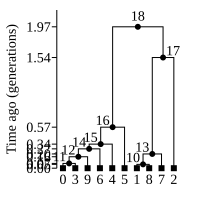

In [110]:
import msprime
import numpy as np

#Parameters
n = 5 # number of terminals (haploid samples)
Ne = 100 # effective population size
L = 100 # sequence length (sites); tune to control #variants

seed = 666

#1) Simulate ancestry: single tree (no recombination) #maybe pop param not necessary at first
# dem = msprime.Demography()
# dem.add_population("pop", initial_size=Ne)
ts = msprime.sim_ancestry(
samples=n,
# demography=dem,
sequence_length=L,
recombination_rate=0.0,
model="hudson", #['hudson', 'smc', 'smc_prime', 'dtwf', 'fixed_pedigree'
random_seed=seed
)

first_tree = ts.first()
first_tree.draw_svg(y_axis=True) 

╔═══════════════════════════════╗
║Variant                        ║
╠═══════════════════════╤═══════╣
║Site id                │      0║
╟───────────────────────┼───────╢
║Site position          │      1║
╟───────────────────────┼───────╢
║Number of samples      │     10║
╟───────────────────────┼───────╢
║Number of alleles      │      2║
╟───────────────────────┼───────╢
║Samples with allele '0'│9 (90%)║
╟───────────────────────┼───────╢
║Samples with allele '1'│1 (10%)║
╟───────────────────────┼───────╢
║Has missing data       │  False║
╟───────────────────────┼───────╢
║Isolated as missing    │   True║
╚═══════════════════════╧═══════╝

╔═══════════════════════════════╗
║Variant                        ║
╠═══════════════════════╤═══════╣
║Site id                │      1║
╟───────────────────────┼───────╢
║Site position          │     20║
╟───────────────────────┼───────╢
║Number of samples      │     10║
╟───────────────────────┼───────╢
║Number of alleles      │      2║
╟────────────

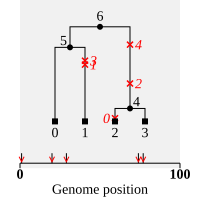

In [114]:
# 2) Add mutations
mu=L*1e-4
mts = msprime.sim_mutations(
ts,
rate=mu,
model=msprime.InfiniteSites(), # use JC69/HKY/GTR if you need homoplasy
random_seed=seed
)

# 3) Build a per-sample hash of genotypes, streaming over variants
rng = np.random.default_rng(seed)
num_sites = mts.num_sites

# One random 64-bit key per site; collisions are astronomically unlikely
site_keys = rng.integers(0, np.uint64(2**64 - 1), size=num_sites, dtype=np.uint64)

# Hash for each sample (8 MB for 1e6 samples)
sample_hash = np.zeros(mts.num_samples, dtype=np.uint64)

print('\n'.join(map(str,[var for var in mts.variants()])))
print([(var.index,var.genotypes) for var in mts.variants()])
for var in mts.variants(): # iterates segregating sites only
    k = var.index # site index (0..num_sites-1)
    g = var.genotypes # int8 array of length n
    # InfiniteSites yields binary genotypes: 0=ancestral, 1=derived
    derived_mask = (g == 1)
    # XOR the site key into hashes of samples carrying the derived allele
    sample_hash[derived_mask] ^= site_keys[k]

# 4) Choose one representative sample per unique genotype hash
# np.unique returns first occurrence indices with return_index=True
unique_hashes, first_idx = np.unique(sample_hash, return_index=True)
print(f"Distinct genotypes: {len(unique_hashes)}")
print(first_idx)

# Map indices back to sample node IDs
sample_nodes = mts.samples() # array of node IDs in sample order
keep_nodes = sample_nodes[first_idx] # one node per unique genotype

# 5) Prune the tree to those samples
mts_unique = mts.simplify(keep_nodes, keep_unary=False)
print(f"Pruned samples: {mts_unique.num_samples}, sites: {mts_unique.num_sites}, mutations: {mts_unique.num_mutations}")

mts_unique.draw_svg()
# mts.draw_svg()

## option 2: SLiM mutations; no genome length

keep_nodes [6 0 2 1]
first_idx [6 0 2 1]
alleles dict_keys(['', '1,2', '0,3', '0,3,4'])
abundances dict_values([np.int64(3), np.int64(1), np.int64(5), np.int64(1)])
distances [0, 2, 2, 3]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
<generator object <genexpr> at 0x11b9ecd40>
{0: {'abundance': 100, 'fitness': 100}, 1: {'abundance': 100, 'fitness': 100}, 2: {'abundance': 100, 'fitness': 100}, 3: {'abundance': 100, 'fitness': 100}, 4: {'abundance': 0, 'fitness': nan}, 5: {'abundance': 0, 'fitness': nan}, 6: {'abundance': 0, 'fitness': nan}, 7: {'abundance': 0, 'fitness': nan}, 8: {'abundance': 0, 'fitness': nan}, 9: {'abundance': 0, 'fitness': nan}, 10: {'abundance': 0, 'fitness': nan}, 11: {'abundance': 0, 'fitness': nan}, 12: {'abundance': 0, 'fitness': nan}, 13: {'abundance': 0, 'fitness': nan}, 14: {'abundance': 0, 'fitness': nan}, 15: {'abundance': 0, 'fitness': nan}, 16: {'abundance': 0, 'fitness': nan}, 17: {'abundance': 0, 'fitness': nan}, 18: {'abundance': 

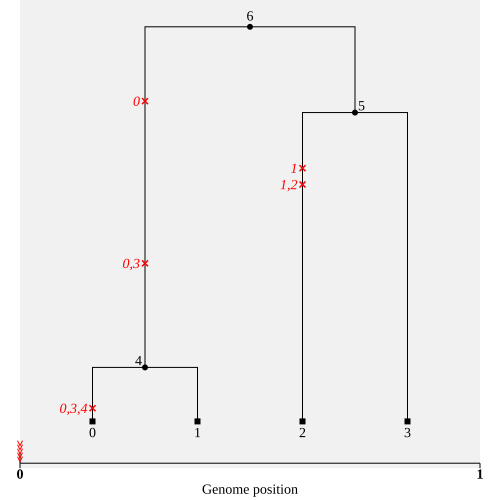

In [383]:

n = 5 # number of terminals (haploid samples)
seed = 666
mu = 1 # mutation rate per site per generation

# 1) Create tree

ts = msprime.sim_ancestry(n, random_seed=seed, sequence_length=1)

# 2) Overlay mutations. SLiM mutations to keep track of them accumulating
mts = msprime.sim_mutations(
    ts, 
    rate=mu, 
    model=msprime.SLiMMutationModel(type=1),
    random_seed=seed)


# 3) Get population summary

final_intrahost_strains=+[var.counts() for var in mts.variants()][0]
alleles=final_intrahost_strains.keys()
abundances=final_intrahost_strains.values()
# distances=[sum(tok.isdigit() for tok in s.split(',')) for s in final_intrahost_strains.keys()]

# 4) prune tree to distinct genotypes

sample_hash = np.zeros(mts.num_samples, dtype=np.uint64)
rng = np.random.default_rng(666)
for var in mts.variants():
    # One random key per allele at this site (ancestral allele index 0 included)
    keys = rng.integers(0, np.uint64(2**64 - 1),
                        size=len(var.alleles), dtype=np.uint64)
    g = var.genotypes  # length = num_samples; values are allele indices (0..k-1)
    # XOR the key for each allele into hashes of samples carrying that allele
    for a in range(len(var.alleles)):
        mask = (g == a)
        if np.any(mask):
            sample_hash[mask] ^= keys[a]
_, first_idx = np.unique(sample_hash, return_index=True)
keep_nodes = mts.samples()[first_idx]
mts_unique = mts.simplify(keep_nodes, keep_unary=False)
print('keep_nodes',keep_nodes)
print('first_idx',first_idx)
print('alleles',alleles)
print('abundances',abundances)
print('distances',distances)

print([n.id for n in ts.nodes()])
print(var for var in mts.variants())

mydic={}
for n in ts.nodes():
    if n.id >=len(alleles):
        mydic[n.id]={'abundance':0,'fitness':np.nan} 
    else:
        mydic[n.id]={'abundance':100,'fitness':100}
print(mydic)


## 4.1 turn reduced tree to networkx
def to_networkx_graph(ts):
    edges=ts.tables.edges
    G = nx.from_pandas_edgelist(
        pd.DataFrame({'source': edges.parent, 'target': edges.child, 'left': edges.left, 'right': edges.right}),
        edge_attr=True,
        create_using=nx.MultiDiGraph
    )
    nx.set_node_attributes(G, {n.id: {'abundance':n.flags, 'fitness': n.time} for n in ts.nodes()})
    return G

# G = to_networkx_graph(mts_unique)


ml = {m.id: m.derived_state for m in mts_unique.mutations()}

print(f"Samples: {mts.num_samples}, sites: {mts.num_sites}, mutations: {mts.num_mutations}")
print('genotypes',final_intrahost_strains.keys(),'counts',final_intrahost_strains.values())
# mts_unique.draw_svg(size=(500, 500),mutation_labels=ml)
# plt.figure()
# visualize_pop(G)
mts_unique.draw_svg(size=(500, 500),mutation_labels=ml)


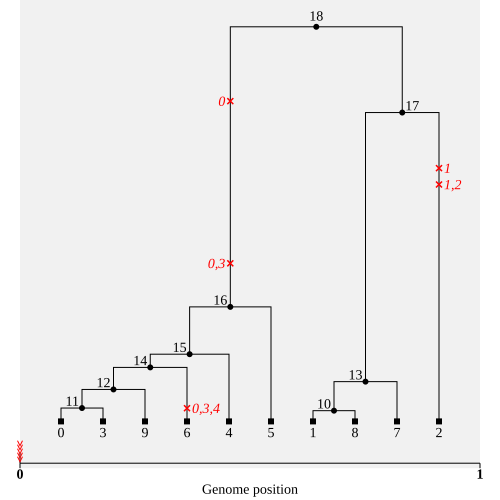

In [336]:
ml = {m.id: m.derived_state for m in mts.mutations()}
mts.draw_svg(size=(500, 500),mutation_labels=ml)


## add column abundance and fitness in metadata


In [352]:
# add column abundance and fitness in metadata
mts_unique.tables.nodes.metadata = {"mean_coverage": 200.5}
mts_unique.tables.nodes

ImmutableTableError: Cannot set attribute 'metadata' on immutable nodes table. Use TreeSequence.dump_tables() for mutable copy.

In [381]:
def annotate_mutations_with_selectioncoef(mts, mean=-0.01, std=0.01, baseline=1.0, seed=None):
    """
    Returns a new TreeSequence with:
    1) mutations carry metadata:
    {"s": selection_coefficient} where s ~ Normal(mean, std).
    2) nodes carry metadata:
    {"fitness": fitness of strain} where fitness is the cumulative effects of mutations selection coefficient, of baseline (parent strain) if no mutations
    {"abundance": abundance of strain} 
    """

    ### Add selection coefficient to mutations ###
    
    tables = mts.dump_tables()
    
    muts = tables.mutations
    n = muts.num_rows
    rng = np.random.default_rng(seed)
    
    # Draw selection coefficients per mutation row
    s_vals = rng.normal(loc=mean, scale=std, size=n)
    
    parent = np.array(muts.parent, dtype=np.int64)

    # Rebuild the mutations table row-by-row with metadata
    original_mut_rows = list(mts.mutations())  # preserves row order
    muts.clear()
    has_time = hasattr(original_mut_rows[0], "time")
    
    for i, mut in enumerate(original_mut_rows):
        md = json.dumps({"s": float(s_vals[i])}).encode("utf-8")
        if has_time:
            muts.add_row(
                site=mut.site,
                node=mut.node,
                derived_state=mut.derived_state,
                parent=mut.parent,
                time=mut.time,
                metadata=md
            )
        else:
            muts.add_row(
                site=mut.site,
                node=mut.node,
                derived_state=mut.derived_state,
                parent=mut.parent,
                metadata=md
            )
    
    ts=tables.tree_sequence()
    
    ### Add fitness to nodes ###
    
    # def _get_s(md_bytes):
    #     if not md_bytes:
    #         return(0.0)
    #     try:
    #         md = json.loads(md_bytes.decode("utf-8"))
    #         return(float(md.get("s", 0.0)))
    #     except Exception:
    #         return(0.0)


    if ts.num_sites != 1:
        raise ValueError(f"Expected SLiM mutations model (genome length=1), got genome of length {ts.num_sites}")


    def get_s(m):
        if not m.metadata:
            return( 0.0)
        try:
            md = json.loads(m.metadata.decode("utf-8"))
            return( float(md.get("s", 0.0)))
        except Exception:
            return( 0.0)
    
    node_s_accum = np.zeros(ts.num_nodes, dtype=float)
    
    # Iterate over sites, paint each tip’s stacked s_total onto its subtree
    for site in ts.sites():
        site_muts = list(site.mutations)
        if not site_muts:
            continue
    
        tree = ts.at(site.position)
        by_id = {m.id: m for m in site_muts}
        has_child = set(m.parent for m in site_muts if m.parent != tskit.NULL)
        tips = [m for m in site_muts if m.id not in has_child]
    
        for tip in tips:
            # Sum s along the parent chain (stacked mutations at the site)
            s_total = 0.0
            cur = tip
            while True:
                s_total += get_s(cur)
                if cur.parent == tskit.NULL:
                    break
                cur = by_id.get(cur.parent)
                if cur is None:
                    break
    
            # Paint this site’s contribution to all nodes in the tip’s subtree
            for u in tree.preorder(tip.node):
                node_s_accum[u] += s_total
    
    node_fitness = baseline + node_s_accum
    
    # var = next(ts.variants())
    # site = var.site
    # tree = ts.at(site.position)
    # samples = ts.samples()
    # sample_index = {u: i for i, u in enumerate(samples)}
    
    # # Identify tip-of-chain mutations (final state on each branch)
    # site_muts = list(site.mutations)
    # has_child = set(m.parent for m in site_muts if m.parent != tskit.NULL)
    # by_id = {m.id: m for m in site_muts}
    # tips = [m for m in site_muts if m.id not in has_child]
    
    # # Compute per-tip value: either sum(s) along the chain, or tip 'fitness'
    # tip_value_by_node = {}
    # for tip in tips:
    #     # if use_tip_fitness:
    #     #     # Use precomputed fitness at the tip, fall back to baseline if missing
    #     #     try:
    #     #         md = json.loads(tip.metadata.decode("utf-8")) if tip.metadata else {}
    #     #         tip_value_by_node[tip.node] = float(md.get("fitness", baseline))
    #     #     except Exception:
    #     #         tip_value_by_node[tip.node] = baseline
    #     # else:
    #         # Sum s along the parent chain
    #         s_total = 0.0
    #         cur = tip
    #         while True:
    #             s_total += _get_s(cur.metadata)
    #             if cur.parent == tskit.NULL:
    #                 break
    #             cur = by_id.get(cur.parent)
    #             if cur is None:
    #                 break
    #         tip_value_by_node[tip.node] = baseline + s_total
    
    # # Assign fitness to samples; those with no mutation at this site stay at baseline
    # fit_per_sample = np.full(len(samples), baseline, dtype=float)
    # for root in tree.roots:
    #     for u in tree.preorder(root):
    #         if u in tip_value_by_node:
    #             val = tip_value_by_node[u]
    #             for s in tree.samples(u):
    #                 fit_per_sample[sample_index[s]] = val
    return(node_fitness)

    
annotate_mutations_with_selectioncoef(mts_unique, mean=-0.01, std=0.01, baseline=1.0, seed=666)

array([0.9693204 , 1.        , 0.98217055, 1.        , 1.        ,
       1.        , 1.        ])

In [ ]:

    


#######################################################
def annotate_pruned_nodes(mts, dic_meta, schema=None):
    """
    fitness_by_sample_node: dict mapping node_id -> float fitness (only for sample nodes).
    schema: optional JSON schema dict for structured metadata.
    Returns a new TreeSequence whose nodes carry metadata {"fitness": ...} for samples.
    """
tables = mts_unique.dump_tables()
# Optional: set a JSON metadata schema on nodes
if schema is None:
    schema = {
        "codec": "json",
        "type": "object",
        "properties": {
            "fitness": {"type": "number"}
        }
    }
    tables.nodes.metadata_schema = tskit.MetadataSchema.from_dict(schema)

def encode(md):
    return tables.nodes.metadata_schema.encode_row(md)


#### add selection coefficient to mutations
muts = tables.mutations
n = muts.num_rows
rng = np.random.default_rng(seed)

# Draw selection coefficients per mutation row
s_vals = rng.normal(loc=mean, scale=std, size=n)


# Rebuild nodes table row-by-row with metadata
original_nodes = list(mts_unique.nodes())  # preserves row order and IDs
tables.nodes.clear()
for n in original_nodes:
    # Add metadata only for sample nodes we have fitness for
    if n.id in dic_meta                                                                                                                                                     :
        md = encode({"fitness": float(dic_meta[n.id])})
    else:
        md = encode({})  # empty object; could also use b"" if no schema
    tables.nodes.add_row(
        flags=n.flags,
        time=n.time,
        population=n.population,
        individual=n.individual,
        metadata=md
    )
    
    # return(tables.tree_sequence())

In [344]:
# add column distance with mutation counts
mts_unique.tables.edges

id,left,right,parent,child,metadata
0,0,1,4,0,
1,0,1,4,1,
2,0,1,5,2,
3,0,1,5,3,
4,0,1,6,4,
5,0,1,6,5,


In [373]:
import numpy as np
import tskit
import json

def annotate_mutations_with_fitness(mts, mean=-0.01, std=0.01, baseline=1.0, seed=None):
    """
    Returns a new TreeSequence whose mutations carry metadata:
    {"fitness": cumulative_fitness, "s": selection_coefficient}
    Fitness is computed as:
    fitness[mutation] = (fitness of parent allele, or baseline) + s
    where s ~ Normal(mean, std).
    """
    tables = mts.dump_tables()
    
    # Optional: attach a JSON metadata schema (for viewers/tools that use it)
    try:
        schema = tskit.MetadataSchema.from_dict({
            "codec": "json",
            "type": "object",
            "properties": {
                "fitness": {"type": "number"},
                "s": {"type": "number"}
            },
            "required": ["fitness", "s"]
        })
        tables.mutations.metadata_schema = schema
    except Exception:
        schema = None  # continue without schema if tskit version differs
    
    muts = tables.mutations
    n = muts.num_rows
    rng = np.random.default_rng(seed)
    
        # Draw selection coefficients per mutation row
    s_vals = rng.normal(loc=mean, scale=std, size=n)
    
    parent = np.array(muts.parent, dtype=np.int64)
    fitness = np.full(n, np.nan, dtype=float)
    
    # Compute fitness along parent chains
    def compute_fit(i):
        if not np.isnan(fitness[i]):
            return fitness[i]
        p = parent[i]
        base = baseline if p == tskit.NULL else compute_fit(p)
        fitness[i] = base + s_vals[i]
        return fitness[i]
    
    for i in range(n):
        compute_fit(i)
    
    # Optional: attach a JSON metadata schema (ignored if not supported)
    try:
        tables.mutations.metadata_schema = tskit.MetadataSchema.from_dict({
            "codec": "json",
            "type": "object",
            "properties": {
                "fitness": {"type": "number"},
                "s": {"type": "number"}
            },
            "required": ["fitness", "s"]
        })
    except Exception:
        pass
    
    # Rebuild the mutations table row-by-row with metadata
    original_mut_rows = list(mts.mutations())  # preserves row order
    muts.clear()
    has_time = hasattr(original_mut_rows[0], "time")
    
    for i, mut in enumerate(original_mut_rows):
        md = json.dumps({"fitness": float(fitness[i]), "s": float(s_vals[i])}).encode("utf-8")
        if has_time:
            muts.add_row(
                site=mut.site,
                node=mut.node,
                derived_state=mut.derived_state,
                parent=mut.parent,
                time=mut.time,
                metadata=md
            )
        else:
            muts.add_row(
                site=mut.site,
                node=mut.node,
                derived_state=mut.derived_state,
                parent=mut.parent,
                metadata=md
            )
    
    return( tables.tree_sequence())

mts_with_fitness = annotate_mutations_with_fitness(
mts, mean=-0.01, std=0.01, baseline=1.0, seed=42
)
mts_with_fitness.tables.nodes

id,time,flags,population,individual,metadata
0,0.00000000,1,0,0,
1,0.00000000,1,0,0,
2,0.00000000,1,0,1,
3,0.00000000,1,0,1,
4,0.00000000,1,0,2,
5,0.00000000,1,0,2,
6,0.00000000,1,0,3,
7,0.00000000,1,0,3,
8,0.00000000,1,0,4,
9,0.00000000,1,0,4,


In [365]:

def annotate_mutations_with_fitness(mts, mean=-0.01, std=0.01, baseline=1.0, seed=None):
    """
    Returns a new TreeSequence whose mutations carry metadata:
    {"s": selection_coefficient}
    where s ~ Normal(mean, std).
    """
    tables = mts.dump_tables()
    
    muts = tables.mutations
    n = muts.num_rows
    rng = np.random.default_rng(seed)
    
    # Draw selection coefficients per mutation row
    s_vals = rng.normal(loc=mean, scale=std, size=n)
    
    parent = np.array(muts.parent, dtype=np.int64)

    # Rebuild the mutations table row-by-row with metadata
    original_mut_rows = list(mts.mutations())  # preserves row order
    muts.clear()
    has_time = hasattr(original_mut_rows[0], "time")
    
    for i, mut in enumerate(original_mut_rows):
        md = json.dumps({"s": float(s_vals[i])}).encode("utf-8")
        if has_time:
            muts.add_row(
                site=mut.site,
                node=mut.node,
                derived_state=mut.derived_state,
                parent=mut.parent,
                time=mut.time,
                metadata=md
            )
        else:
            muts.add_row(
                site=mut.site,
                node=mut.node,
                derived_state=mut.derived_state,
                parent=mut.parent,
                metadata=md
            )
    
    return(tables.tree_sequence())

mts_with_fitness = annotate_mutations_with_fitness(
mts, mean=-0.01, std=0.01, baseline=1.0, seed=42
)


def fitnesses_by_genotype_single_site(ts, baseline=1.0, unique=True, use_tip_fitness=False):
    """
    Returns a dict: allele -> list of fitnesses for samples with that allele at the single site.
    If unique=True, fitness lists are deduplicated and sorted.
    If use_tip_fitness=True, reads the tip mutation's 'fitness' metadata instead of summing 's'.
    """

    def _get_s(md_bytes):
        if not md_bytes:
            return(0.0)
        try:
            md = json.loads(md_bytes.decode("utf-8"))
            return(float(md.get("s", 0.0)))
        except Exception:
            return(0.0)
    


    if ts.num_sites != 1:
        raise ValueError(f"Expected exactly one site, got {ts.num_sites}")

        def get_s(m):
        if not m.metadata:
            return 0.0
        try:
            md = json.loads(m.metadata.decode("utf-8"))
            return float(md.get("s", 0.0))
        except Exception:
            return 0.0
    
    node_s_accum = np.zeros(ts.num_nodes, dtype=float)
    
    # Iterate over sites, paint each tip’s stacked s_total onto its subtree
    for site in ts.sites():
        site_muts = list(site.mutations)
        if not site_muts:
            continue
    
        tree = ts.at(site.position)
        by_id = {m.id: m for m in site_muts}
        has_child = set(m.parent for m in site_muts if m.parent != tskit.NULL)
        tips = [m for m in site_muts if m.id not in has_child]
    
        for tip in tips:
            # Sum s along the parent chain (stacked mutations at the site)
            s_total = 0.0
            cur = tip
            while True:
                s_total += get_s(cur)
                if cur.parent == tskit.NULL:
                    break
                cur = by_id.get(cur.parent)
                if cur is None:
                    break
    
            # Paint this site’s contribution to all nodes in the tip’s subtree
            for u in tree.preorder(tip.node):
                node_s_accum[u] += s_total
    
    node_fitness = baseline + node_s_accum
    # var = next(ts.variants())
    # site = var.site
    # tree = ts.at(site.position)
    # samples = ts.samples()
    # sample_index = {u: i for i, u in enumerate(samples)}
    
    # # Identify tip-of-chain mutations (final state on each branch)
    # site_muts = list(site.mutations)
    # has_child = set(m.parent for m in site_muts if m.parent != tskit.NULL)
    # by_id = {m.id: m for m in site_muts}
    # tips = [m for m in site_muts if m.id not in has_child]
    
    # # Compute per-tip value: either sum(s) along the chain, or tip 'fitness'
    # tip_value_by_node = {}
    # for tip in tips:
    #     # if use_tip_fitness:
    #     #     # Use precomputed fitness at the tip, fall back to baseline if missing
    #     #     try:
    #     #         md = json.loads(tip.metadata.decode("utf-8")) if tip.metadata else {}
    #     #         tip_value_by_node[tip.node] = float(md.get("fitness", baseline))
    #     #     except Exception:
    #     #         tip_value_by_node[tip.node] = baseline
    #     # else:
    #         # Sum s along the parent chain
    #         s_total = 0.0
    #         cur = tip
    #         while True:
    #             s_total += _get_s(cur.metadata)
    #             if cur.parent == tskit.NULL:
    #                 break
    #             cur = by_id.get(cur.parent)
    #             if cur is None:
    #                 break
    #         tip_value_by_node[tip.node] = baseline + s_total
    
    # # Assign fitness to samples; those with no mutation at this site stay at baseline
    # fit_per_sample = np.full(len(samples), baseline, dtype=float)
    # for root in tree.roots:
    #     for u in tree.preorder(root):
    #         if u in tip_value_by_node:
    #             val = tip_value_by_node[u]
    #             for s in tree.samples(u):
    #                 fit_per_sample[sample_index[s]] = val
    # # print(fit_per_sample)
    # # Group fitnesses by allele (genotype) at the site
    # result = {}
    # for a_idx, allele in enumerate(var.alleles):
    #     mask = (var.genotypes == a_idx)
    #     if not np.any(mask):
    #         continue
    #     vals = fit_per_sample[mask]
    #     result[allele] = sorted(set(float(x) for x in vals)) if unique else vals.astype(float).tolist()
    
    return( result)

mts_with_fitness = annotate_mutations_with_fitness(
mts, mean=-0.01, std=0.01, baseline=1.0, seed=42
)
fitnesses_by_genotype_single_site(mts_with_fitness, baseline=0.5, unique=True, use_tip_fitness=False)

[0.5        0.5        0.47710467 0.5        0.5        0.5
 0.46294247 0.5        0.5        0.5       ]


{'': [0.5],
 '1,2': [0.4771046708956596],
 '0,3': [0.5],
 '0,3,4': [0.46294246607491807]}

In [379]:
def annotate_nodes_with_accumulated_fitness(ts, baseline=1.0, key="fitness"):
    """
    Compute fitness for every node (including internal) as:
    fitness(node) = baseline + sum_over_sites( s_total_on_node_path ),
    where s_total_on_node_path is the sum of 's' along the stacked mutation chain
    that applies on the node’s branch at that site (0 if none).
    Writes fitness into node metadata and returns a new TreeSequence plus the numpy array.
    
    Assumes each mutation’s metadata JSON has key "s" (float). Missing/invalid -> 0.0.
    """
    def get_s(m):
        if not m.metadata:
            return( 0.0)
        try:
            md = json.loads(m.metadata.decode("utf-8"))
            return( float(md.get("s", 0.0)))
        except Exception:
            return( 0.0)
    
    node_s_accum = np.zeros(ts.num_nodes, dtype=float)
    
    # Iterate over sites, paint each tip’s stacked s_total onto its subtree
    for site in ts.sites():
        site_muts = list(site.mutations)
        if not site_muts:
            continue
    
        tree = ts.at(site.position)
        by_id = {m.id: m for m in site_muts}
        has_child = set(m.parent for m in site_muts if m.parent != tskit.NULL)
        tips = [m for m in site_muts if m.id not in has_child]
    
        for tip in tips:
            # Sum s along the parent chain (stacked mutations at the site)
            s_total = 0.0
            cur = tip
            while True:
                s_total += get_s(cur)
                if cur.parent == tskit.NULL:
                    break
                cur = by_id.get(cur.parent)
                if cur is None:
                    break
    
            # Paint this site’s contribution to all nodes in the tip’s subtree
            for u in tree.preorder(tip.node):
                node_s_accum[u] += s_total
    
    node_fitness = baseline + node_s_accum
    
    # Write into node metadata and return a new TreeSequence
    tables = ts.dump_tables()
    schema = {
        "codec": "json",
        "type": "object",
        "properties": {key: {"type": "number"}}
    }
    tables.nodes.metadata_schema = tskit.MetadataSchema.from_dict(schema)
    encode = tables.nodes.metadata_schema.encode_row
    
    original_nodes = list(ts.nodes())
    tables.nodes.clear()
    for n in original_nodes:
        md = encode({key: float(node_fitness[n.id])})
        tables.nodes.add_row(
            flags=n.flags,
            time=n.time,
            population=n.population,
            individual=n.individual,
            metadata=md
        )

    return(tables.tree_sequence(), node_fitness)

mts_with_fitness = annotate_mutations_with_fitness(
mts, mean=-0.01, std=0.01, baseline=1.0, seed=42
)
annotate_nodes_with_accumulated_fitness(mts_with_fitness)

AttributeError: type object 'MetadataSchema' has no attribute 'from_dict'

In [374]:
def fitnesses_by_genotype(
ts,
mean=-0.01,
std=0.01,
baseline=1.0,
seed=None,
unique=True,
use_metadata=False
):
    """
    Single-site, SLiMMutationModel stacking.
    Returns: dict mapping allele string -> list of fitnesses among samples carrying that allele.
    - If unique=True, lists are deduplicated and sorted.
    - If use_metadata=False, draws s ~ Normal(mean, std) per mutation row at the site.
    If use_metadata=True, reads s from mut.metadata JSON (key "s") and does not draw.
    """
    if ts.num_sites != 1:
        raise ValueError(f"Expected exactly one site, got {ts.num_sites}")
    
    # Get the single Variant and its site
    var = next(ts.variants())
    site = var.site
    tree = ts.at(site.position)
    samples = ts.samples()
    sample_index = {u: i for i, u in enumerate(samples)}
    
    # Collect mutations at this site
    site_muts = list(site.mutations)
    mcount = len(site_muts)
    
    # Prepare s per mutation row (either read or draw)
    if use_metadata:
        def get_s(m):
            if not m.metadata:
                return( 0.0)
            try:
                md = json.loads(m.metadata.decode("utf-8"))
                return( float(md.get("s", 0.0)))
            except Exception:
                return( 0.0)
    else:
        rng = np.random.default_rng(seed)
        s_draws = rng.normal(loc=mean, scale=std, size=mcount)
        # Keep stable mapping: row order of site_muts
        s_map = {site_muts[i].id: float(s_draws[i]) for i in range(mcount)}
        def get_s(m):
            return( s_map.get(m.id, 0.0))
    
    # Identify tip-of-chain mutations (final state on each branch)
    has_child = set(m.parent for m in site_muts if m.parent != tskit.NULL)
    tips = [m for m in site_muts if m.id not in has_child]
    by_id = {m.id: m for m in site_muts}
    
    # Compute final fitness at each tip node: baseline + sum(s) along the parent chain
    tip_fitness_by_node = {}
    for tip in tips:
        s_total = 0.0
        cur = tip
        while True:
            s_total += get_s(cur)
            if cur.parent == tskit.NULL:
                break
            cur = by_id.get(cur.parent)
            if cur is None:
                break
        tip_fitness_by_node[tip.node] = baseline + s_total
    
    # Assign fitness to samples; those without a tip on their path remain at baseline
    fit_per_sample = np.full(len(samples), baseline, dtype=float)
    for root in tree.roots:
        for u in tree.preorder(root):
            if u in tip_fitness_by_node:
                val = tip_fitness_by_node[u]
                for leaf in tree.leaves(u):
                    fit_per_sample[sample_index[leaf]] = val
    # Group fitnesses by allele (genotype) at the single site
    result = {}
    for a_idx, allele in enumerate(var.alleles):
        mask = (var.genotypes == a_idx)
        if not np.any(mask):
            continue
        vals = fit_per_sample[mask]
        result[allele] = sorted(set(float(x) for x in vals)) if unique else vals.astype(float).tolist()
    
    return(result)


fitnesses_by_genotype(mts)

[1.         1.         0.97430043 1.         1.         1.
 0.96831534 1.         1.         1.        ]


{'': [1.0],
 '1,2': [0.9743004321934328],
 '0,3': [1.0],
 '0,3,4': [0.968315338314211]}

## combined function

### Define schema

In [9]:
###### backup

import tskit
import numpy as np
import json
import msprime

def prune_unique_genotypes_add_metadata(ts, s_mean=-0.1, s_std=0.1, baseline=1.0, seed=None):
    """
    Returns a new TreeSequence pruned to one sample per unique genotype and annotated with:
    - mutation metadata: {"s": float} with s ~ Normal(s_mean, s_std)
    - node metadata: {"fitness": float, "abundance": int}
    - edge metadata: {"distance": int} = number of mutations on that branch
    Assumes haploid samples. Handles SLiMMutationModel stacking at each site.
    """
    rng = np.random.default_rng(seed)
    
    # 0) Define schema

    import tskit

    tables = ts.dump_tables()

    tables.edges.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "distance": {"type": "integer"},
    },
    "additionalProperties": False
    }
    })

    tables.nodes.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "fitness": {"type": "float"},
    "abundance":{"type": "integer"}
    },
    "additionalProperties": False
    }
    })

    tables.mutations.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "s": {"type": "float"}
    },
    "additionalProperties": False
    }
    })

    # 1) Annotate mutations with {"s": ...}
    muts = tables.mutations
    n_muts = muts.num_rows
    if n_muts > 0:
        s_vals = rng.normal(loc=s_mean, scale=s_std, size=n_muts)
        original_muts = list(ts.mutations())
        muts.clear()
        # tskit 1.0.0 does not have mutation time; guard in case
        has_time = hasattr(original_muts[0], "time")
        for i, m in enumerate(original_muts):
            # md = json.dumps({"s": float(s_vals[i])}).encode("utf-8")
            if has_time:
                muts.add_row(site=m.site, node=m.node, derived_state=m.derived_state,
                             parent=m.parent, time=m.time, metadata={"s":float(s_vals[i])})
            else:
                muts.add_row(site=m.site, node=m.node, derived_state=m.derived_state,
                             parent=m.parent, metadata={"s":float(s_vals[i])})
    ts_s = tables.tree_sequence()
    
    # 2) Group haploid samples by unique multilocus genotype
    samples = ts_s.samples()
    num_samples = len(samples)
    # Stream genotypes per site to avoid full matrix
    genotype_components = [[] for _ in range(num_samples)]
    for var in ts_s.variants():
        g = var.genotypes
        for i in range(num_samples):
            genotype_components[i].append(int(g[i]))
    genotype_groups = {}
    for i in range(num_samples):
        key = tuple(genotype_components[i])  # empty tuple if no sites
        genotype_groups.setdefault(key, []).append(i)
    
    # Pick one representative per group; abundance = group size
    rep_indices = []
    abundance_by_rep_node = {}
    for idxs in genotype_groups.values():
        rep_i = min(idxs, key=lambda j: samples[j])  # stable representative choice
        rep_indices.append(rep_i)
        abundance_by_rep_node[samples[rep_i]] = len(idxs)

    rep_nodes = [samples[i] for i in rep_indices]
    
    # 3) Pre-annotate abundance for representative nodes in tables, then simplify
    nt = tables.nodes
    num_nodes = nt.num_rows
    flags = nt.flags
    time = nt.time
    population = nt.population
    individual = getattr(nt, "individual", np.full(num_nodes, tskit.NULL, dtype=np.int32))
    # Rebuild node table with abundance metadata
    nt.clear()
    for nid in range(num_nodes):
        # md = json.dumps({"abundance": int(abundance_by_rep_node.get(nid, 0))}).encode("utf-8")
        nt.add_row(flags=flags[nid], time=time[nid], population=population[nid],
                   individual=individual[nid], metadata={"abundance": int(abundance_by_rep_node.get(nid, 0))})
    
    ts_pruned = tables.tree_sequence().simplify(samples=rep_nodes, keep_unary=False, filter_sites=False)
    
    # 4) Compute per-node fitness on pruned TS:
    # def _s_from_md(b):
        # if not b:
        #     return( 0.0)
        # try:
        #     return( float(json.loads(b.decode("utf-8")).get("s", 0.0)))
        # except Exception:
        #     return( 0.0)
    
    node_s_accum = np.zeros(ts_pruned.num_nodes, dtype=float)
    
    for site in ts_pruned.sites():
        muts = list(site.mutations)
        if not muts:
            continue
    tree = ts_pruned.at(site.position)
    roots = tree.roots if hasattr(tree, "roots") else ([tree.root] if tree.root != tskit.NULL else [])
    root_set = set(roots)
    
    # Sum s per edge: attribute s to the child node where the mutation is placed
    edge_effect = np.zeros(ts_pruned.num_nodes, dtype=float)
    for m in muts:
        # Skip mutations on roots so the root fitness stays at baseline
        if m.node not in root_set:
            edge_effect[m.node] += m.metadata['s']
    
    # Propagate from roots to tips, adding edge effects along each path
    for r in roots:
        stack = [(r, 0.0)]  # contrib at root starts at 0 (root stays at baseline)
        while stack:
            u, contrib = stack.pop()
            node_s_accum[u] += contrib
            for v in tree.children(u):
                stack.append((v, contrib + edge_effect[v]))   

    node_fitness = baseline + node_s_accum

    # 5) Read abundance preserved on pruned nodes, then write final node metadata {"fitness", "abundance"}

    tables2 = ts_pruned.dump_tables()
    nt2 = tables2.nodes
    num_nodes2 = nt2.num_rows
    flags2 = nt2.flags
    time2 = nt2.time
    population2 = nt2.population
    individual2 = getattr(nt2, "individual", np.full(num_nodes2, tskit.NULL, dtype=np.int32))
    offs = nt2.metadata_offset
    meta = nt2.metadata
    # abundance = np.zeros(nt2.num_rows, dtype=np.int64)
    abundance = dict(zip(range(nt2.num_rows),[row.metadata["abundance"] for row in nt2]))
        
    # for nid in range(nt2.num_rows):
        # row = bytes(meta[offs[nid]:offs[nid + 1]])
        # md = json.loads(row.decode("utf-8")) if row else {}
        # abundance[nid] = int(md.get("abundance", 0))

    # Rebuild node table with final metadata
    nt2.clear()
    for nid in range(num_nodes2):
        # md = json.dumps({"fitness": float(node_fitness[nid]), "abundance": int(abundance[nid])}).encode("utf-8")
        nt2.add_row(flags=flags2[nid], time=time2[nid], population=population2[nid],
                    individual=individual2[nid], metadata={"fitness": float(node_fitness[nid]), "abundance": int(abundance[nid])})
    
    # 6) Edge metadata: {"distance": number of mutations on that branch within [left, right)}
    et = tables2.edges
    num_edges = et.num_rows
    left = et.left
    right = et.right
    parent = et.parent
    child = et.child
    
    # edge_md_bytes = [b""] * num_edges
    edge_meta = [""] * num_edges
    if num_edges > 0 and tables2.mutations.num_rows > 0:
        m_nodes = tables2.mutations.node
        m_sites = tables2.mutations.site
        site_pos = tables2.sites.position
        m_pos = site_pos[m_sites]
    
        order = np.lexsort((m_pos, m_nodes))
        nodes_sorted = m_nodes[order]
        pos_sorted = m_pos[order]
    
        unique_nodes, starts, counts = np.unique(nodes_sorted, return_index=True, return_counts=True)
        nrange_start = np.full(tables2.nodes.num_rows, -1, dtype=np.int64)
        nrange_count = np.zeros(tables2.nodes.num_rows, dtype=np.int64)
        nrange_start[unique_nodes] = starts
        nrange_count[unique_nodes] = counts
    
        for i in range(num_edges):
            c = child[i]
            s = nrange_start[c]
            cnt = 0
            if s >= 0:
                seg = pos_sorted[s : s + nrange_count[c]]
                lo = np.searchsorted(seg, left[i], side="left")
                hi = np.searchsorted(seg, right[i], side="left")
                cnt = int(hi - lo)
            # edge_md_bytes[i] = json.dumps({"distance": cnt}).encode("utf-8")
            edge_meta[i] = {"distance": cnt} 
    else:
        for i in range(num_edges):
            # edge_md_bytes[i] = json.dumps({"distance": 0}).encode("utf-8")
            edge_meta[i] = {"distance": 0}
    
    # Rebuild edge table with metadata
    orig_left = np.array(left, copy=True)
    orig_right = np.array(right, copy=True)
    orig_parent = np.array(parent, copy=True)
    orig_child = np.array(child, copy=True)
    
    et.clear()
    for i in range(num_edges):
        et.add_row(left=orig_left[i], right=orig_right[i], parent=orig_parent[i],
                   child=orig_child[i], metadata=edge_meta[i])
    
    return(tables2.tree_sequence())


n = 5 # number of terminals (haploid samples)
seed = 666
mu = 1 # mutation rate per site per generation

ts1 = msprime.sim_ancestry(n, random_seed=666, sequence_length=1)
mts = msprime.sim_mutations(
    ts1, 
    rate=mu, 
    model=msprime.SLiMMutationModel(type=1),
    random_seed=666)

mts_unique=prune_unique_genotypes_add_metadata(mts,seed=666)

ml = {m.id: m.derived_state for m in mts_unique.mutations()}
mts_unique.draw_svg(mutation_labels=ml)

mts_unique.tables.nodes

id,time,flags,population,individual,metadata
0,0.00000000,1,0,0,"{'abundance': 5, 'fitness': 0.5710897..."
1,0.00000000,1,0,0,"{'abundance': 3, 'fitness': 1.0}"
2,0.00000000,1,0,1,"{'abundance': 1, 'fitness': 0.8217054..."
3,0.00000000,1,0,2,"{'abundance': 1, 'fitness': 0.6932039..."
4,0.26988078,0,0,-1,"{'abundance': 0, 'fitness': 0.5710897..."
5,1.54370518,0,0,-1,"{'abundance': 0, 'fitness': 1.0}"
6,1.97230077,0,0,-1,"{'abundance': 0, 'fitness': 1.0}"


In [10]:
mts_unique.first().newick(precision=1)

'((1:0.3,4:0.3):1.7,(2:1.5,3:1.5):0.4);'

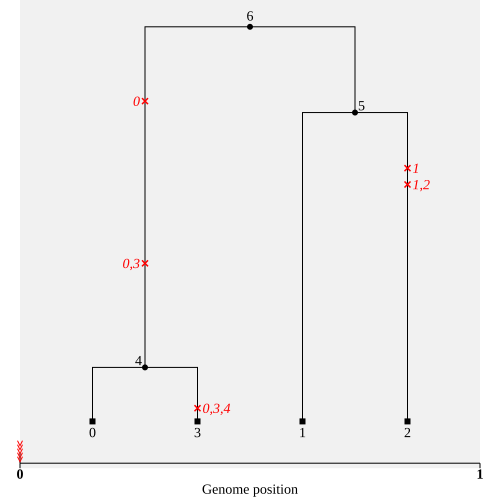

In [11]:
ml = {m.id: m.derived_state for m in mts_unique.mutations()}
mts_unique.draw_svg(size=(500, 500),mutation_labels=ml)

In [12]:
mts_unique.tables.nodes

id,time,flags,population,individual,metadata
0,0.00000000,1,0,0,"{'abundance': 5, 'fitness': 0.5710897..."
1,0.00000000,1,0,0,"{'abundance': 3, 'fitness': 1.0}"
2,0.00000000,1,0,1,"{'abundance': 1, 'fitness': 0.8217054..."
3,0.00000000,1,0,2,"{'abundance': 1, 'fitness': 0.6932039..."
4,0.26988078,0,0,-1,"{'abundance': 0, 'fitness': 0.5710897..."
5,1.54370518,0,0,-1,"{'abundance': 0, 'fitness': 1.0}"
6,1.97230077,0,0,-1,"{'abundance': 0, 'fitness': 1.0}"


### Merge trees

In [62]:
def prune_unique_genotypes_add_metadata(ts, s_mean=-0.1, s_std=0.1, baseline=1.0, seed=None):
    """
    Returns a new TreeSequence pruned to one sample per unique genotype and annotated with:
    - mutation metadata: {"s": float} with s ~ Normal(s_mean, s_std)
    - node metadata: {"fitness": float, "abundance": int, "mutation_count": int}
    - edge metadata: {"distance": int} = number of mutations on that branch
    Assumes haploid samples. Handles SLiMMutationModel stacking at each site.
    """
    rng = np.random.default_rng(seed)
    
    # 0) Define schema

    import tskit

    tables = ts.dump_tables()

    tables.edges.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "distance": {"type": "integer"},
    },
    "additionalProperties": False
    }
    })

    tables.nodes.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "fitness": {"type": "float"},
    "abundance":{"type": "integer"},
    "mutation_count": {"type": "integer"}
    },
    "additionalProperties": False
    }
    })

    tables.mutations.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "s": {"type": "float"}
    },
    "additionalProperties": False
    }
    })

    # 1) Annotate mutations with {"s": ...}
    muts = tables.mutations
    n_muts = muts.num_rows
    if n_muts > 0:
        s_vals = rng.normal(loc=s_mean, scale=s_std, size=n_muts)
        original_muts = list(ts.mutations())
        muts.clear()
        # tskit 1.0.0 does not have mutation time; guard in case
        has_time = hasattr(original_muts[0], "time")
        for i, m in enumerate(original_muts):
            if has_time:
                muts.add_row(site=m.site, node=m.node, derived_state=m.derived_state,
                             parent=m.parent, time=m.time, metadata={"s":float(s_vals[i])})
            else:
                muts.add_row(site=m.site, node=m.node, derived_state=m.derived_state,
                             parent=m.parent, metadata={"s":float(s_vals[i])})
    ts_s = tables.tree_sequence()
    
    # 2) Group haploid samples by unique multilocus genotype
    samples = ts_s.samples()
    num_samples = len(samples)
    # Stream genotypes per site to avoid full matrix
    genotype_components = [[] for _ in range(num_samples)]
    for var in ts_s.variants():
        g = var.genotypes
        for i in range(num_samples):
            genotype_components[i].append(int(g[i]))
    genotype_groups = {}
    for i in range(num_samples):
        key = tuple(genotype_components[i])  # empty tuple if no sites
        genotype_groups.setdefault(key, []).append(i)
    
    # Pick one representative per group; abundance = group size
    rep_indices = []
    abundance_by_rep_node = {}
    for idxs in genotype_groups.values():
        rep_i = min(idxs, key=lambda j: samples[j])  # stable representative choice
        rep_indices.append(rep_i)
        abundance_by_rep_node[samples[rep_i]] = len(idxs)

    rep_nodes = [samples[i] for i in rep_indices]
    
    # 3) Pre-annotate abundance for representative nodes in tables, then simplify
    nt = tables.nodes
    num_nodes = nt.num_rows
    flags = nt.flags
    time = nt.time
    population = nt.population
    individual = getattr(nt, "individual", np.full(num_nodes, tskit.NULL, dtype=np.int32))
    # Rebuild node table with abundance metadata
    nt.clear()
    for nid in range(num_nodes):
        nt.add_row(flags=flags[nid], time=time[nid], population=population[nid],
                   individual=individual[nid], metadata={"abundance": int(abundance_by_rep_node.get(nid, 0))})

    
    ts_pruned = tables.tree_sequence().simplify(samples=rep_nodes, keep_unary=False, filter_sites=False)
    
    # 4) Compute per-node fitness and cumulative mutation count on the pruned TS
    node_s_accum = np.zeros(ts_pruned.num_nodes, dtype=float)
    node_mut_accum = np.zeros(ts_pruned.num_nodes, dtype=np.int32)
    
    for site in ts_pruned.sites():
        site_muts = list(site.mutations)
        if not site_muts:
            continue
    
    tree = ts_pruned.at(site.position)
    roots = tree.roots if hasattr(tree, "roots") else ([tree.root] if tree.root != tskit.NULL else [])
    root_set = set(roots)
    
    # Per-site effects on child nodes
    edge_s = np.zeros(ts_pruned.num_nodes, dtype=float)
    edge_cnt = np.zeros(ts_pruned.num_nodes, dtype=np.int32)
    
    for m in site_muts:
        # Skip mutations placed on roots so root stays at baseline and count starts at 0
        if m.node not in root_set:
            edge_s[m.node] += float(m.metadata["s"])
            edge_cnt[m.node] += 1
    
    # Propagate s and counts from each root to tips
    for r in roots:
        stack = [(r, 0.0, 0)]
        while stack:
            u, s_contrib, c_contrib = stack.pop()
            node_s_accum[u] += s_contrib
            node_mut_accum[u] += c_contrib
            for v in tree.children(u):
                stack.append((v, s_contrib + edge_s[v], c_contrib + edge_cnt[v]))
    node_fitness = baseline + node_s_accum
    
    # 5) Final node metadata: {"fitness", "abundance", "mutation_count"} using cumulative counts
    tables2 = ts_pruned.dump_tables()
    nt2 = tables2.nodes
    num_nodes2 = nt2.num_rows
    flags2 = nt2.flags
    time2 = nt2.time
    population2 = nt2.population
    individual2 = getattr(nt2, "individual", np.full(num_nodes2, tskit.NULL, dtype=np.int32))
    abundance = dict(zip(range(nt2.num_rows),[row.metadata["abundance"] for row in nt2]))
    mutation_count = node_mut_accum.astype(np.int32)
    
    # Rebuild node table with final metadata
    nt2.clear()
    for nid in range(num_nodes2):
        nt2.add_row(
        flags=flags2[nid],
        time=time2[nid],
        population=population2[nid],
        individual=individual2[nid],
        metadata={
        "fitness": float(node_fitness[nid]),
        "abundance": int(abundance[nid]),
        "mutation_count": int(mutation_count[nid]),
        },
        )    
    
    # 6) Edge metadata: {"distance": number of mutations on that branch within [left, right)}
    et = tables2.edges
    num_edges = et.num_rows
    left = et.left
    right = et.right
    parent = et.parent
    child = et.child
    
    edge_meta = [""] * num_edges
    if num_edges > 0 and tables2.mutations.num_rows > 0:
        m_nodes = tables2.mutations.node
        m_sites = tables2.mutations.site
        site_pos = tables2.sites.position
        m_pos = site_pos[m_sites]
    
        order = np.lexsort((m_pos, m_nodes))
        nodes_sorted = m_nodes[order]
        pos_sorted = m_pos[order]
    
        unique_nodes, starts, counts = np.unique(nodes_sorted, return_index=True, return_counts=True)
        nrange_start = np.full(tables2.nodes.num_rows, -1, dtype=np.int64)
        nrange_count = np.zeros(tables2.nodes.num_rows, dtype=np.int64)
        nrange_start[unique_nodes] = starts
        nrange_count[unique_nodes] = counts
    
        for i in range(num_edges):
            c = child[i]
            s = nrange_start[c]
            cnt = 0
            if s >= 0:
                seg = pos_sorted[s : s + nrange_count[c]]
                lo = np.searchsorted(seg, left[i], side="left")
                hi = np.searchsorted(seg, right[i], side="left")
                cnt = int(hi - lo)
            edge_meta[i] = {"distance": cnt} 
    else:
        for i in range(num_edges):
            edge_meta[i] = {"distance": 0}
    
    # Rebuild edge table with metadata
    orig_left = np.array(left, copy=True)
    orig_right = np.array(right, copy=True)
    orig_parent = np.array(parent, copy=True)
    orig_child = np.array(child, copy=True)
    
    et.clear()
    for i in range(num_edges):
        et.add_row(left=orig_left[i], right=orig_right[i], parent=orig_parent[i],
                   child=orig_child[i], metadata=edge_meta[i])
    
    return(tables2.tree_sequence())


In [63]:
n=5

ts1 = msprime.sim_ancestry(n, random_seed=666, sequence_length=1)
mts1 = msprime.sim_mutations(
    ts1, 
    rate=mu, 
    model=msprime.SLiMMutationModel(type=1),
    random_seed=666)

ts2 = msprime.sim_ancestry(n, random_seed=110, sequence_length=1)
mts2 = msprime.sim_mutations(
    ts2, 
    rate=mu, 
    model=msprime.SLiMMutationModel(type=1),
    random_seed=110)

mts1_unique=prune_unique_genotypes_add_metadata(mts1, s_mean=-0.1, s_std=0.1, baseline=1.0, seed=None)
mts2_unique=prune_unique_genotypes_add_metadata(mts2, s_mean=-0.1, s_std=0.1, baseline=1.0, seed=None)

print(mts1_unique.first().newick(precision=1,node_labels=dict(zip(list(range(mts1_unique.num_nodes)),list(range(mts1_unique.num_nodes))))))
print(mts2_unique.first().newick(precision=1,node_labels=dict(zip(list(range(mts2_unique.num_nodes)),list(range(mts2_unique.num_nodes))))))


((0:0.3,3:0.3)4:1.7,(1:1.5,2:1.5)5:0.4)6;
(1:1.3,(0:1.1,(2:0.5,3:0.5)4:0.5)5:0.3)6;


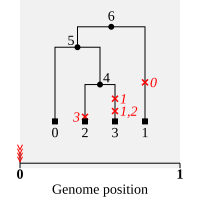

In [64]:
ml = {m.id: m.derived_state for m in mts2_unique.mutations()}
mts2_unique.draw_svg(mutation_labels=ml)

In [65]:
(((0_0:0.3,0_3:0.3)4:1.7,(0_1:1.5,0_2:1.5)0_5:0.4)0_6,((1_5:1.0,(1_0:0.4,1_4:0.4)1_6:0.6)1_8:1.3,(1_1:1.4,(1_2:0.6,1_3:0.6)1_7:0.8)1_9:0.8)1_10);

(((0_0:0.3,0_3:0.3)4:1.7,(0_1:1.5,0_2:1.5)0_5:0.4,(1_5:1.0,(1_0:0.4,1_4:0.4)1_6:0.6)1_8:1.3,(1_1:1.4,(1_2:0.6,1_3:0.6)1_7:0.8)1_9:0.8));


SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (4050114904.py, line 1)

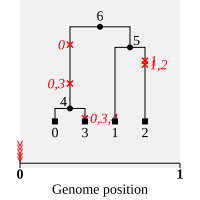

In [66]:
ml = {m.id: m.derived_state for m in mts1_unique.mutations()}
mts1_unique.draw_svg(mutation_labels=ml)

In [67]:
def NoteTable_to_pandasDF(nt=mts.tables.nodes):
    df = pd.DataFrame({
    "id": np.arange(nt.num_rows, dtype=np.int32),
    "flags": np.array(nt.flags, copy=False),
    "time": np.array(nt.time, copy=False),
    "population": np.array(nt.population, copy=False),
    "individual": np.array(getattr(nt, "individual",
    np.full(nt.num_rows, -1, dtype=np.int32)),
    copy=False),
    })
    md_rows = [row.metadata for row in nt]
    
    if md_rows and isinstance(md_rows[0], dict):
        md_df = pd.DataFrame(md_rows).fillna(pd.NA)
        df = pd.concat([df, md_df], axis=1)
    else:
        # If bytes, try JSON decode; otherwise keep raw bytes in a single column
        try:
            decoded = [json.loads(m) if isinstance(m, (bytes, bytearray)) and len(m) > 0 else {}
            for m in md_rows]
            md_df = pd.DataFrame(decoded).fillna(pd.NA)
            df = pd.concat([df, md_df], axis=1)
        except Exception:
            df["metadata"] = md_rows
    return(df)

df=NoteTable_to_pandasDF(mts1_unique.tables.nodes)
df

,id,flags,time,population,individual,abundance,fitness,mutation_count
0,0,1,0.000000,0,0,5,0.672663,2
1,1,1,0.000000,0,0,3,1.000000,0
2,2,1,0.000000,0,1,1,0.880172,2
3,3,1,0.000000,0,2,1,0.576524,3
4,4,0,0.269881,0,-1,0,0.672663,2
5,5,0,1.543705,0,-1,0,1.000000,0
6,6,0,1.972301,0,-1,0,1.000000,0


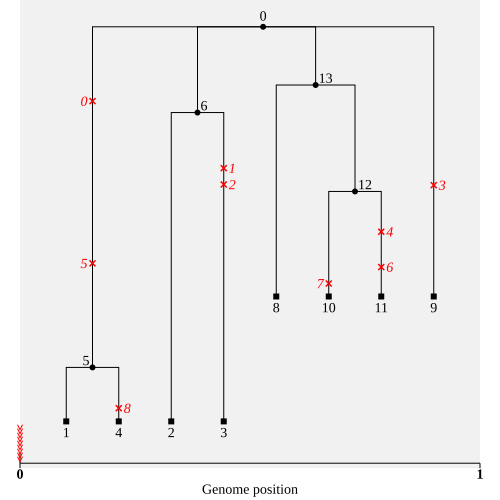

In [68]:
import numpy as np
import tskit
import math

def merge_trees_by_root_with_metadata_slim(ts_list,tree_index=0,prefixes=None,sequence_length=1.0,root_time=None,
                                           label_mode="all",root_metadata=None,site_ancestral_state=None,site_metadata=None):
    """
    Merge selected trees from multiple TreeSequences by the root, for SLiM one-site genomes.
    Output has exactly one site: id=0, position=0. All mutations are remapped to that site.
    Parameters:
    - ts_list: list of tskit.TreeSequence
    - tree_index: which tree (index) to take from each input
    - prefixes: list of label prefixes per input (default: "0_", "1_", ...)
    - sequence_length: float; output spans a single interval [0, sequence_length)
    - root_time: float; if None, uses max(root times) to preserve branch lengths
    - label_mode: "all" to label all nodes; "leaves" to label only samples; "none" for no labels
    - root_metadata: dict for synthetic root node metadata
    - site_ancestral_state: optional string to set output ancestral_state for the single site
    - site_metadata: optional dict to set output site metadata
    
    Returns:
    - merged_ts: TreeSequence
    - node_labels: dict mapping output node id -> label
    """
    if prefixes is None:
        prefixes = [f"{i}_" for i in range(len(ts_list))]
    if len(prefixes) != len(ts_list):
        raise ValueError("prefixes length must match number of inputs")
    
    def get_tree(ts, idx):
        if idx < 0 or idx >= ts.num_trees:
            raise IndexError(f"tree_index {idx} out of range for input with {ts.num_trees} trees")
        # Position a Tree at the left coordinate of the idx-th tree
        lefts = list(ts.breakpoints())
        return( ts.at(lefts[idx]))
    
    # Collect trees and root times
    trees = []
    roots = []
    root_times = []
    for i, ts in enumerate(ts_list):
        t = get_tree(ts, tree_index)
        rts = t.roots if hasattr(t, "roots") else ([t.root] if t.root != tskit.NULL else [])
        if len(rts) != 1:
            raise ValueError(f"Input {i} has {len(rts)} roots; expected 1")
        r = rts[0]
        trees.append(t)
        roots.append(r)
        root_times.append(ts.node(r).time)
    
    # Choose common root time and per-tree time shifts to preserve branch lengths
    T = max(root_times) if root_time is None else float(root_time)
    shifts = [T - rt for rt in root_times]
    
    
    tables = tskit.TableCollection(sequence_length=float(sequence_length))
    tables.edges.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "distance": {"type": "integer"},
    },
    "additionalProperties": False
    }
    })

    tables.nodes.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "fitness": {"type": "float"},
    "abundance":{"type": "integer"},
    "mutation_count": {"type": "integer"}
    },
    "additionalProperties": False
    }
    })

    tables.mutations.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "s": {"type": "float"}
    },
    "additionalProperties": False
    }
    })
    
    tables.sites.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {},
    "additionalProperties": False
    }
    })    
    # Single SLiM site first: id=0, position=0
    if site_ancestral_state is None:
        # Try to take from the first available input site row
        site_ancestral_state = ""
        for ts in ts_list:
            if ts.num_sites > 0:
                site_ancestral_state = ts.tables.sites[0].ancestral_state
                break
    if site_metadata is None:
        # Take the first non-empty site metadata if present
        for ts in ts_list:
            if ts.num_sites > 0:
                md = ts.tables.sites[0].metadata
                if md not in (None, {}, b"", "", []):
                    site_metadata = md
                    break
    if site_metadata is None:
        site_metadata = {}
    site0_id = tables.sites.add_row(position=0.0, ancestral_state=site_ancestral_state, metadata=site_metadata)
    assert site0_id == 0, "Site id is expected to be 0"
    
    # Synthetic root node
    root_out_md = {} if root_metadata is None else dict(root_metadata)
    root_out = tables.nodes.add_row(time=T, flags=0, population=tskit.NULL, individual=tskit.NULL, metadata=root_out_md)
    
    # Map input node IDs to output node IDs and labels
    node_maps = []
    node_labels = {}
    for i, ts in enumerate(ts_list):
        m = np.full(ts.num_nodes, -1, dtype=np.int32)
        prefix = prefixes[i]
        shift = shifts[i]
        is_sample = np.zeros(ts.num_nodes, dtype=bool)
        is_sample[ts.samples()] = True
        for u in range(ts.num_nodes):
            n = ts.node(u)
            new_id = tables.nodes.add_row(
                time=n.time + shift,
                flags=n.flags,
                population=tskit.NULL,  # set NULL; copy populations/individuals if needed
                individual=tskit.NULL,
                metadata=n.metadata,
            )
            m[u] = new_id
            if label_mode == "all" or (label_mode == "leaves" and is_sample[u]):
                node_labels[new_id] = f"{prefix}{u}"
        node_maps.append(m)
    
    # Add edges: reparent root children to the synthetic root; copy metadata
    SL = float(sequence_length)
    for i, (ts, tree, r_in) in enumerate(zip(ts_list, trees, roots)):
        m = node_maps[i]
        for u in tree.nodes():
            p = tree.parent(u)
            if p == tskit.NULL:
                continue
            # Edge row for parent->u in this tree (to get metadata if available)
            e_id = getattr(tree, "edge", lambda _: tskit.NULL)(u)
            if e_id != tskit.NULL:
                e_row = ts.tables.edges[e_id]
                md = e_row.metadata
            else:
                md = None
            parent_out = root_out if p == r_in else m[p]
            child_out = m[u]
            tables.edges.add_row(left=0.0, right=SL, parent=parent_out, child=child_out, metadata=md)
    
    # Copy mutations: remap node to merged ID, site -> 0, shift time; copy metadata
    for i, ts in enumerate(ts_list):
        m_map = node_maps[i]
        # Detect a usable mutation time column
        has_mut_time = hasattr(ts.tables.mutations, "time") and len(ts.tables.mutations.time) == ts.num_mutations
        shift = shifts[i]
    
        mut_id_map = np.full(ts.num_mutations, -1, dtype=np.int32)
        pending = list(range(ts.num_mutations))
    
        # Resolve parent references robustly (parent-first ordering)
        while pending:
            progressed = False
            next_pending = []
            for old_mid in pending:
                m = ts.tables.mutations[old_mid]
                parent_ok = (m.parent == tskit.NULL) or (mut_id_map[m.parent] != -1)
                if parent_ok:
                    new_parent = tskit.NULL if m.parent == tskit.NULL else mut_id_map[m.parent]
                    new_mid = tables.mutations.add_row(
                        site=0,  # single output site
                        node=m_map[m.node],
                        derived_state=m.derived_state,
                        parent=new_parent,
                        time=(m.time + shift) if has_mut_time and m.time is not None else None,
                        metadata=m.metadata,
                    )
                    mut_id_map[old_mid] = new_mid
                    progressed = True
                else:
                    next_pending.append(old_mid)
            if not progressed:
                raise ValueError("Could not resolve mutation.parent references; cycle or missing parent?")
            pending = next_pending

    
    tables.sort()
    merged_ts = tables.tree_sequence()
    return(merged_ts, node_labels)

    


cat_ts, node_labels=merge_trees_by_root_with_metadata_slim([mts1_unique,mts2_unique],tree_index=0,prefixes=None,sequence_length=1.0,root_time=None,
                                           label_mode="all",root_metadata={'abundance':0, 'fitness':1, 'mutation_count':0},site_ancestral_state=None,site_metadata=None)
cat_ts.draw_svg(size=(500,500))

In [69]:
print(cat_ts.first().newick(precision=1,node_labels=dict(zip(list(range(cat_ts.num_nodes)),list(range(cat_ts.num_nodes))))))

# ((1:0.3,4:0.3)5:1.7,(2:1.5,3:1.5)6:0.4,(8:0.3,11:0.3)12:1.7,(9:1.5,10:1.5)13:0.4)0;

# ((1:0.3,4:0.3)5:1.7,(2:1.5,3:1.5,10:1.5)6:0.4,(8:0.3,11:0.3)12:1.7,(9:1.5)13:0.4)0;


((1:0.3,4:0.3)5:1.7,(2:1.5,3:1.5)6:0.4,9:1.3,(8:1.1,(10:0.5,11:0.5)12:0.5)13:0.3)0;


In [70]:
df=NoteTable_to_pandasDF(cat_ts.tables.nodes)
df

,id,flags,time,population,individual,abundance,fitness,mutation_count
0,0,0,1.972301,-1,-1,0,1.000000,0
1,1,1,0.000000,-1,-1,5,0.672663,2
2,2,1,0.000000,-1,-1,3,1.000000,0
3,3,1,0.000000,-1,-1,1,0.880172,2
4,4,1,0.000000,-1,-1,1,0.576524,3
5,5,0,0.269881,-1,-1,0,0.672663,2
6,6,0,1.543705,-1,-1,0,1.000000,0
7,7,0,1.972301,-1,-1,0,1.000000,0
8,8,1,0.624330,-1,-1,5,1.000000,0
9,9,1,0.624330,-1,-1,1,1.087416,1


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[(5, {'abundance': 0, 'fitness': 0.6726625005022058}), (1, {'abundance': 5, 'fitness': 0.6726625005022058}), (4, {'abundance': 1, 'fitness': 0.576523619697809}), (12, {'abundance': 0, 'fitness': 1.0}), (10, {'abundance': 1, 'fitness': 0.7390105220311143}), (11, {'abundance': 3, 'fitness': 0.5700822404287371}), (6, {'abundance': 0, 'fitness': 1.0}), (2, {'abundance': 8, 'fitness': 1.0}), (3, {'abundance': 1, 'fitness': 0.8801721965027973}), (0, {'abundance': 0, 'fitness': nan}), (9, {'abundance': 1, 'fitness': 1.087415685123156})]
Graph with 11 nodes and 10 edges


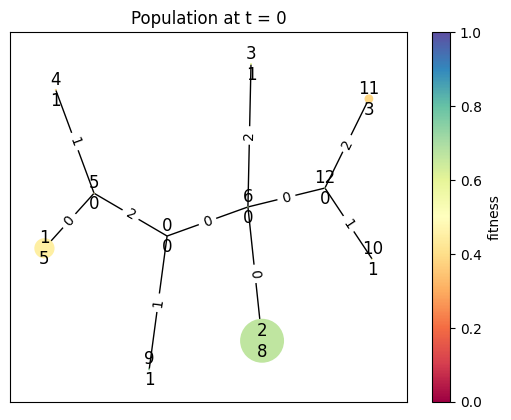

In [86]:
import networkx as nx
from project_package.tskit_functions import merge_by_root_and_combine_ancestrals
%load_ext autoreload
%autoreload 2
    
merged_ts=merge_by_root_and_combine_ancestrals([mts1_unique,mts2_unique]) 
def to_networkx_graph(ts):
    edges=ts.tables.edges
    nodes=ts.tables.nodes

    G = nx.from_pandas_edgelist(
        pd.DataFrame({'source': edges.parent, 'target': edges.child, 'left': edges.left, 'right': edges.right,'distance':[d.metadata["distance"] for d in edges]}),
        edge_attr=True,
        create_using=nx.Graph
    )

    # nx.set_edge_attributes(G, {i: {'distance':edges[i].metadata["distance"]} for i in range(len(edges))})
    nx.set_node_attributes(G, {i: {'abundance':nodes[i].metadata["abundance"], 'fitness': nodes[i].metadata["fitness"]} for i in range(len(nodes))})
    print(G.nodes(data=True))

    return G

G = to_networkx_graph(merged_ts)
print(G)
visualize_pop(G)

Graph with 7 nodes and 6 edges


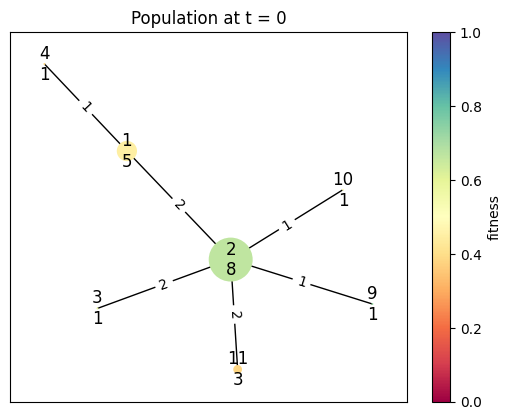

In [87]:

G = tstree_to_networkx_graph(merged_ts)
print(G)
visualize_pop(G)

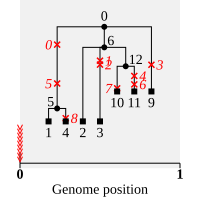

In [84]:
merged_ts.draw_svg()

In [75]:
G.nodes(data=True)

NodeDataView({5: {'abundance': 0, 'fitness': 0.6726625005022058}, 1: {'abundance': 5, 'fitness': 0.6726625005022058}, 4: {'abundance': 1, 'fitness': 0.576523619697809}, 12: {'abundance': 0, 'fitness': 1.0}, 10: {'abundance': 1, 'fitness': 0.7390105220311143}, 11: {'abundance': 3, 'fitness': 0.5700822404287371}, 6: {'abundance': 0, 'fitness': 1.0}, 2: {'abundance': 8, 'fitness': 1.0}, 3: {'abundance': 1, 'fitness': 0.8801721965027973}, 0: {'abundance': 0, 'fitness': {'type': 'float'}}, 9: {'abundance': 1, 'fitness': 1.087415685123156}})

### Merge trees and ancestral genotype

#### trial 1: rewrite function

In [60]:
import numpy as np
import tskit

def merge_trees_by_root_with_metadata_slim_merge_ancestral(ts_list,tree_index=0,prefixes=None,sequence_length=1.0,root_time=None,
                                                           label_mode="all",root_metadata=None,site_ancestral_state=None,
                                                           site_metadata=None,length_round_decimals=12,merge_edge_metadata=True):
    """
    Merge selected trees from multiple TreeSequences by the root for SLiM one-site genomes,
    and collapse root->child branches that have no mutations at the single site.
    
    Output:
      - One site: id=0, position=0
      - Synthetic root at time T
      - For each unique branch length L from root to a mutation-free child across inputs,
        a single shared node at time T-L with one root->shared edge; all descendants of
        such children from all inputs attach under that shared node.
      - All other (mutated) root children remain separate per input.
    
    Parameters:
      - ts_list: list of tskit.TreeSequence
      - tree_index: which tree to take from each input
      - prefixes, sequence_length, root_time, label_mode, root_metadata,
        site_ancestral_state, site_metadata: same meaning as before
      - length_round_decimals: rounding for branch length keys to avoid float mismatches
      - merge_edge_metadata: if True, root->shared edge metadata accumulates per-input metadata
    
    Returns:
      - merged_ts, node_labels
    """
    if prefixes is None:
        prefixes = [f"{i}_" for i in range(len(ts_list))]
    if len(prefixes) != len(ts_list):
        raise ValueError("prefixes length must match number of inputs")
    
    def get_tree(ts, idx):
        if idx < 0 or idx >= ts.num_trees:
            raise IndexError(f"tree_index {idx} out of range for input with {ts.num_trees} trees")
        lefts = list(ts.breakpoints())
        return( ts.at(lefts[idx]))
    
    # Collect trees and root times
    trees, roots, root_times = [], [], []
    for i, ts in enumerate(ts_list):
        t = get_tree(ts, tree_index)
        rts = t.roots if hasattr(t, "roots") else ([t.root] if t.root != tskit.NULL else [])
        if len(rts) != 1:
            raise ValueError(f"Input {i} has {len(rts)} roots; expected 1")
        r = rts[0]
        trees.append(t)
        roots.append(r)
        root_times.append(ts.node(r).time)
    
    # Common root time and shifts
    T = max(root_times) if root_time is None else float(root_time)
    shifts = [T - rt for rt in root_times]
    SL = float(sequence_length)
    
    tables = tskit.TableCollection(sequence_length=SL)
    tables.edges.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "distance": {"type": "integer"},
    },
    "additionalProperties": False
    }
    })

    tables.nodes.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "fitness": {"type": "float"},
    "abundance":{"type": "integer"},
    "mutation_count": {"type": "integer"}
    },
    "additionalProperties": False
    }
    })

    tables.mutations.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "s": {"type": "float"}
    },
    "additionalProperties": False
    }
    })
    
    tables.sites.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {},
    "additionalProperties": False
    }
    })    
    
    # Single site id=0 at position=0
    if site_ancestral_state is None:
        site_ancestral_state = ""
        for ts in ts_list:
            if ts.num_sites > 0:
                site_ancestral_state = ts.tables.sites[0].ancestral_state
                break
    if site_metadata is None:
        for ts in ts_list:
            if ts.num_sites > 0:
                md = ts.tables.sites[0].metadata
                if md not in (None, {}, b"", "", []):
                    site_metadata = md
                    break
    if site_metadata is None:
        site_metadata = {}
    site0_id = tables.sites.add_row(position=0.0, ancestral_state=site_ancestral_state, metadata=site_metadata)
    assert site0_id == 0
    
    # Synthetic root
    root_out = tables.nodes.add_row(time=T, flags=0, population=tskit.NULL, individual=tskit.NULL,
                                    metadata=({} if root_metadata is None else dict(root_metadata)))
    
    # Detect mutation on root->child edge for each input; group mutation-free children by branch length
    def node_has_mutation_on_edge(ts, node_id):
        # In tskit, mutations on edge parent->node are stored with m.node == node_id
        # (we ignore genome intervals since SLiM one-site model)
        # Restrict to mutations present anywhere; sufficient for single site
        for m in ts.tables.mutations:
            if m.node == node_id:
                return True
        return False
    
    # Collect per-input root children info
    rf_groups = {}  # key = rounded branch length L; value = dict with 'time', 'members', 'edge_mds'
    rf_member_meta = {}  # optional merged node metadata per group (first seen)
    for i, (ts, t, r_in, shift) in enumerate(zip(ts_list, trees, roots, shifts)):
        r_time_out = ts.node(r_in).time + shift  # equals T
        for c in t.children(r_in):
            has_mut = node_has_mutation_on_edge(ts, c)
            # Compute branch length from root: parent_time - child_time
            child_time_out = ts.node(c).time + shift
            L = round(r_time_out - child_time_out, length_round_decimals)
            if not has_mut:
                if L not in rf_groups:
                    rf_groups[L] = {"time": T - float(L), "members": [], "edge_mds": []}
                rf_groups[L]["members"].append((i, c))  # track (input index, child id)
                # Try to capture edge metadata for r_in->c
                e_id = t.edge(c)
                if e_id != tskit.NULL:
                    rf_groups[L]["edge_mds"].append(ts.tables.edges[e_id].metadata)
                else:
                    rf_groups[L]["edge_mds"].append(None)
                # Store first-seen node metadata to reuse on shared node (optional)
                if L not in rf_member_meta:
                    rf_member_meta[L] = ts.node(c).metadata
    
    # Create shared nodes for each mutation-free group L
    shared_node_id = {}
    for L, info in rf_groups.items():
        md = rf_member_meta.get(L, {})
        nid = tables.nodes.add_row(time=info["time"], flags=0, population=tskit.NULL, individual=tskit.NULL, metadata=md)
        shared_node_id[L] = nid
        # Add one root->shared edge; optionally merge edge metadata from members
        if merge_edge_metadata:
            merged_md = {"merged_from": []}
            for idx, md_i in enumerate(info["edge_mds"]):
                merged_md["merged_from"].append({"source_index": idx, "metadata": md_i})
        else:
            merged_md = info["edge_mds"][0] if len(info["edge_mds"]) > 0 else None
        tables.edges.add_row(left=0.0, right=SL, parent=root_out, child=nid, metadata=merged_md)
    
    # Build node maps; reuse shared node for mutation-free root children
    node_maps = []
    node_labels = {}
    for i, ts in enumerate(ts_list):
        m = np.full(ts.num_nodes, -1, dtype=np.int32)
        is_sample = np.zeros(ts.num_nodes, dtype=bool)
        is_sample[ts.samples()] = True
        shift = shifts[i]
        prefix = prefixes[i]
    
        # First mark which root children are mutation-free and get their L
        t = trees[i]
        r_in = roots[i]
        rf_children = {}
        r_time_out = ts.node(r_in).time + shift  # equals T
        for c in t.children(r_in):
            if not node_has_mutation_on_edge(ts, c):
                child_time_out = ts.node(c).time + shift
                L = round(r_time_out - child_time_out, length_round_decimals)
                rf_children[c] = L
    
        # Add nodes; skip separate rows for rf_children (map to shared node instead)
        for u in range(ts.num_nodes):
            # If u is a mutation-free root child, map to shared and do not add a new row
            if u in rf_children:
                m[u] = shared_node_id[rf_children[u]]
                # Labeling: don't label internal shared nodes unless label_mode == "all"
                if label_mode == "all":
                    # Optional: keep first label assigned; subsequent will overwrite identically
                    node_labels[m[u]] = f"{prefix}{u}"
                continue
    
            n = ts.node(u)
            new_id = tables.nodes.add_row(
                time=n.time + shift,
                flags=n.flags,
                population=tskit.NULL,
                individual=tskit.NULL,
                metadata=n.metadata,
            )
            m[u] = new_id
            if label_mode == "all" or (label_mode == "leaves" and is_sample[u]):
                node_labels[new_id] = f"{prefix}{u}"
        node_maps.append(m)
    
    # Add edges for each input tree; for mutation-free root children, skip the root->child edge
    for i, (ts, tree, r_in) in enumerate(zip(ts_list, trees, roots)):
        m = node_maps[i]
        for u in tree.nodes():
            p = tree.parent(u)
            if p == tskit.NULL:
                continue
    
            # If this edge is r_in -> u and u is mutation-free root child, skip:
            if p == r_in and (u in tree.children(r_in)) and (m[u] in shared_node_id.values()):
                # The shared root->node edge was already added once per group
                continue
    
            # Use original metadata if available
            e_id = tree.edge(u)
            md = ts.tables.edges[e_id].metadata if e_id != tskit.NULL else None
    
            parent_out = root_out if p == r_in else m[p]
            child_out = m[u]
            tables.edges.add_row(left=0.0, right=SL, parent=parent_out, child=child_out, metadata=md)
    
    # Copy mutations: remap node to merged ID, site -> 0, shift time; copy metadata
    for i, ts in enumerate(ts_list):
        m_map = node_maps[i]
        has_mut_time = hasattr(ts.tables.mutations, "time") and len(ts.tables.mutations.time) == ts.num_mutations
        shift = shifts[i]
    
        mut_id_map = np.full(ts.num_mutations, -1, dtype=np.int32)
        pending = list(range(ts.num_mutations))
    
        while pending:
            progressed = False
            next_pending = []
            for old_mid in pending:
                mrow = ts.tables.mutations[old_mid]
                parent_ok = (mrow.parent == tskit.NULL) or (mut_id_map[mrow.parent] != -1)
                if parent_ok:
                    new_parent = tskit.NULL if mrow.parent == tskit.NULL else mut_id_map[mrow.parent]
                    new_mid = tables.mutations.add_row(
                        site=0,  # single SLiM site
                        node=m_map[mrow.node],
                        derived_state=mrow.derived_state,
                        parent=new_parent,
                        time=(mrow.time + shift) if has_mut_time and mrow.time is not None else None,
                        metadata=mrow.metadata,
                    )
                    mut_id_map[old_mid] = new_mid
                    progressed = True
                else:
                    next_pending.append(old_mid)
            if not progressed:
                raise ValueError("Could not resolve mutation.parent references; cycle or missing parent?")
            pending = next_pending
    
    tables.sort()
    merged_ts = tables.tree_sequence()
    return( merged_ts, node_labels)



def merge_trees_by_root_with_metadata_slim_trim(
ts,
abundance_key="abundance",
mutation_key="mutation_count",
preserve_branch_lengths_when_possible=True,
shift_mutation_times=True,
remove_move_leaf_sample_flag=True,
epsilon=1e-9,
):
    """
    Merge duplicate terminal lineages under the single root:
    - keep_leaf = first terminal sample node with metadata[abundance] > 0 and metadata[mutation_count] == 0,
    - move_leafs = all subsequent terminal sample nodes with the same condition.
    For each move_leaf:
    * Regraft all other children of its parent p_move (children except move_leaf) under p_keep,
    * Remove edges (root -> p_move) and (p_move -> move_leaf),
    * Add move_leaf's abundance into keep_leaf's abundance (integer per schema).
    Optionally clear move_leaf sample flags.
    
    Assumptions:
    - Single tree across the sequence (one root).
    - Node, edge, mutation, site metadata schemas are set as you specified.
    - keep_leaf and move_leafs are under internal parents that are direct children of the root.
    """
    if ts.num_trees != 1:
        # The logic assumes one tree over the whole sequence.
        # If you have multiple trees, you'll need to iterate and apply per tree.
        raise ValueError("Expected a single tree across the sequence")
    
    tree = ts.first()
    root = tree.root
    if root == tskit.NULL:
        raise ValueError("No root found")
    # tskit uses time increasing into the past: parent time > child time
    
    def is_terminal_sample(u):
        return( ((ts.node(u).flags & tskit.NODE_IS_SAMPLE) != 0) and (tree.num_children(u) == 0))
    
    def md_ok(u):
        md = ts.node(u).metadata or {}
        return( (md.get(abundance_key, 0) > 0) and (md.get(mutation_key, 0) == 0))
    
    # Collect terminal samples with the required metadata
    leaves_in_order = list(tree.leaves(root))
    candidates = [u for u in leaves_in_order if is_terminal_sample(u) and md_ok(u)]
    if len(candidates) <= 1:
        # Nothing to merge
        return ts
    
    keep_leaf = candidates[0]
    move_leafs = candidates[1:]
    
    # Validate parents under root
    p_keep = tree.parent(keep_leaf)
    if p_keep == tskit.NULL or tree.parent(p_keep) != root:
        raise ValueError("keep_leaf must be under an internal parent that is a direct child of the root")
    
    # Build mapping from move parent to its move_leaf (one per parent here) and collect their parents
    move_by_parent = {}
    p_moves = set()
    for u in move_leafs:
        p = tree.parent(u)
        if p == tskit.NULL or tree.parent(p) != root:
            raise ValueError(f"move_leaf {u} must be under an internal parent that is a child of the root")
        move_by_parent[p] = u
        p_moves.add(p)
    
    tables = ts.dump_tables()
    
    # Build children map from current edges
    children_of = defaultdict(set)
    for e in tables.edges:
        children_of[e.parent].add(e.child)
    
    # For each p_move, identify its children to reparent (exclude the move_leaf itself)
    roots_to_move = {}  # p_move -> list of child roots to reattach under p_keep
    for p in p_moves:
        mv = move_by_parent[p]
        roots_to_move[p] = [c for c in children_of[p] if c != mv]
    
    # Shift times for moved subtrees when p_move is older than p_keep to preserve branch lengths
    nodes_to_shift_global = set()
    t_keep = ts.node(p_keep).time
    for p in p_moves:
        t_move = ts.node(p).time
        delta = t_move - t_keep  # >0 means p_move older than p_keep
        if not (preserve_branch_lengths_when_possible and delta >= 0 and roots_to_move[p]):
            continue
        # BFS collect nodes under each child in roots_to_move[p]
        nodes_to_shift = set()
        for r in roots_to_move[p]:
            q = deque([r])
            while q:
                u = q.popleft()
                if u in nodes_to_shift:
                    continue
                nodes_to_shift.add(u)
                for v in children_of.get(u, ()):
                    q.append(v)
        # Shift node times forward by delta
        for u in nodes_to_shift:
            tables.nodes.time[u] = tables.nodes.time[u] - delta
        nodes_to_shift_global |= nodes_to_shift
        # Optionally shift mutation times for those nodes
        if shift_mutation_times and tables.mutations.num_rows > 0:
            for mid in range(tables.mutations.num_rows):
                n = tables.mutations.node[mid]
                if n in nodes_to_shift:
                    mt = tables.mutations.time[mid]
                    if mt is not None and not (isinstance(mt, float) and math.isnan(mt)):
                        tables.mutations.time[mid] = mt - delta
        # Ensure each moved child is strictly younger than new parent p_keep
        for r in roots_to_move[p]:
            if not (tables.nodes.time[r] < t_keep - epsilon):
                raise ValueError(
                    f"Shifted child {r} (time={tables.nodes.time[r]}) not younger than new parent {p_keep} (time={t_keep})"
                )
    
    # Rebuild edge table:
    # - drop (root -> p_move) and (p_move -> move_leaf) for all p_move
    # - reparent edges (p_move -> child) for child in roots_to_move[p] to p_keep
    to_add_edges = []
    kept_edges = []
    for e in tables.edges:
        if e.parent in p_moves:
            mv = move_by_parent[e.parent]
            if e.child == mv:
                # Drop p_move -> move_leaf
                continue
            if e.child in roots_to_move[e.parent]:
                # Reattach under p_keep
                to_add_edges.append((e.left, e.right, p_keep, e.child, e.metadata))
                continue
            # If an unexpected child remains (shouldn't), keep it as-is
            kept_edges.append(e)
            continue
        # Drop root -> p_move edges
        if e.parent == root and e.child in p_moves:
            continue
        kept_edges.append(e)
    
    tables.edges.clear()
    for e in kept_edges:
        tables.edges.add_row(left=e.left, right=e.right, parent=e.parent, child=e.child, metadata=e.metadata)
    for left, right, parent, child, md in to_add_edges:
        # parent>child time constraint
        if not (tables.nodes.time[parent] > tables.nodes.time[child] + epsilon):
            raise ValueError(
                f"Invalid parent-child times after reparenting: parent {parent} (time={tables.nodes.time[parent]}) "
                f"<= child {child} (time={tables.nodes.time[child]})"
            )
        tables.edges.add_row(left=left, right=right, parent=parent, child=child, metadata=md)
    
    # Update keep_leaf metadata: add abundances from all move_leafs
    keep_md = dict(ts.node(keep_leaf).metadata or {})
    total_add = 0
    for u in move_leafs:
        md = ts.node(u).metadata or {}
        try:
            total_add += int(md.get(abundance_key, 0))
        except Exception:
            # If malformed, treat as zero
            pass
    try:
        base = int(keep_md.get(abundance_key, 0))
    except Exception:
        base = 0
    keep_md[abundance_key] = base + total_add  # integer per schema
    
    # Optionally clear sample flags for move_leafs
    flags = tables.nodes.flags.copy()
    if remove_move_leaf_sample_flag:
        for u in move_leafs:
            flags[u] = flags[u] & ~tskit.NODE_IS_SAMPLE
    
    # Rebuild NodeTable using metadata_schema.encode_row to avoid manual buffers
    node_tbl = tables.nodes
    schema = node_tbl.metadata_schema
    times = node_tbl.time.copy()          # includes any shifts above
    pops = node_tbl.population.copy()
    indivs = node_tbl.individual.copy()
    
    original_num_rows = node_tbl.num_rows
    node_tbl.clear()
    node_tbl.metadata_schema = schema
    
    for i in range(original_num_rows):
        if i == keep_leaf:
            md_dict = keep_md
        else:
            md_dict = ts.node(i).metadata or {}
        md_bytes = schema.encode_row(md_dict)
        node_tbl.add_row(
            flags=flags[i],
            time=times[i],
            population=pops[i],
            individual=indivs[i],
            metadata=md_bytes,
        )
    
    tables.sort()
    return( tables.tree_sequence())



# cat_ts, node_labels=merge_trees_by_root_with_metadata_slim_merge_ancestral([mts1_unique,mts1_unique,mts2_unique],prefixes=None,sequence_length=1.0,root_time=None,
#                                                            label_mode="all",root_metadata={'abundance':0, 'fitness':1, 'mutation_count':0},
#                                                                            site_ancestral_state=None,site_metadata=None,length_round_decimals=12,
#                                                                            merge_edge_metadata=True)
                                                                           
cat_ts=merge_trees_by_root_with_metadata_slim_trim([mts1_unique,mts1_unique,mts2_unique])                                                                           
cat_ts.draw_svg()

AttributeError: 'list' object has no attribute 'num_trees'

In [61]:
import tskit
import numpy as np
from collections import defaultdict, deque
import math

def merge_by_root_and_combine_ancestrals(
ts_list,
tree_index=0,
prefixes=None,
sequence_length=1.0,
root_time=None,
label_mode="all",
root_metadata=None,
site_ancestral_state=None,
site_metadata=None,
abundance_key="abundance",
mutation_key="mutation_count",
preserve_branch_lengths_when_possible=True,
shift_mutation_times=True,
remove_move_leaf_sample_flag=True,
epsilon=1e-9,
):
    """
    Merge selected trees from multiple TreeSequences by the root (single SLiM site),
    then prune & regraft duplicate terminal lineages:
    - keep_leaf = first terminal sample with metadata[abundance] > 0 and metadata[mutation_count] == 0,
    - move_leafs = all subsequent terminal samples with the same condition.
    For each move_leaf:
    * Regraft all other children of its parent (excluding move_leaf) under keep_leaf's parent,
    * Remove edges (root -> p_move) and (p_move -> move_leaf),
    * Add move_leaf's abundance into keep_leaf's abundance (integer).
    Optionally clear move_leaf sample flags.
    
    Returns:
      merged_ts: TreeSequence after merge+prune/regraft
      node_labels: dict mapping output node id -> label
    """
    if prefixes is None:
        prefixes = [f"{i}_" for i in range(len(ts_list))]
    if len(prefixes) != len(ts_list):
        raise ValueError("prefixes length must match number of inputs")
    
    # Helper: position a Tree at the left coordinate of the idx-th tree
    def get_tree(ts, idx):
        if idx < 0 or idx >= ts.num_trees:
            raise IndexError(f"tree_index {idx} out of range for input with {ts.num_trees} trees")
        lefts = list(ts.breakpoints())
        return ts.at(lefts[idx])
    
    # Collect trees and root times
    trees = []
    roots = []
    root_times = []
    for i, ts in enumerate(ts_list):
        t = get_tree(ts, tree_index)
        rts = t.roots if hasattr(t, "roots") else ([t.root] if t.root != tskit.NULL else [])
        if len(rts) != 1:
            raise ValueError(f"Input {i} has {len(rts)} roots; expected 1")
        r = rts[0]
        trees.append(t)
        roots.append(r)
        root_times.append(ts.node(r).time)
    
    # Choose common root time and per-tree time shifts to preserve branch lengths
    T = max(root_times) if root_time is None else float(root_time)
    shifts = [T - rt for rt in root_times]
    
    tables = tskit.TableCollection(sequence_length=float(sequence_length))
    
    # Set your metadata schemas
    tables.edges.metadata_schema = tskit.MetadataSchema({
        "codec": "json",
        "schema": {
            "type": "object",
            "properties": {"distance": {"type": "integer"}},
            "additionalProperties": False,
        },
    })
    tables.nodes.metadata_schema = tskit.MetadataSchema({
        "codec": "json",
        "schema": {
            "type": "object",
            "properties": {
                "fitness": {"type": "float"},
                "abundance": {"type": "integer"},
                "mutation_count": {"type": "integer"},
            },
            "additionalProperties": False,
        },
    })
    tables.mutations.metadata_schema = tskit.MetadataSchema({
        "codec": "json",
        "schema": {
            "type": "object",
            "properties": {"s": {"type": "float"}},
            "additionalProperties": False,
        },
    })
    tables.sites.metadata_schema = tskit.MetadataSchema({
        "codec": "json",
        "schema": {"type": "object", "properties": {}, "additionalProperties": False},
    })
    
    # Single SLiM site first: id=0, position=0
    if site_ancestral_state is None:
        site_ancestral_state = ""
        for ts in ts_list:
            if ts.num_sites > 0:
                site_ancestral_state = ts.tables.sites[0].ancestral_state
                break
    if site_metadata is None:
        for ts in ts_list:
            if ts.num_sites > 0:
                md = ts.tables.sites[0].metadata
                if md not in (None, {}, b"", "", []):
                    site_metadata = md
                    break
    if site_metadata is None:
        site_metadata = {}
    site0_id = tables.sites.add_row(position=0.0, ancestral_state=site_ancestral_state, metadata=site_metadata)
    assert site0_id == 0, "Site id is expected to be 0"
    
    # Synthetic root node
    root_out_md = {} if root_metadata is None else dict(root_metadata)
    root_out = tables.nodes.add_row(time=T, flags=0, population=tskit.NULL, individual=tskit.NULL, metadata=root_out_md)
    
    # Map input node IDs to output node IDs and build labels
    node_maps = []
    node_labels = {}
    for i, ts in enumerate(ts_list):
        m = np.full(ts.num_nodes, -1, dtype=np.int32)
        prefix = prefixes[i]
        shift = shifts[i]
        is_sample = np.zeros(ts.num_nodes, dtype=bool)
        is_sample[ts.samples()] = True
        for u in range(ts.num_nodes):
            n = ts.node(u)
            new_id = tables.nodes.add_row(
                time=n.time + shift,
                flags=n.flags,
                population=tskit.NULL,  # keep NULL; copy populations/individuals if needed
                individual=tskit.NULL,
                metadata=n.metadata,    # dict; schema handles encoding
            )
            m[u] = new_id
            if label_mode == "all" or (label_mode == "leaves" and is_sample[u]):
                node_labels[new_id] = f"{prefix}{u}"
        node_maps.append(m)
    
    # Add edges over the full interval; reparent root children to synthetic root
    SL = float(sequence_length)
    for i, (ts, tree, r_in) in enumerate(zip(ts_list, trees, roots)):
        m = node_maps[i]
        for u in tree.nodes():
            p = tree.parent(u)
            if p == tskit.NULL:
                continue
            # Try to fetch input edge metadata for (p -> u) in this tree
            e_id = getattr(tree, "edge", lambda _: tskit.NULL)(u)
            md = ts.tables.edges[e_id].metadata if e_id != tskit.NULL else None
            parent_out = root_out if p == r_in else m[p]
            child_out = m[u]
            tables.edges.add_row(left=0.0, right=SL, parent=parent_out, child=child_out, metadata=md)
    
    # Copy mutations: remap node to merged ID, site -> 0, shift time; copy metadata
    for i, ts in enumerate(ts_list):
        m_map = node_maps[i]
        has_mut_time = hasattr(ts.tables.mutations, "time") and len(ts.tables.mutations.time) == ts.num_mutations
        shift = shifts[i]
        mut_id_map = np.full(ts.num_mutations, -1, dtype=np.int32)
        pending = list(range(ts.num_mutations))
        while pending:
            progressed = False
            next_pending = []
            for old_mid in pending:
                m = ts.tables.mutations[old_mid]
                parent_ok = (m.parent == tskit.NULL) or (mut_id_map[m.parent] != -1)
                if parent_ok:
                    new_parent = tskit.NULL if m.parent == tskit.NULL else mut_id_map[m.parent]
                    new_mid = tables.mutations.add_row(
                        site=0,
                        node=m_map[m.node],
                        derived_state=m.derived_state,
                        parent=new_parent,
                        time=(m.time + shift) if has_mut_time and m.time is not None else None,
                        metadata=m.metadata,
                    )
                    mut_id_map[old_mid] = new_mid
                    progressed = True
                else:
                    next_pending.append(old_mid)
            if not progressed:
                raise ValueError("Could not resolve mutation.parent references; cycle or missing parent?")
            pending = next_pending
    
    # Sort and build a temporary merged TreeSequence to find leaves/parents
    tables.sort()
    merged_ts = tables.tree_sequence()
    
    # Identify keep_leaf and move_leafs in the merged tree
    tree = merged_ts.first()
    root = tree.root
    if root == tskit.NULL:
        raise ValueError("Merged tree has no root")
    
    def is_terminal_sample(u):
        return ((merged_ts.node(u).flags & tskit.NODE_IS_SAMPLE) != 0) and (tree.num_children(u) == 0)
    
    def md_ok(u):
        md = merged_ts.node(u).metadata or {}
        return (md.get(abundance_key, 0) > 0) and (md.get(mutation_key, 0) == 0)
    
    leaves_in_order = list(tree.leaves(root))
    candidates = [u for u in leaves_in_order if is_terminal_sample(u) and md_ok(u)]
    if len(candidates) <= 1:
        # Nothing to merge further; return the merged tree and labels
        return merged_ts, node_labels
    
    keep_leaf = candidates[0]
    move_leafs = candidates[1:]
    
    # Validate parents under root
    p_keep = tree.parent(keep_leaf)
    if p_keep == tskit.NULL or tree.parent(p_keep) != root:
        raise ValueError("keep_leaf must be under an internal parent that is a direct child of the root")
    
    move_by_parent = {}
    p_moves = set()
    for u in move_leafs:
        p = tree.parent(u)
        if p == tskit.NULL or tree.parent(p) != root:
            raise ValueError(f"move_leaf {u} must be under an internal parent that is a child of the root")
        move_by_parent[p] = u
        p_moves.add(p)
    
    # Modify tables (dump) to regraft subtrees and remove branches
    tables = merged_ts.dump_tables()
    
    # children map from current edges
    children_of = defaultdict(set)
    for e in tables.edges:
        children_of[e.parent].add(e.child)
    
    # For each move parent, determine children to reattach under p_keep
    roots_to_move = {}
    for p in p_moves:
        mv = move_by_parent[p]
        roots_to_move[p] = [c for c in children_of[p] if c != mv]
    
    # Shift times for moved subtrees when p_move older than p_keep
    t_keep = merged_ts.node(p_keep).time
    for p in p_moves:
        t_move = merged_ts.node(p).time
        delta = t_move - t_keep
        if not (preserve_branch_lengths_when_possible and delta >= 0 and roots_to_move[p]):
            continue
        nodes_to_shift = set()
        for r in roots_to_move[p]:
            q = deque([r])
            while q:
                u = q.popleft()
                if u in nodes_to_shift:
                    continue
                nodes_to_shift.add(u)
                for v in children_of.get(u, ()):
                    q.append(v)
        # Shift node times forward by delta (subtract delta)
        for u in nodes_to_shift:
            tables.nodes.time[u] = tables.nodes.time[u] - delta
        # Optionally shift mutation times
        if shift_mutation_times and tables.mutations.num_rows > 0:
            for mid in range(tables.mutations.num_rows):
                n = tables.mutations.node[mid]
                if n in nodes_to_shift:
                    mt = tables.mutations.time[mid]
                    if mt is not None and not (isinstance(mt, float) and math.isnan(mt)):
                        tables.mutations.time[mid] = mt - delta
        # Ensure moved children are younger than new parent
        for r in roots_to_move[p]:
            if not (tables.nodes.time[r] < t_keep - epsilon):
                raise ValueError(
                    f"Shifted child {r} (time={tables.nodes.time[r]}) not younger than new parent {p_keep} (time={t_keep})"
                )
    
    # Rebuild edge table: reparent and drop specific branches
    to_add_edges = []
    kept_edges = []
    for e in tables.edges:
        if e.parent in p_moves:
            mv = move_by_parent[e.parent]
            if e.child == mv:
                # Drop p_move -> move_leaf
                continue
            if e.child in roots_to_move[e.parent]:
                # Reattach under p_keep
                to_add_edges.append((e.left, e.right, p_keep, e.child, e.metadata))
                continue
            kept_edges.append(e)
            continue
        # Drop root -> p_move edges
        if e.parent == root and e.child in p_moves:
            continue
        kept_edges.append(e)
    
    tables.edges.clear()
    for e in kept_edges:
        tables.edges.add_row(left=e.left, right=e.right, parent=e.parent, child=e.child, metadata=e.metadata)
    for left, right, parent, child, md in to_add_edges:
        if not (tables.nodes.time[parent] > tables.nodes.time[child] + epsilon):
            raise ValueError(
                f"Invalid parent-child times after reparenting: parent {parent} (time={tables.nodes.time[parent]}) "
                f"<= child {child} (time={tables.nodes.time[child]})"
            )
        tables.edges.add_row(left=left, right=right, parent=parent, child=child, metadata=md)
    
    # Update keep_leaf metadata: add abundances from all move_leafs
    keep_md = dict(merged_ts.node(keep_leaf).metadata or {})
    total_add = 0
    for u in move_leafs:
        md = merged_ts.node(u).metadata or {}
        try:
            total_add += int(md.get(abundance_key, 0))
        except Exception:
            pass
    try:
        base = int(keep_md.get(abundance_key, 0))
    except Exception:
        base = 0
    keep_md[abundance_key] = base + total_add  # stays integer per schema
    
    # Optionally clear sample flags for move_leafs
    flags = tables.nodes.flags.copy()
    if remove_move_leaf_sample_flag:
        for u in move_leafs:
            flags[u] = flags[u] & int(not tskit.NODE_IS_SAMPLE)
        # If you labeled only leaves, you may want to drop labels for move_leafs
        if label_mode == "leaves":
            for u in move_leafs:
                if u in node_labels:
                    del node_labels[u]
    
    # Rebuild the NodeTable row-by-row using metadata dicts (no manual buffers)
    node_tbl = tables.nodes
    schema = node_tbl.metadata_schema
    times = node_tbl.time.copy()       # includes any shifts
    pops = node_tbl.population.copy()
    indivs = node_tbl.individual.copy()
    original_num_rows = node_tbl.num_rows
    
    node_tbl.clear()
    node_tbl.metadata_schema = schema
    for i in range(original_num_rows):
        if i == keep_leaf:
            md_dict = keep_md
        else:
            md_dict = merged_ts.node(i).metadata or {}
        node_tbl.add_row(
            flags=flags[i],
            time=times[i],
            population=pops[i],
            individual=indivs[i],
            metadata=md_dict,
        )
    
    tables.sort()
    final_ts = tables.tree_sequence()
    return( final_ts, node_labels)


# merge_and_prune_regraft_by_root

cat_ts,node_labels=merge_by_root_and_combine_ancestrals([mts1_unique,mts1_unique,mts2_unique])                                                                           
cat_ts.draw_svg(size=(500,500))

ValueError: move_leaf 16 must be under an internal parent that is a child of the root

In [245]:
print(cat_ts.first().newick(precision=1,node_labels=dict(zip(list(range(cat_ts.num_nodes)),list(range(cat_ts.num_nodes))))))


((1:0.3,4:0.3)5:1.7,(2:1.5,3:1.5,10:1.5,(17:0.5,18:0.5)19:0.4)6:0.4,(8:0.3,11:0.3)12:1.7,16:1.3)0;


In [246]:
df=NoteTable_to_pandasDF(cat_ts.tables.nodes)
df

,id,flags,time,population,individual,abundance,fitness,mutation_count
0,0,0,1.972301,-1,-1,NaN,NaN,NaN
1,1,1,0.000000,-1,-1,5.0,0.907298,2.0
2,2,1,0.000000,-1,-1,11.0,1.000000,0.0
3,3,1,0.000000,-1,-1,1.0,0.885792,2.0
4,4,1,0.000000,-1,-1,1.0,0.831762,3.0
5,5,0,0.269881,-1,-1,0.0,0.907298,2.0
6,6,0,1.543705,-1,-1,0.0,1.000000,0.0
7,7,0,1.972301,-1,-1,0.0,1.000000,0.0
8,8,1,0.000000,-1,-1,5.0,0.907298,2.0
9,9,0,0.000000,-1,-1,3.0,1.000000,0.0


In [157]:
import numpy as np
import tskit

def merge_trees_by_root_with_metadata_slim_merge_leaves(
ts_list,
tree_index=0,
prefixes=None,
sequence_length=1.0,
root_time=None,
label_mode="all",
root_metadata=None,
site_ancestral_state=None,
site_metadata=None,
length_round_decimals=12,
collapse_label_from_ids=True,
):
    """
    SLiM one-site merge:
    - single site id=0 at position=0
    - collapse mutation-free root->child branches (shared internal node per root-branch length)
    - collapse terminal ancestral samples under each shared internal node by branch length
    
    Returns (merged_ts, node_labels).
    """
    if prefixes is None:
        prefixes = [f"{i}_" for i in range(len(ts_list))]
    if len(prefixes) != len(ts_list):
        raise ValueError("prefixes length must match number of inputs")
    
    def get_tree(ts, idx):
        lefts = list(ts.breakpoints())
        if idx < 0 or idx >= len(lefts):
            raise IndexError(f"tree_index {idx} out of range")
        return ts.at(lefts[idx])
    
    # Collect trees and root times
    trees, roots, root_times = [], [], []
    for i, ts in enumerate(ts_list):
        t = get_tree(ts, tree_index)
        rts = t.roots if hasattr(t, "roots") else ([t.root] if t.root != tskit.NULL else [])
        if len(rts) != 1:
            raise ValueError(f"Input {i} has {len(rts)} roots; expected 1")
        r = rts[0]
        trees.append(t)
        roots.append(r)
        root_times.append(ts.node(r).time)
    
    T = max(root_times) if root_time is None else float(root_time)
    shifts = [T - rt for rt in root_times]
    SL = float(sequence_length)
    
    tables = tskit.TableCollection(sequence_length=SL)
    tables.edges.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "distance": {"type": "integer"},
    },
    "additionalProperties": False
    }
    })

    tables.nodes.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "fitness": {"type": "float"},
    "abundance":{"type": "integer"},
    "mutation_count": {"type": "integer"}
    },
    "additionalProperties": False
    }
    })

    tables.mutations.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {
    "s": {"type": "float"}
    },
    "additionalProperties": False
    }
    })
    
    tables.sites.metadata_schema = tskit.MetadataSchema({
    "codec": "json",
    "schema": {
    "type": "object",
    "properties": {},
    "additionalProperties": False
    }
    })    
    # Single site at position 0
    if site_ancestral_state is None:
        site_ancestral_state = ""
        for ts in ts_list:
            if ts.num_sites > 0:
                site_ancestral_state = ts.tables.sites[0].ancestral_state
                break
    if site_metadata is None:
        for ts in ts_list:
            if ts.num_sites > 0:
                md = ts.tables.sites[0].metadata
                if md not in (None, {}, b"", "", []):
                    site_metadata = md
                    break
    if site_metadata is None:
        site_metadata = {}
    site0_id = tables.sites.add_row(position=0.0, ancestral_state=site_ancestral_state, metadata=site_metadata)
    assert site0_id == 0
    
    root_out = tables.nodes.add_row(time=T, flags=0, population=tskit.NULL, individual=tskit.NULL,
                                    metadata=({} if root_metadata is None else dict(root_metadata)))
    
    # Helpers
    def has_mut_on_edge_to(ts, node_id):
        # For the single-site model: any mutation whose node == node_id marks a change on the edge to node_id
        for m in ts.tables.mutations:
            if m.node == node_id:
                return True
        return False
    
    # Group mutation-free root children by branch length L
    rf_groups = {}          # L -> {"time": T-L, "members": [(i, child_id)], "edge_mds": [md,...]}
    rf_member_meta = {}     # L -> node metadata (first seen)
    for i, (ts, t, r_in, shift) in enumerate(zip(ts_list, trees, roots, shifts)):
        r_time_out = ts.node(r_in).time + shift  # equals T
        for c in t.children(r_in):
            if not has_mut_on_edge_to(ts, c):
                child_time_out = ts.node(c).time + shift
                L = round(r_time_out - child_time_out, length_round_decimals)
                if L not in rf_groups:
                    rf_groups[L] = {"time": T - float(L), "members": [], "edge_mds": []}
                rf_groups[L]["members"].append((i, c))
                e_id = t.edge(c)
                rf_groups[L]["edge_mds"].append(ts.tables.edges[e_id].metadata if e_id != tskit.NULL else None)
                if L not in rf_member_meta:
                    rf_member_meta[L] = ts.node(c).metadata
    
    # Create shared internal nodes for each L group and add one root->shared edge
    shared_internal = {}    # L -> shared node id
    for L, info in rf_groups.items():
        md = rf_member_meta.get(L, {})
        nid = tables.nodes.add_row(time=info["time"], flags=0, population=tskit.NULL, individual=tskit.NULL, metadata=md)
        shared_internal[L] = nid
        tables.edges.add_row(left=0.0, right=SL, parent=root_out, child=nid, metadata={"merged_from_edges": info["edge_mds"]})
    
    # Precompute per-input: map each mutation-free root child c to its L group
    rf_child_to_L = []
    for i, (ts, t, r_in, shift) in enumerate(zip(ts_list, trees, roots, shifts)):
        mapping = {}
        r_time_out = ts.node(r_in).time + shift
        for c in t.children(r_in):
            if not has_mut_on_edge_to(ts, c):
                child_time_out = ts.node(c).time + shift
                L = round(r_time_out - child_time_out, length_round_decimals)
                mapping[c] = L
        rf_child_to_L.append(mapping)
    
    # Identify terminal ancestral samples under each shared internal node, grouped by branch length
    # key = (shared_internal_id, L_leaf) -> list of (input_index, sample_id)
    leaf_groups = {}
    leaf_groups_meta = {}  # key -> list of source node metadata
    leaf_groups_ids = {}   # key -> list of source node ids (for label)
    for i, (ts, t, r_in, shift) in enumerate(zip(ts_list, trees, roots, shifts)):
        for u in ts.samples():
            p = t.parent(u)
            if p == tskit.NULL:
                continue
            # Only consider direct children of a mutation-free root child (so parent is in rf_child_to_L[i])
            if p in rf_child_to_L[i] and not has_mut_on_edge_to(ts, u):
                parent_shared = shared_internal[rf_child_to_L[i][p]]
                parent_time_out = ts.node(p).time + shift
                leaf_time_out = ts.node(u).time + shift
                L_leaf = round(parent_time_out - leaf_time_out, length_round_decimals)
                key = (parent_shared, L_leaf)
                leaf_groups.setdefault(key, []).append((i, u))
                leaf_groups_meta.setdefault(key, []).append(ts.node(u).metadata)
                leaf_groups_ids.setdefault(key, []).append(str(u))  # raw node IDs for label like "3/9"
    
    # Build node maps, reusing shared internal nodes and collapsing designated leaf groups
    node_maps = []
    node_labels = {}
    shared_leaf_id = {}  # key -> new leaf node id
    
    # Create shared leaf nodes first (so maps can refer to them)
    for key, members in leaf_groups.items():
        parent_shared, L_leaf = key
        # Aggregate metadata: sum "abundance"; keep others from first member (optional)
        total_abundance = 0
        base_meta = {}
        for md in leaf_groups_meta[key]:
            if isinstance(md, dict) and "abundance" in md and md["abundance"] is not None:
                try:
                    total_abundance += float(md["abundance"])
                except Exception:
                    pass
            if not base_meta and isinstance(md, dict):
                base_meta = dict(md)
        if isinstance(base_meta, dict):
            base_meta["abundance"] = total_abundance
            base_meta["merged_from"] = leaf_groups_ids[key]
        # New shared leaf time: parent_time_out - L_leaf
        parent_time = tables.nodes[parent_shared].time
        new_leaf_time = parent_time - float(L_leaf)
        # Flags: use sample flag; take from first source sample
        i0, u0 = members[0]
        sample_flags = ts_list[i0].node(u0).flags
        new_leaf = tables.nodes.add_row(time=new_leaf_time, flags=sample_flags,
                                        population=tskit.NULL, individual=tskit.NULL, metadata=base_meta)
        shared_leaf_id[key] = new_leaf
        # Add the parent->leaf edge once
        tables.edges.add_row(left=0.0, right=SL, parent=parent_shared, child=new_leaf, metadata={"merged_from_edges": members})
        # Label: "id1/id2/..."
        if collapse_label_from_ids:
            node_labels[new_leaf] = "/".join(leaf_groups_ids[key])
        else:
            # Or, if you prefer prefixes: "/".join(f"{prefixes[i]}{u}" for (i,u) in members)
            node_labels[new_leaf] = "/".join(leaf_groups_ids[key])
    
    # Now fill per-input node maps
    for i, ts in enumerate(ts_list):
        m = np.full(ts.num_nodes, -1, dtype=np.int32)
        is_sample = np.zeros(ts.num_nodes, dtype=bool)
        is_sample[ts.samples()] = True
        shift = shifts[i]
        prefix = prefixes[i]
    
        # Mark mutation-free root children to shared internal
        for c, L in rf_child_to_L[i].items():
            m[c] = shared_internal[L]
            if label_mode == "all":
                node_labels[m[c]] = f"{prefix}{c}"
    
        t = trees[i]
        r_in = roots[i]
    
        for u in range(ts.num_nodes):
            # Already assigned (mutation-free root child)
            if m[u] != -1:
                continue
    
            # If u is a sample that belongs to a collapsed leaf group, map to shared leaf id and skip adding row
            if is_sample[u]:
                p = t.parent(u)
                if p != tskit.NULL and p in rf_child_to_L[i] and not has_mut_on_edge_to(ts, u):
                    parent_shared = shared_internal[rf_child_to_L[i][p]]
                    parent_time_out = ts.node(p).time + shift
                    leaf_time_out = ts.node(u).time + shift
                    L_leaf = round(parent_time_out - leaf_time_out, length_round_decimals)
                    key = (parent_shared, L_leaf)
                    if key in shared_leaf_id:
                        m[u] = shared_leaf_id[key]
                        # Do not overwrite the merged label
                        continue
    
            # Otherwise, add a normal node
            n = ts.node(u)
            new_id = tables.nodes.add_row(
                time=n.time + shift,
                flags=n.flags,
                population=tskit.NULL,
                individual=tskit.NULL,
                metadata=n.metadata,
            )
            m[u] = new_id
            if label_mode == "all" or (label_mode == "leaves" and is_sample[u]):
                node_labels[new_id] = f"{prefix}{u}"
        node_maps.append(m)
    
    # Add edges; skip edges that were replaced by shared ones
    for i, (ts, tree, r_in) in enumerate(zip(ts_list, trees, roots)):
        m = node_maps[i]
        for u in tree.nodes():
            p = tree.parent(u)
            if p == tskit.NULL:
                continue
    
            # Skip root->mutation-free child edges (we added one shared edge per L)
            if p == r_in and p in rf_child_to_L[i] and m[u] == shared_internal[rf_child_to_L[i][p]]:
                continue
    
            # Skip parent->collapsed leaf edges (we added one per group key)
            if tree.is_sample(u):
                # Same logic used when building key
                if p in rf_child_to_L[i] and not has_mut_on_edge_to(ts, u):
                    parent_shared = shared_internal[rf_child_to_L[i][p]]
                    parent_time_out = ts.node(p).time + shifts[i]
                    leaf_time_out = ts.node(u).time + shifts[i]
                    L_leaf = round(parent_time_out - leaf_time_out, length_round_decimals)
                    key = (parent_shared, L_leaf)
                    if key in shared_leaf_id and m[u] == shared_leaf_id[key]:
                        continue
    
            # Normal edge
            e_id = tree.edge(u)
            md = ts.tables.edges[e_id].metadata if e_id != tskit.NULL else None
            parent_out = root_out if p == r_in else m[p]
            child_out = m[u]
            tables.edges.add_row(left=0.0, right=SL, parent=parent_out, child=child_out, metadata=md)
    
    # Copy mutations (site=0); collapsed leaves are ancestral so will have none
    for i, ts in enumerate(ts_list):
        m_map = node_maps[i]
        has_mut_time = hasattr(ts.tables.mutations, "time") and len(ts.tables.mutations.time) == ts.num_mutations
        shift = shifts[i]
        mut_id_map = np.full(ts.num_mutations, -1, dtype=np.int32)
        pending = list(range(ts.num_mutations))
        while pending:
            progressed = False
            next_pending = []
            for old_mid in pending:
                mrow = ts.tables.mutations[old_mid]
                parent_ok = (mrow.parent == tskit.NULL) or (mut_id_map[mrow.parent] != -1)
                if parent_ok:
                    new_parent = tskit.NULL if mrow.parent == tskit.NULL else mut_id_map[mrow.parent]
                    # Map node; if node was collapsed (shouldn’t happen for ancestral leaves since they have no mutations),
                    # still maps correctly to the shared leaf (but we filtered ancestral leaves to have no mutations)
                    new_mid = tables.mutations.add_row(
                        site=0,
                        node=m_map[mrow.node],
                        derived_state=mrow.derived_state,
                        parent=new_parent,
                        time=(mrow.time + shift) if has_mut_time and mrow.time is not None else None,
                        metadata=mrow.metadata,
                    )
                    mut_id_map[old_mid] = new_mid
                    progressed = True
                else:
                    next_pending.append(old_mid)
            if not progressed:
                raise ValueError("Could not resolve mutation.parent references; cycle or missing parent?")
            pending = next_pending
    
    tables.sort()
    merged_ts = tables.tree_sequence()
    return( merged_ts, node_labels)



cat_ts, node_labels=merge_trees_by_root_with_metadata_slim_merge_leaves([mts1_unique,mts1_unique],tree_index=0,prefixes=None,
sequence_length=1.0,
root_time=None,
label_mode="all",
root_metadata={'abundance':0, 'fitness':1, 'mutation_count':0},
site_ancestral_state=None,
site_metadata=None,
length_round_decimals=12,
collapse_label_from_ids=True)
                                                                           
                                                                           
cat_ts.draw_svg()

MetadataEncodingError: Could not encode metadata of type int32

#### trial2: add function

In [19]:
def prune_and_regraft_to_keep_ancestral(ts, keep_leaf, move_leaf,
abundance_key="abundance",
mutation_key="mutation_count",
tol=1e-12):
    """
    Prune all branches/subtrees emerging from root -> move_leaf and regraft them
    onto the root -> keep_leaf path.
    
    Preconditions:
    - keep_leaf and move_leaf must be sample nodes.
    - Both must be “ancestral duplicates” (node.metadata[abundance_key] > 0
      and node.metadata[mutation_key] == 0).
    - Their parents must be direct children of the same root in the first tree.
    - Parent times should be equal (within tol) so branch lengths remain valid.
    
    Returns:
    - A new TreeSequence with edges reparented.
    """
    tree = ts.first()
    # Locate root (assume single root)
    roots = tree.roots if hasattr(tree, "roots") else [tree.root]
    if len(roots) != 1:
        raise ValueError(f"Expected 1 root; found {len(roots)}")
    root = roots[0]
    
    # Basic checks
    def is_sample(u):
        return( (ts.node(u).flags & tskit.NODE_IS_SAMPLE) != 0)
    
    if not is_sample(keep_leaf) or not is_sample(move_leaf):
        raise ValueError("keep_leaf and move_leaf must be sample node IDs")
    
    def ok_meta(u):
        md = ts.node(u).metadata
        if not isinstance(md, dict):
            return( False)
        return( md.get(abundance_key, 0) > 0 and md.get(mutation_key, 0) == 0)
    
    if not ok_meta(keep_leaf) or not ok_meta(move_leaf):
        raise ValueError("Both leaves must have metadata abundance>0 and mutation_count==0")
    
    p_keep = tree.parent(keep_leaf)
    p_move = tree.parent(move_leaf)
    if p_keep == tskit.NULL or p_move == tskit.NULL:
        raise ValueError("Both leaves must have a parent")
    
    if tree.parent(p_keep) != root or tree.parent(p_move) != root:
        raise ValueError("Both leaves must be under root-child internal nodes")
    
    # Times must be compatible
    t_keep = ts.node(p_keep).time
    t_move = ts.node(p_move).time
    if abs(t_keep - t_move) > tol:
        raise ValueError(f"Root-child internal times differ (keep={t_keep}, move={t_move}); cannot reattach safely")
    
    # Collect edges to reparent: all p_move -> child where child != move_leaf
    tables = ts.dump_tables()
    to_move = []
    to_keep = []
    for e in tables.edges:
        if e.parent == p_move and e.child != move_leaf:
            to_move.append(e)
        else:
            to_keep.append(e)
    
    if not to_move:
        # Nothing to move; return original ts
        return( ts)
    
    # Clear and rebuild the edge table
    tables.edges.clear()
    # Keep all other edges unchanged
    for e in to_keep:
        tables.edges.add_row(left=e.left, right=e.right, parent=e.parent, child=e.child, metadata=e.metadata)
    
    # Reattach moved subtrees under p_keep, preserving left/right and metadata
    for e in to_move:
        child_time = ts.node(e.child).time
        if child_time >= t_keep - tol:
            raise ValueError(
                f"Cannot attach child {e.child} (time={child_time}) under parent {p_keep} (time={t_keep})"
            )
        tables.edges.add_row(left=e.left, right=e.right, parent=p_keep, child=e.child, metadata=e.metadata)
    
    tables.sort()
    return( tables.tree_sequence())

ancestrals=[i for i in range(len(cat_ts.tables.nodes)) if (cat_ts.tables.nodes[i].flags==1) and (cat_ts.tables.nodes[i].metadata['mutation_count']==0)]
print(ancestrals)

cat_merged_ts=prune_and_regraft_to_keep_ancestral(cat_ts, ancestrals[0], ancestrals[1],
abundance_key="abundance",
mutation_key="mutation_count",
tol=1e-12)

cat_merged_ts.draw_svg()

KeyError: 'mutation_count'

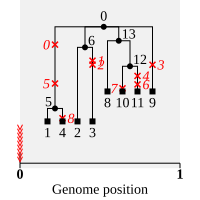

In [206]:
cat_ts.draw_svg()

In [37]:
from collections import defaultdict, deque



def prune_and_regraft_to_keep_ancestral_flexible(
ts,
keep_leaf,
move_leaf,
abundance_key="abundance",
mutation_key="mutation_count",
preserve_branch_lengths_when_possible=True,
shift_mutation_times=True,
epsilon=1e-9,
):
    """
    Prune all branches/subtrees emerging from root -> move_leaf and regraft them
    onto the root -> keep_leaf path, without requiring equal parent times.
    
    Behavior:
    - If parent(move_leaf) is older than parent(keep_leaf), shift the moved subtree
      forward in time by delta = t_move - t_keep to preserve branch lengths.
    - If parent(move_leaf) is younger, simply reattach without shifting times.
    
    Assumes a single-tree genome (edges span the whole interval). Keeps edge metadata.
    """
    tree = ts.first()
    roots = tree.roots if hasattr(tree, "roots") else [tree.root]
    if len(roots) != 1:
        raise ValueError(f"Expected 1 root; found {len(roots)}")
    root = roots[0]
    
    def is_sample(u):
        return (ts.node(u).flags & tskit.NODE_IS_SAMPLE) != 0
    
    # Basic checks: both leaves are samples and “ancestral duplicates”
    for u in (keep_leaf, move_leaf):
        if not is_sample(u):
            raise ValueError("keep_leaf and move_leaf must be sample node IDs")
        md = ts.node(u).metadata
        if not isinstance(md, dict):
            raise ValueError(f"Node {u} metadata must be a dict")
        if md.get(abundance_key, 0) <= 0 or md.get(mutation_key, 0) != 0:
            raise ValueError(f"Node {u} must have abundance>0 and mutation_count==0")
    
    p_keep = tree.parent(keep_leaf)
    p_move = tree.parent(move_leaf)
    if p_keep == tskit.NULL or p_move == tskit.NULL:
        raise ValueError("Both leaves must have a parent")
    if tree.parent(p_keep) != root or tree.parent(p_move) != root:
        raise ValueError("Both leaves must be under root-child internal nodes")
    
    t_keep = ts.node(p_keep).time
    t_move = ts.node(p_move).time
    delta = t_move - t_keep  # >0 means move parent older than keep parent
    
    # Build adjacency from the current edges
    tables = ts.dump_tables()
    children_of = defaultdict(set)
    for e in tables.edges:
        children_of[e.parent].add(e.child)
    
    # Subtrees to move: for each direct child of p_move except move_leaf,
    # move that child and its entire descendant subtree
    roots_to_move = [c for c in children_of[p_move] if c != move_leaf]
    if not roots_to_move:
        return ts  # nothing to move
    
    nodes_to_shift = set()
    if preserve_branch_lengths_when_possible and delta >= 0:
        # Collect all descendants of each root_to_move
        for r in roots_to_move:
            q = deque([r])
            while q:
                u = q.popleft()
                if u in nodes_to_shift:
                    continue
                nodes_to_shift.add(u)
                for v in children_of.get(u, ()):
                    q.append(v)
    
        # Shift node times forward by delta (subtract delta)
        for u in nodes_to_shift:
            tables.nodes.time[u] = tables.nodes.time[u] - delta
        # Optionally shift mutation times for nodes in the moved subtree
        if shift_mutation_times and hasattr(tables.mutations, "time") and len(tables.mutations.time) == tables.mutations.num_rows:
            for mid in range(tables.mutations.num_rows):
                n = tables.mutations.node[mid]
                mt = tables.mutations.time[mid]
                if n in nodes_to_shift and mt is not None:
                    tables.mutations.time[mid] = mt - delta
    
        # Sanity check: after shift, every moved child must be strictly younger than p_keep
        for r in roots_to_move:
            if not (tables.nodes.time[r] < t_keep - epsilon):
                raise ValueError(f"Shifted child {r} (time={tables.nodes.time[r]}) not younger than new parent {p_keep} (time={t_keep})")
    
    # Rebuild edge table: reparent edges with parent==p_move and child in roots_to_move to p_keep
    to_keep_edges = []
    to_add_edges = []
    for e in tables.edges:
        if e.parent == p_move and e.child in roots_to_move:
            # Reattach under p_keep
            to_add_edges.append((e.left, e.right, p_keep, e.child, e.metadata))
        else:
            to_keep_edges.append(e)
    
    tables.edges.clear()
    for e in to_keep_edges:
        tables.edges.add_row(left=e.left, right=e.right, parent=e.parent, child=e.child, metadata=e.metadata)
    for left, right, parent, child, md in to_add_edges:
        # Verify parent>child times (avoid invalid direction)
        if not (tables.nodes.time[parent] > tables.nodes.time[child] + epsilon):
            raise ValueError(f"Invalid parent-child times after reparenting: parent {parent} (time={tables.nodes.time[parent]}) <= child {child} (time={tables.nodes.time[child]})")
        tables.edges.add_row(left=left, right=right, parent=parent, child=child, metadata=md)
    
    tables.sort()
    return( tables.tree_sequence())

def prune_and_regraft_to_keep_ancestral_flexible_and_prune_branch(
ts,
keep_leaf,
move_leaf,
abundance_key="abundance",
mutation_key="mutation_count",
preserve_branch_lengths_when_possible=True,
shift_mutation_times=True,
remove_move_leaf_sample_flag=True,
epsilon=1e-9,
):
    """
    Regraft all subtrees emerging from root -> move_leaf onto the root -> keep_leaf path,
    then remove the entire branch root->move_leaf and add move_leaf's abundance into keep_leaf.
    
    Preconditions:
    - keep_leaf and move_leaf are sample node IDs.
    - Both have metadata dict with abundance_key > 0 and mutation_key == 0.
    - Their parents are direct children of the (single) root of the first tree.
    
    Behavior:
    - If parent(move_leaf) is older than parent(keep_leaf), shift the moved subtree forward
      in time by delta = t_move - t_keep to preserve branch lengths.
    - If parent(move_leaf) is younger, reattach without shifting times.
    - After reattachment, remove the edges root->parent(move_leaf) and parent(move_leaf)->move_leaf.
    - Update keep_leaf metadata: keep_leaf[abundance_key] += move_leaf[abundance_key].
      Optionally clear move_leaf's sample flag so it doesn't appear as a terminal in the tree.
    """
    tree = ts.first()
    roots = tree.roots if hasattr(tree, "roots") else [tree.root]
    if len(roots) != 1:
        raise ValueError(f"Expected 1 root; found {len(roots)}")
    root = roots[0]
    
    def is_sample(u):
        return (ts.node(u).flags & tskit.NODE_IS_SAMPLE) != 0
    
    # Validate leaves and metadata
    for u in (keep_leaf, move_leaf):
        if not is_sample(u):
            raise ValueError("keep_leaf and move_leaf must be sample node IDs")
        md = ts.node(u).metadata
        if not isinstance(md, dict):
            raise ValueError(f"Node {u} metadata must be a dict")
        if md.get(abundance_key, 0) <= 0 or md.get(mutation_key, 0) != 0:
            raise ValueError(f"Node {u} must have {abundance_key}>0 and {mutation_key}==0")
    
    p_keep = tree.parent(keep_leaf)
    p_move = tree.parent(move_leaf)
    if p_keep == tskit.NULL or p_move == tskit.NULL:
        raise ValueError("Both leaves must have a parent")
    if tree.parent(p_keep) != root or tree.parent(p_move) != root:
        raise ValueError("Both leaves must be under root-child internal nodes")
    
    t_keep = ts.node(p_keep).time
    t_move = ts.node(p_move).time
    delta = t_move - t_keep  # >0 means p_move older than p_keep
    
    tables = ts.dump_tables()
    
    # Build children map from current edges
    children_of = defaultdict(set)
    for e in tables.edges:
        children_of[e.parent].add(e.child)
    
    # Roots of subtrees to move: all children of p_move except move_leaf
    roots_to_move = [c for c in children_of[p_move] if c != move_leaf]
    
    # Optionally shift times for all nodes in moved subtrees
    nodes_to_shift = set()
    if preserve_branch_lengths_when_possible and delta >= 0 and roots_to_move:
        for r in roots_to_move:
            q = deque([r])
            while q:
                u = q.popleft()
                if u in nodes_to_shift:
                    continue
                nodes_to_shift.add(u)
                for v in children_of.get(u, ()):
                    q.append(v)
        # Shift node times forward by delta (subtract delta)
        for u in nodes_to_shift:
            tables.nodes.time[u] = tables.nodes.time[u] - delta
        # Shift mutation times (if available) for nodes in the moved subtree
        if shift_mutation_times and hasattr(tables.mutations, "time") and len(tables.mutations.time) == tables.mutations.num_rows:
            for mid in range(tables.mutations.num_rows):
                n = tables.mutations.node[mid]
                mt = tables.mutations.time[mid]
                if n in nodes_to_shift and mt is not None:
                    tables.mutations.time[mid] = mt - delta
        # Ensure each moved child is strictly younger than new parent p_keep
        for r in roots_to_move:
            if not (tables.nodes.time[r] < t_keep - epsilon):
                raise ValueError(f"Shifted child {r} (time={tables.nodes.time[r]}) not younger than new parent {p_keep} (time={t_keep})")
    
    # Rebuild edge table: reparent edges (p_move -> child) for child in roots_to_move to p_keep,
    # and drop the edges on the to-be-removed path: (root -> p_move) and (p_move -> move_leaf).
    to_add_edges = []
    new_edges = []
    for e in tables.edges:
        if e.parent == p_move and e.child in roots_to_move:
            # Reattach under p_keep
            to_add_edges.append((e.left, e.right, p_keep, e.child, e.metadata))
            continue
        # Drop the path edges we want to remove:
        if (e.parent == root and e.child == p_move) or (e.parent == p_move and e.child == move_leaf):
            continue
        # Keep all other edges
        new_edges.append(e)
    
    tables.edges.clear()
    for e in new_edges:
        tables.edges.add_row(left=e.left, right=e.right, parent=e.parent, child=e.child, metadata=e.metadata)
    for left, right, parent, child, md in to_add_edges:
        # Ensure parent>child times
        if not (tables.nodes.time[parent] > tables.nodes.time[child] + epsilon):
            raise ValueError(
                f"Invalid parent-child times after reparenting: parent {parent} (time={tables.nodes.time[parent]}) "
                f"<= child {child} (time={tables.nodes.time[child]})"
            )
        tables.edges.add_row(left=left, right=right, parent=parent, child=child, metadata=md)
    
    # Update keep_leaf abundance by adding move_leaf abundance
    keep_md = tables.nodes.metadata[keep_leaf]
    move_md = tables.nodes.metadata[move_leaf]
    # Ensure dicts
    keep_md = dict(keep_md) if isinstance(keep_md, dict) else {}
    move_md = dict(move_md) if isinstance(move_md, dict) else {}
    
    k_ab = keep_md.get(abundance_key, 0)
    m_ab = move_md.get(abundance_key, 0)
    try:
        k_ab = float(k_ab)
    except Exception:
        k_ab = 0.0
    try:
        m_ab = float(m_ab)
    except Exception:
        m_ab = 0.0
    keep_md[abundance_key] = k_ab + m_ab
    # Optionally record provenance
    merged_from = list(keep_md.get("merged_from", []))
    merged_from.append(int(move_leaf))
    keep_md["merged_from"] = merged_from
    tables.nodes.set_metadata(keep_leaf, keep_md)
    
    # Optionally clear move_leaf sample flag so it no longer appears as a terminal
    if remove_move_leaf_sample_flag:
        tables.nodes.flags[move_leaf] = tables.nodes.flags[move_leaf] & ~tskit.NODE_IS_SAMPLE
    
    tables.sort()
    return( tables.tree_sequence())

def prune_and_regraft_to_keep_ancestral_merge_and_prune(
ts,
keep_leaf,
move_leaf,
abundance_key="abundance",
mutation_key="mutation_count",
preserve_branch_lengths_when_possible=True,
shift_mutation_times=True,
remove_move_leaf_sample_flag=True,
epsilon=1e-9,
):
    """
    Regraft all subtrees from root -> move_leaf to root -> keep_leaf, remove the branch
    root->p_move and p_move->move_leaf, and add move_leaf's abundance to keep_leaf.
    
    Assumes:
    - A single tree across the sequence.
    - Your JSON metadata schemas are set on nodes, edges, mutations, and sites.
    - Nodes keep_leaf and move_leaf are samples with mutation_count == 0 and abundance > 0.
    """
    tree = ts.first()
    roots = tree.roots if hasattr(tree, "roots") else [tree.root]
    if len(roots) != 1:
        raise ValueError(f"Expected 1 root; found {len(roots)}")
    root = roots[0]
    
    def is_sample(u):
        return((ts.node(u).flags & tskit.NODE_IS_SAMPLE) != 0)
    
    # Validate leaves and their metadata per node schema
    for u in (keep_leaf, move_leaf):
        if not is_sample(u):
            raise ValueError("keep_leaf and move_leaf must be sample node IDs")
        md = ts.node(u).metadata or {}
        if md.get(abundance_key, 0) <= 0 or md.get(mutation_key, 0) != 0:
            raise ValueError(f"Node {u} must have {abundance_key} > 0 and {mutation_key} == 0")
    
    p_keep = tree.parent(keep_leaf)
    p_move = tree.parent(move_leaf)
    if p_keep == tskit.NULL or p_move == tskit.NULL:
        raise ValueError("Both leaves must have a parent")
    if tree.parent(p_keep) != root or tree.parent(p_move) != root:
        raise ValueError("Both leaves must be under root-child internal nodes")
    
    t_keep = ts.node(p_keep).time
    t_move = ts.node(p_move).time
    delta = t_move - t_keep  # >0 means p_move is older than p_keep
    
    tables = ts.dump_tables()
    
    # Build children map
    children_of = defaultdict(set)
    for e in tables.edges:
        children_of[e.parent].add(e.child)
    
    # Subtree roots to move: all children of p_move except move_leaf
    roots_to_move = [c for c in children_of[p_move] if c != move_leaf]
    
    # Optionally shift times for all nodes in moved subtrees (preserve branch lengths if p_move older)
    nodes_to_shift = set()
    if preserve_branch_lengths_when_possible and delta >= 0 and roots_to_move:
        for r in roots_to_move:
            q = deque([r])
            while q:
                u = q.popleft()
                if u in nodes_to_shift:
                    continue
                nodes_to_shift.add(u)
                for v in children_of.get(u, ()):
                    q.append(v)
        # Shift node times forward by delta (subtract delta)
        for u in nodes_to_shift:
            tables.nodes.time[u] = tables.nodes.time[u] - delta
        # Optionally shift mutation times for nodes in the moved subtree
        if shift_mutation_times and tables.mutations.num_rows > 0:
            for mid in range(tables.mutations.num_rows):
                n = tables.mutations.node[mid]
                if n in nodes_to_shift:
                    mt = tables.mutations.time[mid]
                    if mt is not None and not (isinstance(mt, float) and math.isnan(mt)):
                        tables.mutations.time[mid] = mt - delta
        # Ensure each moved child is strictly younger than new parent p_keep
        for r in roots_to_move:
            if not (tables.nodes.time[r] < t_keep - epsilon):
                raise ValueError(
                    f"Shifted child {r} (time={tables.nodes.time[r]}) not younger than new parent {p_keep} (time={t_keep})"
                )
    
    # Rebuild edge table:
    # - reparent (p_move -> child) for child in roots_to_move to p_keep
    # - drop (root -> p_move) and (p_move -> move_leaf)
    to_add_edges = []
    kept_edges = []
    for e in tables.edges:
        if e.parent == p_move and e.child in roots_to_move:
            to_add_edges.append((e.left, e.right, p_keep, e.child, e.metadata))
            continue
        if (e.parent == root and e.child == p_move) or (e.parent == p_move and e.child == move_leaf):
            continue
        kept_edges.append(e)
    
    tables.edges.clear()
    for e in kept_edges:
        tables.edges.add_row(left=e.left, right=e.right, parent=e.parent, child=e.child, metadata=e.metadata)
    for left, right, parent, child, md in to_add_edges:
        # Validate parent>child times
        if not (tables.nodes.time[parent] > tables.nodes.time[child] + epsilon):
            raise ValueError(
                f"Invalid parent-child times after reparenting: parent {parent} (time={tables.nodes.time[parent]}) "
                f"<= child {child} (time={tables.nodes.time[child]})"
            )
        tables.edges.add_row(left=left, right=right, parent=parent, child=child, metadata=md)
    
    # Compute updated metadata dict for keep_leaf (sum abundance as integer)
    keep_md = dict(ts.node(keep_leaf).metadata or {})
    move_md = dict(ts.node(move_leaf).metadata or {})
    try:
        k_ab = int(keep_md.get(abundance_key, 0))
    except Exception:
        k_ab = 0
    try:
        m_ab = int(move_md.get(abundance_key, 0))
    except Exception:
        m_ab = 0
    keep_md[abundance_key] = k_ab + m_ab
    print(' keep_md', keep_md)
    
    # Prepare columns for rebuilding nodes without manual metadata buffers
    flags = tables.nodes.flags.copy()
    times = tables.nodes.time.copy()
    pops = tables.nodes.population.copy()
    indivs = tables.nodes.individual.copy()
    schema = tables.nodes.metadata_schema
    
    # Optionally clear move_leaf sample flag
    if remove_move_leaf_sample_flag:
        flags[move_leaf] = flags[move_leaf] & int(not tskit.NODE_IS_SAMPLE)
    
    # Rebuild the node table row-by-row using encoded dicts, avoiding metadata_offset handling
    original_num_rows = tables.nodes.num_rows
    # Keep a reference to per-node metadata dicts from the original ts
    # (these are fine to reuse since we only changed times/flags)
    tables.nodes.clear()
    # Ensure schema remains set
    tables.nodes.metadata_schema = schema
    
    for i in range(original_num_rows):
        if i == keep_leaf:
            md_dict = keep_md
        else:
            md_dict = ts.node(i).metadata
        tables.nodes.add_row(
            flags=flags[i],
            time=times[i],
            population=pops[i],
            individual=indivs[i],
            metadata=md_dict,
        )
    
    tables.sort()
    return( tables.tree_sequence())

ancestrals=[i for i in range(len(cat_ts.tables.nodes)) if (cat_ts.tables.nodes[i].flags==1) and (cat_ts.tables.nodes[i].metadata['mutation_count']==0)]
print(ancestrals)

cat_merged_ts=prune_and_regraft_to_keep_ancestral_merge_and_prune(cat_ts, ancestrals[0], ancestrals[1],
abundance_key="abundance",
mutation_key="mutation_count")

cat_merged_ts.draw_svg()

KeyError: 'mutation_count'

In [213]:
md=cat_merged_ts.node(0).metadata
md.get('abundance', 0)

0

In [207]:
df=NoteTable_to_pandasDF(cat_merged_ts.tables.nodes)
df

,id,flags,time,population,individual,abundance,fitness,mutation_count
0,0,0,1.972301,-1,-1,0,1.000000,0
1,1,1,0.000000,-1,-1,5,0.907298,2
2,2,1,0.000000,-1,-1,3,1.000000,0
3,3,1,0.000000,-1,-1,1,0.885792,2
4,4,1,0.000000,-1,-1,1,0.831762,3
5,5,0,0.269881,-1,-1,0,0.907298,2
6,6,0,1.543705,-1,-1,0,1.000000,0
7,7,0,1.972301,-1,-1,0,1.000000,0
8,8,1,0.624330,-1,-1,5,1.000000,0
9,9,1,0.624330,-1,-1,1,0.739990,1


### Manual encoding

In [564]:
###### backup

import tskit
import numpy as np
import json

def prune_unique_genotypes_add_metadata(ts, s_mean=-0.1, s_std=0.1, baseline=1.0, seed=None):
    """
    Returns a new TreeSequence pruned to one sample per unique genotype and annotated with:
    - mutation metadata: {"s": float} with s ~ Normal(s_mean, s_std)
    - node metadata: {"fitness": float, "abundance": int}
    - edge metadata: {"distance": int} = number of mutations on that branch
    Assumes haploid samples. Handles SLiMMutationModel stacking at each site.
    """
    rng = np.random.default_rng(seed)
    

    # 1) Annotate mutations with {"s": ...} as raw JSON bytes
    tables = ts.dump_tables()
    muts = tables.mutations
    n_muts = muts.num_rows
    if n_muts > 0:
        s_vals = rng.normal(loc=s_mean, scale=s_std, size=n_muts)
        original_muts = list(ts.mutations())
        muts.clear()
        # tskit 1.0.0 does not have mutation time; guard in case
        has_time = hasattr(original_muts[0], "time")
        for i, m in enumerate(original_muts):
            md = json.dumps({"s": float(s_vals[i])}).encode("utf-8")
            if has_time:
                muts.add_row(site=m.site, node=m.node, derived_state=m.derived_state,
                             parent=m.parent, time=m.time, metadata=md)
            else:
                muts.add_row(site=m.site, node=m.node, derived_state=m.derived_state,
                             parent=m.parent, metadata=md)
    ts_s = tables.tree_sequence()
    
    # 2) Group haploid samples by unique multilocus genotype
    samples = ts_s.samples()
    num_samples = len(samples)
    # Stream genotypes per site to avoid full matrix
    genotype_components = [[] for _ in range(num_samples)]
    for var in ts_s.variants():
        g = var.genotypes
        for i in range(num_samples):
            genotype_components[i].append(int(g[i]))
    genotype_groups = {}
    for i in range(num_samples):
        key = tuple(genotype_components[i])  # empty tuple if no sites
        genotype_groups.setdefault(key, []).append(i)
    
    # Pick one representative per group; abundance = group size
    rep_indices = []
    abundance_by_rep_node = {}
    for idxs in genotype_groups.values():
        rep_i = min(idxs, key=lambda j: samples[j])  # stable representative choice
        rep_indices.append(rep_i)
        abundance_by_rep_node[samples[rep_i]] = len(idxs)

    rep_nodes = [samples[i] for i in rep_indices]
    
    # 3) Pre-annotate abundance for representative nodes in tables, then simplify
    nt = tables.nodes
    num_nodes = nt.num_rows
    flags = nt.flags
    time = nt.time
    population = nt.population
    individual = getattr(nt, "individual", np.full(num_nodes, tskit.NULL, dtype=np.int32))
    # Rebuild node table with abundance metadata
    nt.clear()
    for nid in range(num_nodes):
        md = json.dumps({"abundance": int(abundance_by_rep_node.get(nid, 0))}).encode("utf-8")
        nt.add_row(flags=flags[nid], time=time[nid], population=population[nid],
                   individual=individual[nid], metadata=md)
    
    ts_pruned = tables.tree_sequence().simplify(samples=rep_nodes, keep_unary=False, filter_sites=False)
    
    # 4) Compute per-node fitness on pruned TS:
    def _s_from_md(b):
        if not b:
            return( 0.0)
        try:
            return( float(json.loads(b.decode("utf-8")).get("s", 0.0)))
        except Exception:
            return( 0.0)
    
    node_s_accum = np.zeros(ts_pruned.num_nodes, dtype=float)
    
    for site in ts_pruned.sites():
        muts = list(site.mutations)
        if not muts:
            continue
    tree = ts_pruned.at(site.position)
    roots = tree.roots if hasattr(tree, "roots") else ([tree.root] if tree.root != tskit.NULL else [])
    root_set = set(roots)
    
    # Sum s per edge: attribute s to the child node where the mutation is placed
    edge_effect = np.zeros(ts_pruned.num_nodes, dtype=float)
    for m in muts:
        # Skip mutations on roots so the root fitness stays at baseline
        if m.node not in root_set:
            edge_effect[m.node] += _s_from_md(m.metadata)
    
    # Propagate from roots to tips, adding edge effects along each path
    for r in roots:
        stack = [(r, 0.0)]  # contrib at root starts at 0 (root stays at baseline)
        while stack:
            u, contrib = stack.pop()
            node_s_accum[u] += contrib
            for v in tree.children(u):
                stack.append((v, contrib + edge_effect[v]))   

    node_fitness = baseline + node_s_accum

    # 5) Read abundance preserved on pruned nodes, then write final node metadata {"fitness", "abundance"}

    tables2 = ts_pruned.dump_tables()
    nt2 = tables2.nodes
    num_nodes2 = nt2.num_rows
    flags2 = nt2.flags
    time2 = nt2.time
    population2 = nt2.population
    individual2 = getattr(nt2, "individual", np.full(num_nodes2, tskit.NULL, dtype=np.int32))
    offs = nt2.metadata_offset
    meta = nt2.metadata
    abundance = np.zeros(nt2.num_rows, dtype=np.int64)
        
    for nid in range(nt2.num_rows):
        row = bytes(meta[offs[nid]:offs[nid + 1]])
        md = json.loads(row.decode("utf-8")) if row else {}
        abundance[nid] = int(md.get("abundance", 0))

    # Rebuild node table with final metadata
    nt2.clear()
    for nid in range(num_nodes2):
        md = json.dumps({"fitness": float(node_fitness[nid]), "abundance": int(abundance[nid])}).encode("utf-8")
        nt2.add_row(flags=flags2[nid], time=time2[nid], population=population2[nid],
                    individual=individual2[nid], metadata=md)
    
    # 6) Edge metadata: {"distance": number of mutations on that branch within [left, right)}
    et = tables2.edges
    num_edges = et.num_rows
    left = et.left
    right = et.right
    parent = et.parent
    child = et.child
    
    edge_md_bytes = [b""] * num_edges
    if num_edges > 0 and tables2.mutations.num_rows > 0:
        m_nodes = tables2.mutations.node
        m_sites = tables2.mutations.site
        site_pos = tables2.sites.position
        m_pos = site_pos[m_sites]
    
        order = np.lexsort((m_pos, m_nodes))
        nodes_sorted = m_nodes[order]
        pos_sorted = m_pos[order]
    
        unique_nodes, starts, counts = np.unique(nodes_sorted, return_index=True, return_counts=True)
        nrange_start = np.full(tables2.nodes.num_rows, -1, dtype=np.int64)
        nrange_count = np.zeros(tables2.nodes.num_rows, dtype=np.int64)
        nrange_start[unique_nodes] = starts
        nrange_count[unique_nodes] = counts
    
        for i in range(num_edges):
            c = child[i]
            s = nrange_start[c]
            cnt = 0
            if s >= 0:
                seg = pos_sorted[s : s + nrange_count[c]]
                lo = np.searchsorted(seg, left[i], side="left")
                hi = np.searchsorted(seg, right[i], side="left")
                cnt = int(hi - lo)
            edge_md_bytes[i] = json.dumps({"distance": cnt}).encode("utf-8")
    else:
        for i in range(num_edges):
            edge_md_bytes[i] = json.dumps({"distance": 0}).encode("utf-8")
    
    # Rebuild edge table with metadata
    orig_left = np.array(left, copy=True)
    orig_right = np.array(right, copy=True)
    orig_parent = np.array(parent, copy=True)
    orig_child = np.array(child, copy=True)
    
    et.clear()
    for i in range(num_edges):
        et.add_row(left=orig_left[i], right=orig_right[i], parent=orig_parent[i],
                   child=orig_child[i], metadata=edge_md_bytes[i])
    
    return(tables2.tree_sequence())


mts_unique=prune_unique_genotypes_add_metadata(mts,seed=666)

ml = {m.id: m.derived_state for m in mts_unique.mutations()}
mts_unique.draw_svg(mutation_labels=ml)

mts_unique.tables.mutations

id,site,node,time,derived_state,parent,metadata
0,0,4,1.60077480,0,-1,"b'{""s"": -0.09474715305816742}'"
1,0,2,1.26577118,1,-1,"b'{""s"": -0.059145214012207556}'"
2,0,2,1.18412099,"1,2",1,"b'{""s"": -0.11914929655688716}'"
3,0,4,0.79008194,"0,3",0,"b'{""s"": -0.33416310306690944}'"
4,0,3,0.06594344,"0,3,4",3,"b'{""s"": 0.1221142167077863}'"


In [508]:
mts_unique.tables.mutations

id,site,node,time,derived_state,parent,metadata
0,0,4,1.60077480,0,-1,"b'{""s"": -0.09474715305816742}'"
1,0,2,1.26577118,1,-1,"b'{""s"": -0.059145214012207556}'"
2,0,2,1.18412099,"1,2",1,"b'{""s"": -0.11914929655688716}'"
3,0,4,0.79008194,"0,3",0,"b'{""s"": -0.33416310306690944}'"
4,0,3,0.06594344,"0,3,4",3,"b'{""s"": 0.1221142167077863}'"


In [509]:
mts_unique.tables.nodes

id,time,flags,population,individual,metadata
0,0.00000000,1,0,0,"b'{""fitness"": 0.5710897438749232, ""ab..."
1,0.00000000,1,0,0,"b'{""fitness"": 1.0, ""abundance"": 3}'"
2,0.00000000,1,0,1,"b'{""fitness"": 0.8217054894309053, ""ab..."
3,0.00000000,1,0,2,"b'{""fitness"": 0.6932039605827095, ""ab..."
4,0.26988078,0,0,-1,"b'{""fitness"": 0.5710897438749232, ""ab..."
5,1.54370518,0,0,-1,"b'{""fitness"": 1.0, ""abundance"": 0}'"
6,1.97230077,0,0,-1,"b'{""fitness"": 1.0, ""abundance"": 0}'"


In [510]:
mts_unique.tables.edges

id,left,right,parent,child,metadata
0,0,1,4,0,"b'{""distance"": 0}'"
1,0,1,4,3,"b'{""distance"": 1}'"
2,0,1,5,1,"b'{""distance"": 0}'"
3,0,1,5,2,"b'{""distance"": 2}'"
4,0,1,6,4,"b'{""distance"": 2}'"
5,0,1,6,5,"b'{""distance"": 0}'"


In [535]:
mts_unique

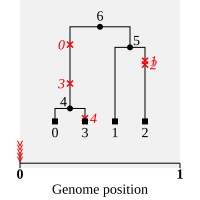

In [38]:
mts_unique.draw_svg()

In [562]:
## read from metadata

def get_metadata_from_bytes(nid,metadata="abundance",source=ts.tables.nodes):
    offs = source.metadata_offset
    meta = source.metadata
        
    row = bytes(meta[offs[nid]:offs[nid + 1]])
    md = json.loads(row.decode("utf-8")) if row else {}
    return(md.get(metadata, 0))

print([get_metadata_from_bytes(nid,metadata="fitness",source=mts_unique.tables.nodes) for nid in range(len(mts_unique.tables.nodes))])
print([get_metadata_from_bytes(nid,metadata="distance",source=mts_unique.tables.edges) for nid in range(len(mts_unique.tables.edges))])

mts_unique.tables.nodes
########


for row in mts_unique.tables.nodes:
    print(row.metadata.decode("utf-8")['fitness'])
## merge graphs

## 

[0.5710897438749232, 1.0, 0.8217054894309053, 0.6932039605827095, 0.5710897438749232, 1.0, 1.0]
[0, 1, 0, 2, 2, 0]


TypeError: string indices must be integers, not 'str'

In [57]:
mts1_unique.draw_svg()
print(mts1_unique.draw_text())

1.97┊    6    ┊
    ┊  ┏━┻━┓  ┊
1.54┊  ┃   5  ┊
    ┊  ┃  ┏┻┓ ┊
0.27┊  4  ┃ ┃ ┊
    ┊ ┏┻┓ ┃ ┃ ┊
0.00┊ 0 3 1 2 ┊
    0         1



In [58]:
mts2_unique.draw_svg()
print(mts2_unique.draw_text())

1.35┊     6   ┊
    ┊   ┏━┻━┓ ┊
1.06┊   5   ┃ ┊
    ┊ ┏━┻┓  ┃ ┊
0.53┊ ┃  4  ┃ ┊
    ┊ ┃ ┏┻┓ ┃ ┊
0.00┊ 0 2 3 1 ┊
    0         1



In [55]:
from project_package.tskit_functions import prune_unique_genotypes_add_metadata,merge_by_root_and_combine_ancestrals,NodeTable_to_pandasDF,cell_coalescent_tree_with_mutations,tstree_to_networkx_graph

# cat_ts,node_labels=merge_by_root_and_combine_ancestrals([mts1_unique,,mts2_unique])                                                                           
# cat_ts.draw_svg(size=(500,500))

mts_unique_list=[mts1_unique,mts2_unique]

merge_by_root_and_combine_ancestrals(mts_unique_list)

1.97┊         0         ┊
    ┊  ┏━━━┳━━┻━┳━━━━━┓ ┊
1.68┊  ┃   ┃   13     ┃ ┊
    ┊  ┃   ┃  ┏━┻━┓   ┃ ┊
1.54┊  ┃   6  ┃   ┃   ┃ ┊
    ┊  ┃  ┏┻┓ ┃   ┃   ┃ ┊
1.15┊  ┃  ┃ ┃ ┃  12   ┃ ┊
    ┊  ┃  ┃ ┃ ┃  ┏┻━┓ ┃ ┊
0.62┊  ┃  ┃ ┃ 8 10 11 9 ┊
    ┊  ┃  ┃ ┃           ┊
0.27┊  5  ┃ ┃           ┊
    ┊ ┏┻┓ ┃ ┃           ┊
0.00┊ 1 4 2 3           ┊
    0                   1



ValueError: move_leaf 10 must be under the root or under a node whose parent is the root

{(np.int32(4), np.int32(0)): {'distance': 0}, (np.int32(4), np.int32(3)): {'distance': 1}, (np.int32(5), np.int32(1)): {'distance': 0}, (np.int32(5), np.int32(2)): {'distance': 2}, (np.int32(6), np.int32(4)): {'distance': 2}, (np.int32(6), np.int32(5)): {'distance': 0}}


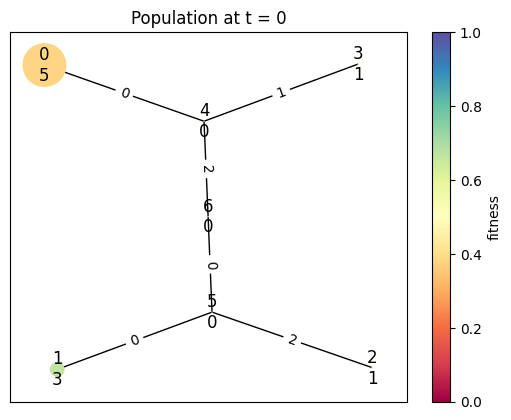

In [520]:
def to_networkx_graph(ts):
    nodes = ts.tables.nodes
    edges=ts.tables.edges
    num_nodes = nodes.num_rows
    num_edges = edges.num_rows
    
    offs_edges = edges.metadata_offset
    meta_edges = edges.metadata
    
    offs_nodes = nodes.metadata_offset
    meta_nodes = nodes.metadata

    print({tuple(zip(edges.parent,edges.child))[nid]:json.loads(bytes(meta_edges[offs_edges[nid]:offs_edges[nid + 1]]).decode("utf-8")) for nid in range(num_edges)})
    G = nx.from_pandas_edgelist(
        pd.DataFrame({'source': edges.parent, 'target': edges.child, 'left': edges.left, 'right': edges.right}),
        edge_attr=None
        # create_using=nx.MultiDiGraph
    )
    nx.set_edge_attributes(G, {tuple(zip(edges.parent,edges.child))[nid]:json.loads(bytes(meta_edges[offs_edges[nid]:offs_edges[nid + 1]]).decode("utf-8")) for nid in range(num_edges)})
    nx.set_node_attributes(G, {nid: json.loads(bytes(meta_nodes[offs_nodes[nid]:offs_nodes[nid + 1]]).decode("utf-8")) for nid in range(num_nodes)})
    return G

G = to_networkx_graph(mts_unique)
from project_package.simplify import remove_empty_leaves_and_rescale_edges

visualize_pop(G,show_empty=True)

In [532]:
def remove_empty_edges_and_merge_nodes(G):

    '''
    This function simplify the haplotype network by collapsing nodes around an empty edge (edges with genetic distance=0.
    '''
    newG=G.copy()
    
    ## find empty edges
    
    edges_to_remove = [(node_1,node_2) for node_1,node_2,attr in G.edges(data=True) if attr['distance']==0]
    # edges_to_remove = G.edges(nodes_to_remove)
    print(edges_to_remove)
    
    newG.remove_nodes_from(nodes_to_remove)
    newG.remove_edges_from(edges_to_remove)
    
    ## find and collapse chain of edges between empty nodes
    
    nodes_to_remove = [node for node,attr in newG.nodes(data=True) if attr['abundance']==0 and newG.degree(node)==2]
    edges_to_remove = []
    new_edges_with_weights =[]
    
    subgraphs=[newG.subgraph(c).copy() for c in nx.connected_components(newG.subgraph(nodes_to_remove))]

    for sg in subgraphs:
        old_edges=newG.edges(sg.nodes())
        edges_to_remove+=old_edges
        
        new_edge=[node for node in np.array(list(old_edges)).flatten() if node not in sg.nodes()]
        new_edges_with_weights+=[[new_edge[0],new_edge[1],{'distance':nx.shortest_path_length(newG, source=new_edge[0], target=new_edge[1], weight='distance')}]]

    newG.remove_nodes_from(nodes_to_remove)
    newG.remove_edges_from(edges_to_remove)
    newG.add_edges_from(new_edges_with_weights)
    
    return(newG)


# G = to_networkx_graph(mts_unique)
newG=remove_empty_edges_and_merge_nodes(G)
visualize_pop(newG)

[]


UnboundLocalError: cannot access local variable 'nodes_to_remove' where it is not associated with a value

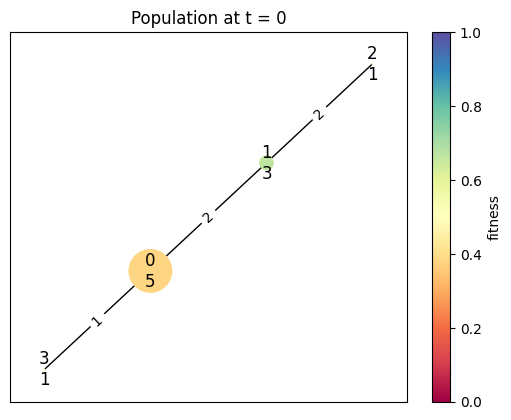

In [534]:
newG=G.copy()
edges_to_remove = [(node_1,node_2) for node_1,node_2,attr in G.edges(data=True) if attr['distance']==0]
newG.remove_edges_from(edges_to_remove)

visualize_pop(newG,show_empty=True)

[(4, 0), (5, 1), (5, 6)]
(5, 6)
(5, 1)
(4, 0)


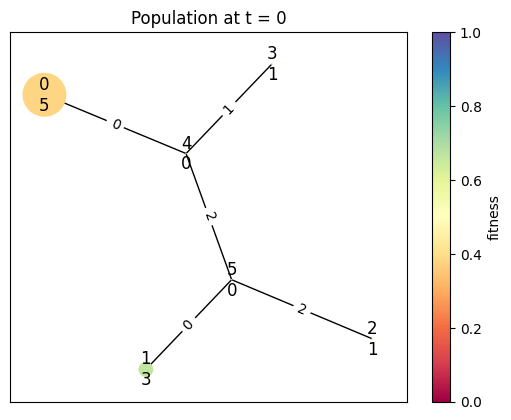

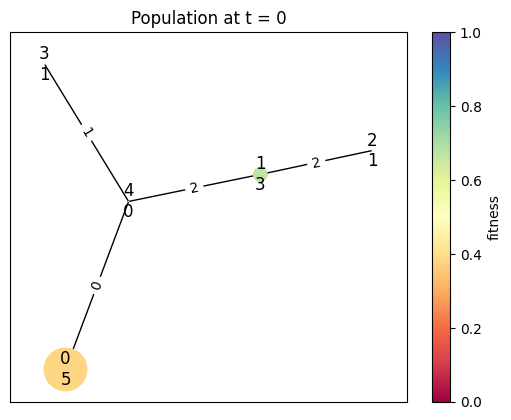

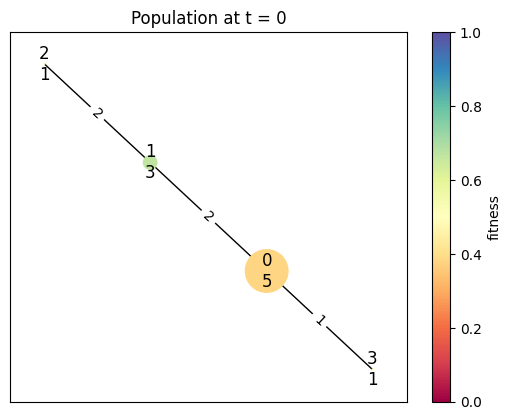

In [531]:
G.edges(data=True)
edges_to_remove = [(node_1,node_2) for node_1,node_2,attr in G.edges(data=True) if attr['distance']==0]
print(edges_to_remove)
while len(edges_to_remove)>0:
    edge=edges_to_remove.pop()
    print(edge)
    node1=sorted(edge)[0]
    node2=sorted(edge)[1]
    plt.figure()
    G=nx.contracted_nodes(G, node1, node2,self_loops=False)
    visualize_pop(G)

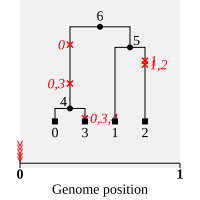

In [506]:
###### backup

import tskit
import numpy as np
import json

def prune_unique_genotypes_add_metadata(ts, s_mean=-0.1, s_std=0.1, baseline=1.0, seed=None):
    """
    Returns a new TreeSequence pruned to one sample per unique genotype and annotated with:
    - mutation metadata: {"s": float} with s ~ Normal(s_mean, s_std)
    - node metadata: {"fitness": float, "abundance": int}
    - edge metadata: {"distance": int} = number of mutations on that branch
    Assumes haploid samples. Handles SLiMMutationModel stacking at each site.
    """
    rng = np.random.default_rng(seed)

    # 1) Annotate mutations with {"s": ...} as raw JSON bytes
    tables = ts.dump_tables()
    muts = tables.mutations
    n_muts = muts.num_rows
    if n_muts > 0:
        s_vals = rng.normal(loc=s_mean, scale=s_std, size=n_muts)
        original_muts = list(ts.mutations())
        muts.clear()
        # tskit 1.0.0 does not have mutation time; guard in case
        has_time = hasattr(original_muts[0], "time")
        for i, m in enumerate(original_muts):
            md = json.dumps({"s": float(s_vals[i])}).encode("utf-8")
            if has_time:
                muts.add_row(site=m.site, node=m.node, derived_state=m.derived_state,
                             parent=m.parent, time=m.time, metadata=md)
            else:
                muts.add_row(site=m.site, node=m.node, derived_state=m.derived_state,
                             parent=m.parent, metadata=md)
    ts_s = tables.tree_sequence()
    
    # 2) Group haploid samples by unique multilocus genotype
    samples = ts_s.samples()
    num_samples = len(samples)
    # Stream genotypes per site to avoid full matrix
    genotype_components = [[] for _ in range(num_samples)]
    for var in ts_s.variants():
        g = var.genotypes
        for i in range(num_samples):
            genotype_components[i].append(int(g[i]))
    genotype_groups = {}
    for i in range(num_samples):
        key = tuple(genotype_components[i])  # empty tuple if no sites
        genotype_groups.setdefault(key, []).append(i)
    
    # Pick one representative per group; abundance = group size
    rep_indices = []
    abundance_by_rep_node = {}
    for idxs in genotype_groups.values():
        rep_i = min(idxs, key=lambda j: samples[j])  # stable representative choice
        rep_indices.append(rep_i)
        abundance_by_rep_node[samples[rep_i]] = len(idxs)

    rep_nodes = [samples[i] for i in rep_indices]
    
    # 3) Pre-annotate abundance for representative nodes in tables, then simplify
    nt = tables.nodes
    num_nodes = nt.num_rows
    flags = nt.flags
    time = nt.time
    population = nt.population
    individual = getattr(nt, "individual", np.full(num_nodes, tskit.NULL, dtype=np.int32))
    # Rebuild node table with abundance metadata
    nt.clear()
    for nid in range(num_nodes):
        md = json.dumps({"abundance": int(abundance_by_rep_node.get(nid, 0))}).encode("utf-8")
        nt.add_row(flags=flags[nid], time=time[nid], population=population[nid],
                   individual=individual[nid], metadata=md)
    
    ts_pruned = tables.tree_sequence().simplify(samples=rep_nodes, keep_unary=False, filter_sites=False)
    
    # 4) Compute per-node fitness on pruned TS:
    def _s_from_md(b):
        if not b:
            return( 0.0)
        try:
            return( float(json.loads(b.decode("utf-8")).get("s", 0.0)))
        except Exception:
            return( 0.0)
    
    node_s_accum = np.zeros(ts_pruned.num_nodes, dtype=float)
    
    for site in ts_pruned.sites():
        muts = list(site.mutations)
        if not muts:
            continue
    tree = ts_pruned.at(site.position)
    roots = tree.roots if hasattr(tree, "roots") else ([tree.root] if tree.root != tskit.NULL else [])
    root_set = set(roots)
    
    # Sum s per edge: attribute s to the child node where the mutation is placed
    edge_effect = np.zeros(ts_pruned.num_nodes, dtype=float)
    for m in muts:
        # Skip mutations on roots so the root fitness stays at baseline
        if m.node not in root_set:
            edge_effect[m.node] += _s_from_md(m.metadata)
    
    # Propagate from roots to tips, adding edge effects along each path
    for r in roots:
        stack = [(r, 0.0)]  # contrib at root starts at 0 (root stays at baseline)
        while stack:
            u, contrib = stack.pop()
            node_s_accum[u] += contrib
            for v in tree.children(u):
                stack.append((v, contrib + edge_effect[v]))   

    node_fitness = baseline + node_s_accum

    # 5) Read abundance preserved on pruned nodes, then write final node metadata {"fitness", "abundance"}

    tables2 = ts_pruned.dump_tables()
    nt2 = tables2.nodes
    num_nodes2 = nt2.num_rows
    flags2 = nt2.flags
    time2 = nt2.time
    population2 = nt2.population
    individual2 = getattr(nt2, "individual", np.full(num_nodes2, tskit.NULL, dtype=np.int32))
    offs = nt2.metadata_offset
    meta = nt2.metadata
    abundance = np.zeros(nt2.num_rows, dtype=np.int64)
        
    for nid in range(nt2.num_rows):
        row = bytes(meta[offs[nid]:offs[nid + 1]])
        md = json.loads(row.decode("utf-8")) if row else {}
        abundance[nid] = int(md.get("abundance", 0))

    # Rebuild node table with final metadata
    nt2.clear()
    for nid in range(num_nodes2):
        md = json.dumps({"fitness": float(node_fitness[nid]), "abundance": int(abundance[nid])}).encode("utf-8")
        nt2.add_row(flags=flags2[nid], time=time2[nid], population=population2[nid],
                    individual=individual2[nid], metadata=md)
    
    # 6) Edge metadata: {"distance": number of mutations on that branch within [left, right)}
    et = tables2.edges
    num_edges = et.num_rows
    left = et.left
    right = et.right
    parent = et.parent
    child = et.child
    
    edge_md_bytes = [b""] * num_edges
    if num_edges > 0 and tables2.mutations.num_rows > 0:
        m_nodes = tables2.mutations.node
        m_sites = tables2.mutations.site
        site_pos = tables2.sites.position
        m_pos = site_pos[m_sites]
    
        order = np.lexsort((m_pos, m_nodes))
        nodes_sorted = m_nodes[order]
        pos_sorted = m_pos[order]
    
        unique_nodes, starts, counts = np.unique(nodes_sorted, return_index=True, return_counts=True)
        nrange_start = np.full(tables2.nodes.num_rows, -1, dtype=np.int64)
        nrange_count = np.zeros(tables2.nodes.num_rows, dtype=np.int64)
        nrange_start[unique_nodes] = starts
        nrange_count[unique_nodes] = counts
    
        for i in range(num_edges):
            c = child[i]
            s = nrange_start[c]
            cnt = 0
            if s >= 0:
                seg = pos_sorted[s : s + nrange_count[c]]
                lo = np.searchsorted(seg, left[i], side="left")
                hi = np.searchsorted(seg, right[i], side="left")
                cnt = int(hi - lo)
            edge_md_bytes[i] = json.dumps({"distance": cnt}).encode("utf-8")
    else:
        for i in range(num_edges):
            edge_md_bytes[i] = json.dumps({"distance": 0}).encode("utf-8")
    
    # Rebuild edge table with metadata
    orig_left = np.array(left, copy=True)
    orig_right = np.array(right, copy=True)
    orig_parent = np.array(parent, copy=True)
    orig_child = np.array(child, copy=True)
    
    et.clear()
    for i in range(num_edges):
        et.add_row(left=orig_left[i], right=orig_right[i], parent=orig_parent[i],
                   child=orig_child[i], metadata=edge_md_bytes[i])
    
    return(tables2.tree_sequence())


mts_unique=prune_unique_genotypes_add_metadata(mts,seed=666)

ml = {m.id: m.derived_state for m in mts_unique.mutations()}
mts_unique.draw_svg(mutation_labels=ml)


## Place in my code

Graph with 100 nodes and 0 edges
Graph with 10 nodes and 0 edges
0.0.97 1 0.7129519501555494
final_intrahost_strains.keys() dict_keys(['', '0', '1', '2', '0,3'])


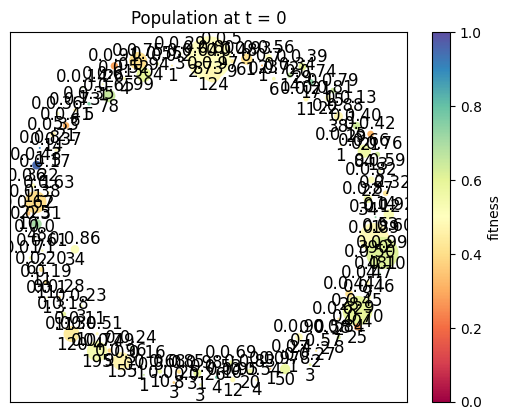

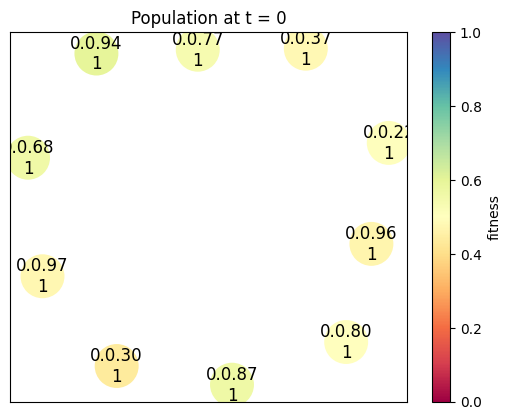

In [306]:

## For each strain...

def simulate_ancestry_with_mutations(new_avail_id,n, baseline=1, random_seed=seed, sequence_length=1, mu=mu):

    ts = msprime.sim_ancestry(n, random_seed=seed, sequence_length=1)
    mts = msprime.sim_mutations(
        ts, 
        rate=mu, 
        model=msprime.SLiMMutationModel(type=1),
        random_seed=seed)

    if len([var for var in mts.variants()])==0:
        print('no variants')
        return(False)

    final_intrahost_strains=+[var.counts() for var in mts.variants()][0]
    final_intrahost_strains_fitness_dic=fitnesses_by_genotype(mts, )
    print('final_intrahost_strains.keys()',final_intrahost_strains.keys())

    parent_strain_final_count=0
    try:
        parent_strain_final_count=final_intrahost_strains.pop('')
    except KeyError:
        print(list(final_intrahost_strains_fitness_dic.keys()))
        ml = {m.id: m.derived_state for m in mts.mutations()}
        plt.figure()
        mts.draw_svg(mutation_labels=ml)
        return(False)
        
    alleles=np.array(list(final_intrahost_strains.keys()))
    abundances=list(final_intrahost_strains.values())
    distances=[sum(tok.isdigit() for tok in s.split(',')) for s in final_intrahost_strains.keys()]
    fitnesses=[final_intrahost_strains_fitness_dic[allele] for allele in alleles]
        
    # Update pop with new alleles    
    new_avail_prefix='.'.join(new_avail_id.split('.')[0:-1])
    new_avail_idx=int(new_avail_id.split('.')[-1])
    new_alleles_ids=['.'.join([new_avail_prefix,str(i)]) for i in range(new_avail_idx,new_avail_idx+len(final_intrahost_strains))]
    new_avail_id='.'.join([new_avail_prefix,str(new_avail_idx+len(final_intrahost_strains))])

                
    # new_alleles_parent_indices=np.repeat(mutated_alleles, mutated_ind[mutated_alleles]).astype(int)
    # mutated_alleles_parent_fitness=fitnesses[new_alleles_parent_indices]
    # new_alleles_fitnesses=np.sum([mutated_alleles_parent_fitness,np.random.normal(-0.01, 0.01,size=mutated_ind_count)], axis=0) # Assign fitness to the new alleles. The fitness of the new alleles is that of the parent allele +/- a selection coefficient sampled from a normal distribution with mean -0.01 and std 0.01
    
    new_alleles_nodes=[[new_alleles_ids[i],{'abundance':abundances[i],'fitness':fitnesses[i]}] for i in range(len(alleles))]
    # new_alleles_edges=np.array([alleles[new_alleles_parent_indices],new_alleles_ids,[{"distance":1}] * len(new_alleles_ids)]).transpose()
    new_alleles_edges=[]
    return(new_alleles_nodes,new_alleles_edges)


# G.update(edges=new_alleles_edges, nodes=new_alleles_nodes)


#####################


import pandas as pd
import sys
sys.path.append("/Users/maeva/Desktop/Modeling_trophosome/src/")
#sys.path.append("/home/qiulab/data/CRF_project/work/Modeling_trophosome/src/")

from project_package.generate_pop import generate_random_fisherlog_pop_unlinked, SymPop
from project_package.plot import visualize_pop
from project_package.simplify import merge_graphs

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing
from alive_progress import alive_bar

import time


## init results objects    
time_series_freeliving={}
time_series_hostassociated={}

## params grow_and_steady
mutation_rate=0.1
#growth_factor=1.2
# steady_state_runtime=50
# max_runtime=np.inf
pop_size_thr=1E6
simplify=1
verbose=0
sampling_rate=1

## params run_host_pop_gen
n_worms=10
infection_sym_count=10
tot_host_pop_gen=100
escape_rate=1E-1
n_trials=5
cpus=4

# init tree log-fisher
init_pop_strains=100
is_init_pop_log_fisher=True

if is_init_pop_log_fisher==True:  
    freelivingG=generate_random_fisherlog_pop_unlinked(i=init_pop_strains) #n=individuals, i=strains
    freelivingG=nx.relabel_nodes(freelivingG, dict([[i,'0.0.'+str(i)] for i in range(init_pop_strains)]))

print(freelivingG)
plt.figure()
visualize_pop(freelivingG)

#######################
### Get free-living population paramaters

pop_attr=np.array([[node,attr['abundance'],attr['fitness']]for node,attr in freelivingG.nodes(data=True) if attr['abundance']>0])
alleles = pop_attr[:,0]
abundances = np.array(list(map(int,pop_attr[:,1])))
fitnesses = np.array(list(map(float,pop_attr[:,2])))

# Infection: set new host and subsample bacteria from free-living population
host_pop_gen=1
host_id=1

tot=sum(abundances)
weights=np.multiply(abundances,1/tot)
new_pop_abundances = np.random.multinomial(int(infection_sym_count), weights)
new_pop_alleles = [alleles[i] for i in range(len(new_pop_abundances)) if new_pop_abundances[i] > 0]

subsampleG=nx.Graph(freelivingG.subgraph(new_pop_alleles))
adj=[[alleles[i],{'abundance':new_pop_abundances[i],'fitness':fitnesses[i]}] for i in range(len(new_pop_abundances)) if new_pop_abundances[i] > 0]
subsampleG.update(nodes=adj)
initial_intrahost_pop=subsampleG.copy()

new_avail_id=str(host_pop_gen)+'.'+str(host_id)+'.0'

print(initial_intrahost_pop)
plt.figure()
visualize_pop(initial_intrahost_pop)

pop_attr=np.array([[node,attr['abundance'],attr['fitness']]for node,attr in initial_intrahost_pop.nodes(data=True) if attr['abundance']>0])
alleles = pop_attr[:,0]
abundances = np.array(list(map(int,pop_attr[:,1])))
fitnesses = np.array(list(map(float,pop_attr[:,2])))


seed = 666 #random


for i in range(len(alleles)):
    print(alleles[i], abundances[i],fitnesses[i])
    simulate_ancestry_with_mutations(alleles[i],abundances[i]*100,fitnesses[i], random_seed=seed, mu=mutation_rate)

    break

In [303]:
[var for var in mts.variants()]

[]

### brouillon

In [195]:
# Deduplicate samples by genotype
def prune_to_distinct_genotypes(mts, hash_seed=0):
    # 64-bit rolling hash per sample
    sample_hash = np.zeros(mts.num_samples, dtype=np.uint64)
    rng = np.random.default_rng(hash_seed)

    # Stream over segregating sites; update hashes
    for var in mts.variants():
        # One random key per allele at this site (ancestral allele index 0 included)
        keys = rng.integers(0, np.uint64(2**64 - 1),
                            size=len(var.alleles), dtype=np.uint64)
        g = var.genotypes  # length = num_samples; values are allele indices (0..k-1)
        # XOR the key for each allele into hashes of samples carrying that allele
        for a in range(len(var.alleles)):
            mask = (g == a)
            if np.any(mask):
                sample_hash[mask] ^= keys[a]

    # Keep one sample per unique hash
    _, first_idx = np.unique(sample_hash, return_index=True)
    keep_nodes = mts.samples()[first_idx]

    # Prune the tree sequence to those samples
    mts_unique = mts.simplify(keep_nodes, keep_unary=False)
    return(mts_unique, first_idx)

def unique_genotypes_and_counts(mts, hash_seed=0, encoding="derived_sites"):

    # 64-bit rolling hash per sample
    sample_hash = np.zeros(mts.num_samples, dtype=np.uint64)
    rng = np.random.default_rng(hash_seed)

    # Stream over segregating sites; update hashes
    for var in mts.variants():
        # Random 64-bit key per allele at this site
        keys = rng.integers(0, np.uint64(2**64 - 1),
                            size=len(var.alleles), dtype=np.uint64)
        g = var.genotypes  # allele indices per sample
        for a in range(len(var.alleles)):
            mask = (g == a)
            if np.any(mask):
                sample_hash[mask] ^= keys[a]

    # Unique hashes: get representative sample indices and counts
    _, first_idx, counts = np.unique(sample_hash, return_index=True, return_counts=True)

    # Build genotype strings for the representative samples
    reps = np.array(first_idx, dtype=int)
    per_rep = [[] for _ in reps]
    
    if encoding == "derived_sites":
        # Record site indices where allele != 0
        for var in mts.variants():
            print(var)
            continue
            site_idx = var.index
            g_rep = var.genotypes[reps]
            print('g_rep',g_rep)
            mask = (g_rep != 0)
            if np.any(mask):
                for j, is_derived in enumerate(mask):
                    print('j','is_derived',j, is_derived)
                    if is_derived:
                        print(j,str(site_idx),var)
                        per_rep[j].append(str(site_idx))
    elif encoding == "site_allele_pairs":
        # Record derived states as "site:allele"
        for var in mts.variants():
            site_idx = var.index
            g_rep = var.genotypes[reps]
            for j, a in enumerate(g_rep):
                if a != 0:
                    per_rep[j].append(f"{site_idx}:{a}")
    elif encoding == "alleles_per_site":
        # Record allele index at every site (including 0)
        for var in mts.variants():
            g_rep = var.genotypes[reps]
            for j, a in enumerate(g_rep):
                per_rep[j].append(str(a))
    else:
        raise ValueError("Unknown encoding; use 'derived_sites', 'site_allele_pairs', or 'alleles_per_site'.")
    
    genotypes = [",".join(lst) for lst in per_rep]
    return(genotypes, counts.tolist())


###########
print(len(list(mts.variants())))
for var in mts.variants():
    print(var)


# print([(var.alleles, var.genotypes) for var in mts.variants()])
# mts_unique, kept_indices = prune_to_distinct_genotypes(mts, hash_seed=0)
# print(f"Original samples: {mts_unique.num_samples}, distinct genotypes: {len(kept_indices)}")
# print("Kept sample indices (in original order):", kept_indices.tolist())

# # geno_map = genotype_strings_for_samples(mts, first_idx, mode="derived_sites")
# # print("Kept sample indices:", first_idx.tolist())
# # print("Genotype map:", geno_map)

# print(unique_genotypes_and_counts(mts, hash_seed=0, encoding="derived_sites"))
ml = {m.id: m.derived_state for m in mts_unique.mutations()}
# print(ml)
mts_unique.draw_svg(mutation_labels=ml)

1
╔═══════════════════════════════════╗
║Variant                            ║
╠═══════════════════════════╤═══════╣
║Site id                    │      0║
╟───────────────────────────┼───────╢
║Site position              │      0║
╟───────────────────────────┼───────╢
║Number of samples          │     10║
╟───────────────────────────┼───────╢
║Number of alleles          │      6║
╟───────────────────────────┼───────╢
║Samples with allele ''     │3 (30%)║
╟───────────────────────────┼───────╢
║Samples with allele '0'    │ 0 (0%)║
╟───────────────────────────┼───────╢
║Samples with allele '1'    │ 0 (0%)║
╟───────────────────────────┼───────╢
║Samples with allele '1,2'  │1 (10%)║
╟───────────────────────────┼───────╢
║Samples with allele '0,3'  │5 (50%)║
╟───────────────────────────┼───────╢
║Samples with allele '0,3,4'│1 (10%)║
╟───────────────────────────┼───────╢
║Has missing data           │  False║
╟───────────────────────────┼───────╢
║Isolated as missing        │   True║
╚═════════

AttributeError: 'function' object has no attribute 'counts'

dict_values([np.int64(3), np.int64(1), np.int64(5), np.int64(1)])

In [ ]:
def update_pop4(G,mutation_rate, new_avail_id, growth_factor=1):

    # get number of terminals for each strain that entered the host
    # for each strain, simulate coalescence for n individuals, add mutations, get summary
    # for each new strain: get new name, get abundance, get distance from ancestor, get fitness

    
    ########
    
    new_pop_abundances = np.random.multinomial(int(n * growth_factor), weights)
    tot_new_pop=sum(new_pop_abundances)
    mutated_ind_count=np.random.binomial(int(n), mutation_rate)

    if mutated_ind_count>0:
        mutated_ind = np.random.multinomial(mutated_ind_count,new_pop_abundances/tot_new_pop)
        new_pop_abundances=new_pop_abundances-mutated_ind
    
    adj=[[alleles[i],{'abundance':new_pop_abundances[i],'fitness':fitnesses[i]}] for i in range(len(alleles))]
    G.update(nodes=adj)
            
    if mutated_ind_count>0: # if new alleles have arisen
            
        # Update pop with new alleles
        mutated_alleles=np.nonzero(mutated_ind)[0]
        mutated_alleles_count =len(mutated_alleles)

        new_avail_prefix='.'.join(new_avail_id.split('.')[0:-1])
        new_avail_idx=int(new_avail_id.split('.')[-1])
        new_alleles_ids=['.'.join([new_avail_prefix,str(i)]) for i in range(new_avail_idx,new_avail_idx+mutated_ind_count)]
        new_avail_id='.'.join([new_avail_prefix,str(new_avail_idx+mutated_ind_count)])
        
        new_alleles_parent_indices=np.repeat(mutated_alleles, mutated_ind[mutated_alleles]).astype(int)
        mutated_alleles_parent_fitness=fitnesses[new_alleles_parent_indices]
        new_alleles_fitnesses=np.sum([mutated_alleles_parent_fitness,np.random.normal(-0.01, 0.01,size=mutated_ind_count)], axis=0) # Assign fitness to the new alleles. The fitness of the new alleles is that of the parent allele +/- a selection coefficient sampled from a normal distribution with mean -0.01 and std 0.01
        
        new_alleles_nodes=[[new_alleles_ids[i],{'abundance':1,'fitness':new_alleles_fitnesses[i]}] for i in range(len(new_alleles_fitnesses))]
        new_alleles_edges=np.array([alleles[new_alleles_parent_indices],new_alleles_ids,[{"distance":1}] * len(new_alleles_ids)]).transpose()

        G.update(edges=new_alleles_edges, nodes=new_alleles_nodes)
    
    return(G, new_avail_id)

# MYSCRIPT

In [ ]:
##### PSEUDOCODE ######
# Set a free-living population

# For each host... PARALLELIZEABLE
    ## Infection: set new host and subsample bacteria from free-living population
        ### Get networkx of initial populaiton
        ### get list of cells that infect the host and sort them by strain type

    ## Initialise an array of strain trees
    ## For each cell that enters the host...
        ## Note the strain type
        ## Estimate number of descendents in the final intra-host population
        ## Simulate ancestry from coalescence and add mutations
        ## Simplify tree to reflect only strain variants, abundance and mutation counts as metadata and add to an array of cell trees
        ## if the last cell seen of that strain, merge the trees in the array of cell trees into the strain tree and add to the array of strain trees
    ## For each strain tree in the array:
        ## Turn strain tree into networkx and rename nodes
    ## Merge per host the networkx graphs into a single one that has all the strains (and their descendents)
    ## Return networkx for initial_intrahost_pop,final_intrahost_pop,final_escapees_pop

# Merge results per host

## ############

## Getting grow_from_freeliving to work

Graph with 10 nodes and 9 edges


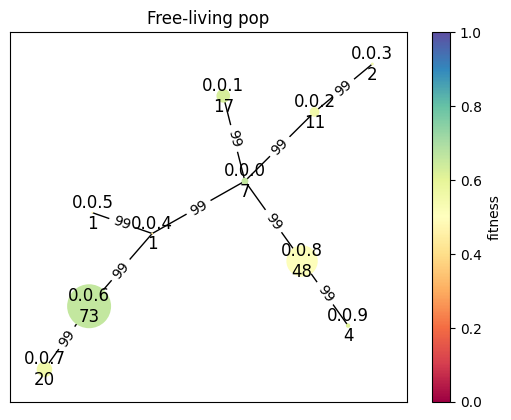

In [27]:
import pandas as pd
import sys
sys.path.append("/Users/maeva/Desktop/Modeling_trophosome/src/")
#sys.path.append("/home/qiulab/data/CRF_project/work/Modeling_trophosome/src/")
from project_package.tskit_functions import prune_unique_genotypes_add_metadata,merge_by_root_and_combine_ancestrals,NodeTable_to_pandasDF,cell_coalescent_tree_with_mutations,tstree_to_networkx_graph
from project_package.generate_pop import generate_random_fisherlog_pop_unlinked, SymPop, generate_random_fisherlog_pop_binomial_tree
from project_package.plot import visualize_pop
from project_package.simplify import merge_graphs,subsample_pop

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing
from alive_progress import alive_bar

import time
%reload_ext autoreload
%autoreload 2
    
# G.update(edges=new_alleles_edges, nodes=new_alleles_nodes)



############## INITIALIZATION #############

## init results objects    
time_series_freeliving={}
time_series_hostassociated={}

## params grow_and_steady
mutation_rate=0.00001
#growth_factor=1.2
# steady_state_runtime=50
# max_runtime=np.inf
pop_size_thr=1E6
simplify=1
verbose=0
sampling_rate=1

## params run_host_pop_gen
n_worms=10
infection_sym_count=10
tot_host_pop_gen=100
escape_rate=1E-1
n_trials=5
cpus=4
tree_seed = 666 #random
mutation_seed = 666
fitness_seed = 666

# init tree log-fisher
init_pop_strains=10
is_init_pop_log_fisher=False

freelivingG=generate_random_fisherlog_pop_binomial_tree(i=init_pop_strains) #n=individuals, i=strains



if is_init_pop_log_fisher==True:  
    freelivingG=generate_random_fisherlog_pop_unlinked(i=init_pop_strains) #n=individuals, i=strains
    freelivingG=nx.relabel_nodes(freelivingG, dict([[i,'0.0.'+str(i)] for i in range(init_pop_strains)]))

print(freelivingG)
plt.figure()
visualize_pop(freelivingG, replace_title="Free-living pop")

### Get free-living population paramaters

pop_attr=np.array([[node,attr['abundance'],attr['fitness']]for node,attr in freelivingG.nodes(data=True) if attr['abundance']>0])
alleles = pop_attr[:,0]
abundances = np.array(list(map(int,pop_attr[:,1])))
fitnesses = np.array(list(map(float,pop_attr[:,2])))


def grow_from_freeliving(args):

    '''This function grows one symbiont population within one host until it reaches a population size threshold (pop_size_thr). The cell
    phylogeny is reconstructed backwards through coalescence using tskit tree structure. Mutations are added to the populaiton tree.
    The modifiable arguments are:
    host_id (int) : the id of the individual host,
    alleles (list of str): the alleles of the free-living population
    abundances (list of int): the abundances of the free-living population
    fitnesses (list of floats): the fitnesses of the free-living population
    freelivingG (networkx/SymPop object) : the initial free-living population,
    infection_sym_count (int) : the number of bacterial cells that infect the host,
    host_pop_gen (int) : the generation of host population,
    escape_rate (float) : the proportion of bacterial cells that can escape the host,
    mutation_rate (float) : the mutaiton rate per bacterial cell per bacterial "generation", 
    pop_size_thr (int) : maximum symbiont population size in the host,
    
    '''
    
    # Load arguments
    # np.random.seed()
    
    host_id=args['host_id']
    freelivingG=args['freelivingG']
    alleles=args['alleles']
    abundances=args['abundances']
    fitnesses=args['fitnesses']
    infection_sym_count=args['infection_sym_count']
    host_pop_gen=args['host_pop_gen']
    escape_rate=args['escape_rate']
    mutation_rate=args['mutation_rate']
    pop_size_thr=args['pop_size_thr']
    seed=None

    
    tree_seed = np.random.seed(seed)
    mutation_seed = np.random.seed(seed)
    fitness_seed = np.random.seed(seed)

    # Infection: set new host and subsample bacteria from free-living population
    
    initial_intrahost_pop=subsample_pop(freelivingG,infection_sym_count)
    pop_attr=np.array([[node,attr['abundance'],attr['fitness']]for node,attr in initial_intrahost_pop.nodes(data=True) if attr['abundance']>0])
    alleles = pop_attr[:,0]
    abundances = np.array(list(map(int,pop_attr[:,1])))
    fitnesses = np.array(list(map(float,pop_attr[:,2])))
    
    new_avail_id=str(host_pop_gen)+'.'+str(host_id)+'.0'

    # Grow host: V1: all cells that enter the host ends up in the adult in the same proportions. Will have to play with msprime.sim_ancestry for different demographic models. https://tskit.dev/msprime/docs/stable/api.html#msprime.sim_ancestry
    
    G_list=[]
    for i in range(len(alleles)):
        allele=alleles[i]
        abundance=abundances[i]
        fitness=fitnesses[i]
    
        #For each cell that infected the host, trace back tree and mutations, put the trees into an array
        counter=1
        mts_unique_list=[]
        while counter <= abundance: #coalesce:
            n=pop_size_thr/infection_sym_count   # here we set the size of the cell line population in the final adult    
            mts=cell_coalescent_tree_with_mutations(n=n, mu=mutation_rate, fitness=fitness, tree_seed=tree_seed, mutation_seed=mutation_seed, fitness_seed=fitness_seed)
            mts_unique=prune_unique_genotypes_add_metadata(mts, n, s_mean=-0.1, s_std=0.1, baseline=fitness, seed=None)
            mts_unique_list+=[mts]
            if counter == abundance:
                strain_tree=merge_by_root_and_combine_ancestrals(mts_unique_list)
                G=tstree_to_networkx_graph(strain_tree) 
        
                rootnode=[i for i in range(len(strain_tree.tables.nodes)) if (strain_tree.node(i).metadata.get("abundance", 0) > 0) and (strain_tree.node(i).metadata.get("mutation_count", 0) == 0) ]
                new_avail_prefix='.'.join(new_avail_id.split('.')[0:-1])
                new_avail_idx=int(new_avail_id.split('.')[-1])
                new_alleles_ids=['.'.join([new_avail_prefix,str(i)]) for i in range(new_avail_idx,new_avail_idx+len(G.nodes))]
                new_avail_id='.'.join([new_avail_prefix,str(new_avail_idx+len(G.nodes)-1)])
                
                node_id_dic=dict(zip(G.nodes,new_alleles_ids))
                node_id_dic[rootnode[0]]=str(allele)
                
                nx.relabel_nodes(G, node_id_dic, copy=False)
                G_list+=[G]
                
            counter+=1
    
    
            
    final_intrahost_pop=nx.union_all(G_list)   
    final_escapees_pop=subsample_pop(final_intrahost_pop,SymPop(final_intrahost_pop).pop_size * escape_rate)
    
    return(initial_intrahost_pop,final_intrahost_pop,final_escapees_pop)


host_pop_gen=0
host_id=1
args={'freelivingG':freelivingG,'alleles':alleles,'abundances':abundances,'fitnesses':fitnesses,
           'host_pop_gen':host_pop_gen, 'host_id':host_id,
          'infection_sym_count':infection_sym_count, 
          'mutation_rate':mutation_rate,'pop_size_thr':pop_size_thr,
          'escape_rate':escape_rate}


initial_intrahost_pop,final_intrahost_pop,final_escapees_pop=grow_from_freeliving(args)

In [24]:
fitness=1
n=pop_size_thr/infection_sym_count 
mts=cell_coalescent_tree_with_mutations(n=n, mu=mutation_rate, fitness=fitness, tree_seed=tree_seed, mutation_seed=mutation_seed, fitness_seed=fitness_seed)
mts_unique=prune_unique_genotypes_add_metadata(mts, n, s_mean=-0.1, s_std=0.1, baseline=fitness, seed=None)
print(n,'mu',mutation_rate)
print(mts_unique.draw_text())
mts_unique.draw_svg(x_lim=[0, 1])
mts.tables.nodes


100000.0 mu 1e-05
2.00┊ 0 ┊
    ┊ ┃ ┊
1.00┊ 1 ┊
    0   1



id,time,flags,population,individual,metadata
0,1,0,-1,-1,"{'abundance': 0, 'fitness': 1.0, 'mut..."
1,0,1,0,0,"{'abundance': 100000, 'fitness': 1.0,..."


In [25]:
SymPop(final_intrahost_pop).pop_size * escape_rate

100000.0

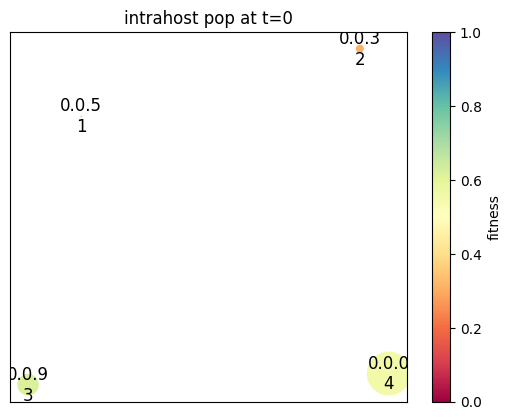

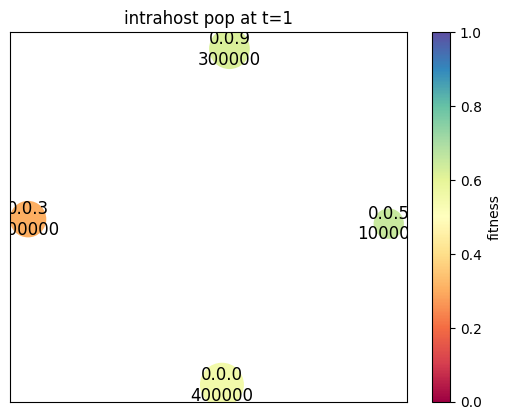

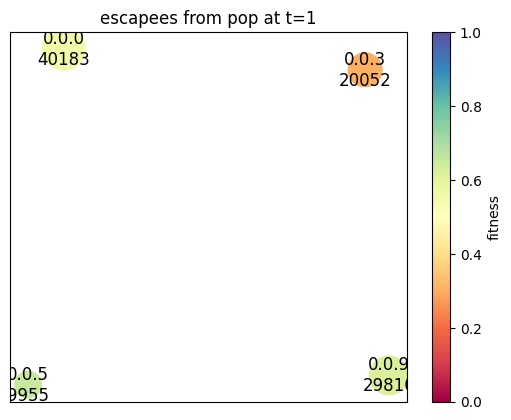

In [26]:
plt.figure()
visualize_pop(initial_intrahost_pop,replace_title="intrahost pop at t=0",view_node_labels=True)
plt.figure()
visualize_pop(final_intrahost_pop,replace_title="intrahost pop at t=1",abundance_threshold=1)
plt.figure()
visualize_pop(final_escapees_pop,replace_title="escapees from pop at t=1")

## Run host pop generation; looping through hosts

Graph with 10 nodes and 9 edges
host_id 0
host_id 1
host_id 2
host_id 3
host_id 4
host_id 5
host_id 6
host_id 7
host_id 8
host_id 9


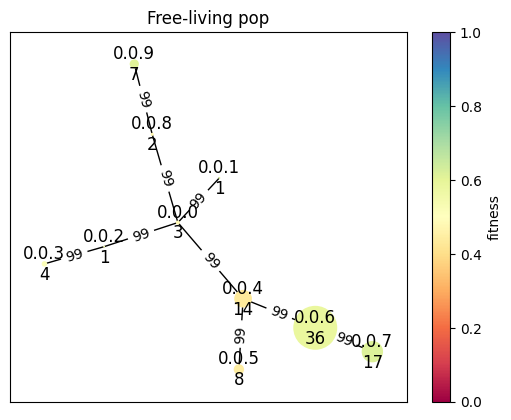

In [31]:
import pandas as pd
import sys
sys.path.append("/Users/maeva/Desktop/Modeling_trophosome/src/")
#sys.path.append("/home/qiulab/data/CRF_project/work/Modeling_trophosome/src/")
from project_package.tskit_functions import prune_unique_genotypes_add_metadata,merge_by_root_and_combine_ancestrals,NodeTable_to_pandasDF,cell_coalescent_tree_with_mutations,tstree_to_networkx_graph
from project_package.generate_pop import generate_random_fisherlog_pop_unlinked, SymPop, generate_random_fisherlog_pop_binomial_tree
from project_package.plot import visualize_pop
from project_package.simplify import merge_graphs,subsample_pop
from project_package.run_model import run_generation_of_host_pop_v2

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing
from alive_progress import alive_bar
import time

%reload_ext autoreload
%autoreload 2
    
# G.update(edges=new_alleles_edges, nodes=new_alleles_nodes)



############## INITIALIZATION #############

## init results objects    
time_series_freeliving={}
time_series_hostassociated={}

## params grow_and_steady
mutation_rate=0.001
#growth_factor=1.2
# steady_state_runtime=50
# max_runtime=np.inf
pop_size_thr=1E6
simplify=1
verbose=0
sampling_rate=1

## params run_host_pop_gen
n_worms=10
infection_sym_count=10
tot_host_pop_gen=100
escape_rate=1E-1
n_trials=5
cpus=4
tree_seed = 666 #random
mutation_seed = 666
fitness_seed = 666

# init tree log-fisher
init_pop_strains=10
is_init_pop_log_fisher=False

freelivingG=generate_random_fisherlog_pop_binomial_tree(i=init_pop_strains) #n=individuals, i=strains



if is_init_pop_log_fisher==True:  
    freelivingG=generate_random_fisherlog_pop_unlinked(i=init_pop_strains) #n=individuals, i=strains
    freelivingG=nx.relabel_nodes(freelivingG, dict([[i,'0.0.'+str(i)] for i in range(init_pop_strains)]))

print(freelivingG)
plt.figure()
visualize_pop(freelivingG, replace_title="Free-living pop")

### Get free-living population paramaters

pop_attr=np.array([[node,attr['abundance'],attr['fitness']]for node,attr in freelivingG.nodes(data=True) if attr['abundance']>0])
alleles = pop_attr[:,0]
abundances = np.array(list(map(int,pop_attr[:,1])))
fitnesses = np.array(list(map(float,pop_attr[:,2])))

host_pop_gen=1
merged_Graph_hostassociated, merged_Graph_freeliving=run_generation_of_host_pop_v2(freelivingG, n_worms, infection_sym_count,host_pop_gen,escape_rate,
                     mutation_rate, pop_size_thr, 
                     t=0,nthreads=1)

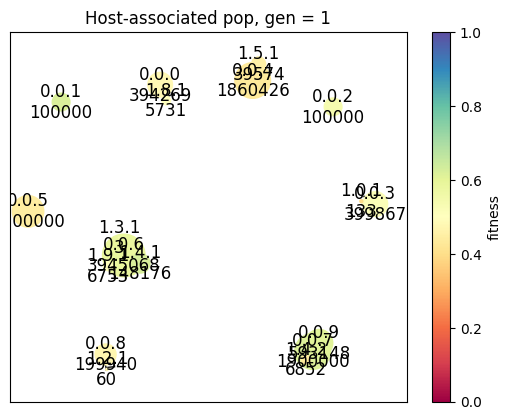

In [32]:
visualize_pop(merged_Graph_hostassociated, replace_title="Host-associated pop, gen = 1")


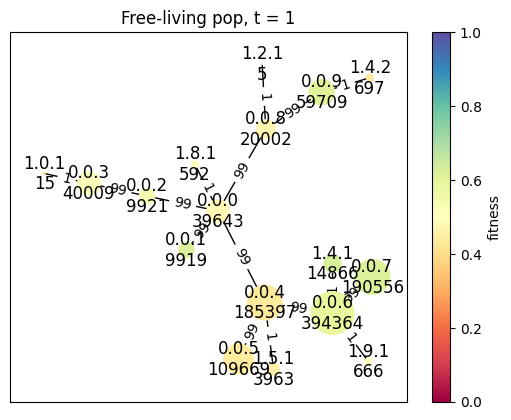

In [33]:
visualize_pop(merged_Graph_freeliving, replace_title="Free-living pop, t = 1")


## Run host pop generation; parallelized version

Graph with 100 nodes and 99 edges


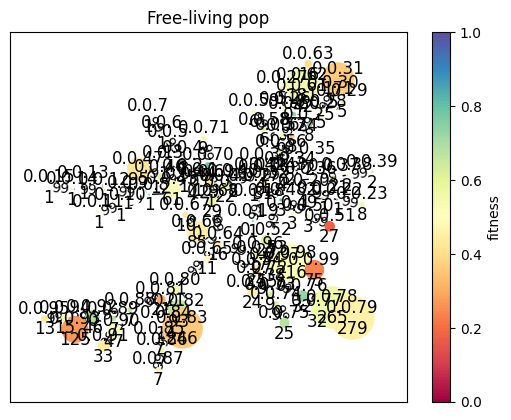

In [54]:
import pandas as pd
import sys
sys.path.append("/Users/maeva/Desktop/Modeling_trophosome/src/")
#sys.path.append("/home/qiulab/data/CRF_project/work/Modeling_trophosome/src/")
from project_package.tskit_functions import prune_unique_genotypes_add_metadata,merge_by_root_and_combine_ancestrals,NodeTable_to_pandasDF,cell_coalescent_tree_with_mutations,tstree_to_networkx_graph
from project_package.generate_pop import generate_random_fisherlog_pop_unlinked, SymPop, generate_random_fisherlog_pop_binomial_tree
from project_package.plot import visualize_pop
from project_package.simplify import merge_graphs,subsample_pop
from project_package.run_model import run_generation_of_host_pop_v3

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing
from alive_progress import alive_bar
import time

%reload_ext autoreload
%autoreload 2
    
# G.update(edges=new_alleles_edges, nodes=new_alleles_nodes)



############## INITIALIZATION #############

## init results objects    
time_series_freeliving={}
time_series_hostassociated={}

## params grow_and_steady
mutation_rate=0.001
#growth_factor=1.2
# steady_state_runtime=50
# max_runtime=np.inf
pop_size_thr=1E6
simplify=1
verbose=0
sampling_rate=1

## params run_host_pop_gen
n_worms=10
infection_sym_count=10
tot_host_pop_gen=100
escape_rate=1E-1
n_trials=5
cpus=4
tree_seed = 666 #random
mutation_seed = 666
fitness_seed = 666

# init tree log-fisher
init_pop_strains=100
is_init_pop_log_fisher=False

freelivingG=generate_random_fisherlog_pop_binomial_tree(i=init_pop_strains) #n=individuals, i=strains



if is_init_pop_log_fisher==True:  
    freelivingG=generate_random_fisherlog_pop_unlinked(i=init_pop_strains) #n=individuals, i=strains
    freelivingG=nx.relabel_nodes(freelivingG, dict([[i,'0.0.'+str(i)] for i in range(init_pop_strains)]))

print(freelivingG)
plt.figure()
visualize_pop(freelivingG, replace_title="Free-living pop")

### Get free-living population paramaters

pop_attr=np.array([[node,attr['abundance'],attr['fitness']]for node,attr in freelivingG.nodes(data=True) if attr['abundance']>0])
alleles = pop_attr[:,0]
abundances = np.array(list(map(int,pop_attr[:,1])))
fitnesses = np.array(list(map(float,pop_attr[:,2])))

host_pop_gen=1
merged_Graph_hostassociated, merged_Graph_freeliving=run_generation_of_host_pop_v3(freelivingG, n_worms, infection_sym_count,host_pop_gen,escape_rate,
                     mutation_rate, pop_size_thr, 
                     t=0,nthreads=4)

In [55]:
SymPop(freelivingG).richness

77

32

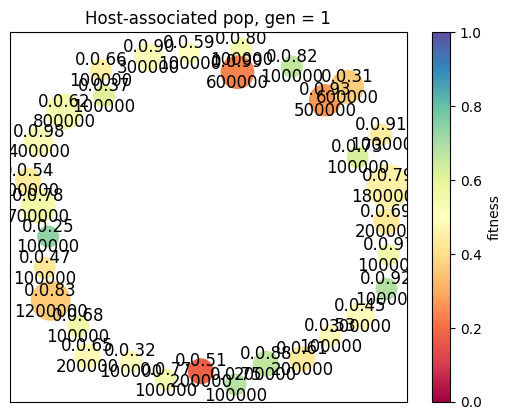

In [56]:
visualize_pop(merged_Graph_hostassociated, replace_title="Host-associated pop, gen = 1")
SymPop(merged_Graph_hostassociated).richness

77

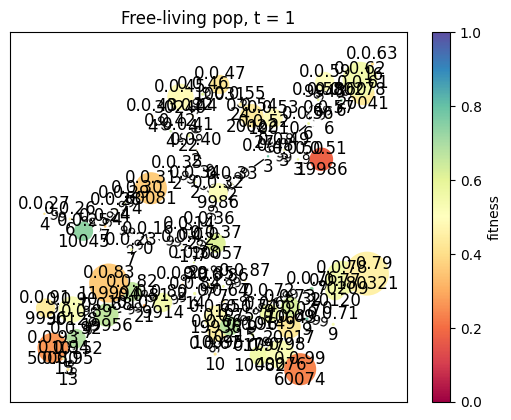

In [57]:
visualize_pop(merged_Graph_freeliving, replace_title="Free-living pop, t = 1")
SymPop(merged_Graph_freeliving).richness

In [58]:
print("in Free-living",set(SymPop(freelivingG).strains))
print("New in host pop",set(SymPop(merged_Graph_hostassociated).strains)-set(SymPop(freelivingG).strains))
print("New free-living t =1",set(SymPop(merged_Graph_freeliving).strains)-set(SymPop(freelivingG).strains))

in Free-living {'0.0.39', '0.0.36', '0.0.54', '0.0.73', '0.0.61', '0.0.65', '0.0.89', '0.0.35', '0.0.51', '0.0.81', '0.0.67', '0.0.68', '0.0.66', '0.0.99', '0.0.83', '0.0.33', '0.0.90', '0.0.74', '0.0.86', '0.0.72', '0.0.24', '0.0.32', '0.0.85', '0.0.50', '0.0.48', '0.0.41', '0.0.80', '0.0.75', '0.0.71', '0.0.40', '0.0.91', '0.0.63', '0.0.95', '0.0.94', '0.0.55', '0.0.59', '0.0.42', '0.0.47', '0.0.49', '0.0.62', '0.0.79', '0.0.25', '0.0.93', '0.0.26', '0.0.97', '0.0.52', '0.0.34', '0.0.27', '0.0.76', '0.0.29', '0.0.60', '0.0.46', '0.0.28', '0.0.31', '0.0.77', '0.0.44', '0.0.37', '0.0.78', '0.0.87', '0.0.70', '0.0.43', '0.0.58', '0.0.69', '0.0.92', '0.0.38', '0.0.96', '0.0.82', '0.0.88', '0.0.84', '0.0.53', '0.0.98', '0.0.30', '0.0.56', '0.0.23', '0.0.57', '0.0.45', '0.0.64'}
New in host pop set()
New free-living t =1 set()


# Other

In [207]:
def test(i):
    return('A'+str(i),'B'+str(i),'C'+str(i))

a=[]
b=[]
c=[]
for i in range(3):
    a,b,c+=test(i)

print(a)
print(b)
print(c)

[autoreload of project_package.run_model failed: Traceback (most recent call last):
  File "/Users/maeva/miniconda3/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/Users/maeva/miniconda3/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/Users/maeva/miniconda3/lib/python3.11/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 936, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1074, in get_code
  File "<frozen importlib._bootstrap_external>", line 1004, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/Users/maeva/Desktop/Modeling_trophosome/src/project_package/run_model.py", line 47

SyntaxError: 'tuple' is an illegal expression for augmented assignment (3877368472.py, line 8)

In [16]:
# Demography: one population of size Ne
# dem = msprime.Demography()
# dem.add_population(name="pop", initial_size=Ne)

## Simulate a single-locus ancestry (one tree across seq_len sites; no recombination)
# ts = msprime.sim_ancestry(
# samples=n,
# demography=dem,
# sequence_length=seq_len,
# recombination_rate=0.0, # critical: yields one tree; keeps memory sane
# model="hudson",
# random_seed=seed
# )


for n in new_pop_abundances[:1]:
    print(n)
    Ne = 10_000 # effective population size
    seq_len = 4_000_000 # number of sites (adjust for how many mutations you want)
    mu = 1e-9 # mutation rate per site per generation
    seed = 666
    
    ts = msprime.sim_ancestry(
    samples=n,
    population_size=Ne,
    sequence_length=1,
    recombination_rate=0,
    model="hudson")

#Inspect tree length to get a feel for expected #mutations
tree = ts.first()
total_branch_length = tree.total_branch_length # in generations
expected_mutations = mu * seq_len * total_branch_length
print(f"Total branch length (gens): {total_branch_length:.2f}")
print(f"Expected mutations: {expected_mutations:.1f}")

130616
Total branch length (gens): 508109.50
Expected mutations: 2032.4


In [14]:
ts

Total branch length in first tree is 9.844333388205934 generations
The first of 1 trees is plotted below


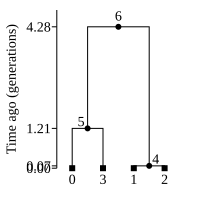

In [2]:
import msprime
import numpy as np

ts = msprime.sim_ancestry(2, random_seed=1234)
ts
first_tree = ts.first()
print("Total branch length in first tree is", first_tree.total_branch_length, ts.time_units)
print("The first of", ts.num_trees, "trees is plotted below")
first_tree.draw_svg(y_axis=True)  # plot the tree: only useful for small trees

In [4]:
for variant in ts.variants():
    print(
        "Variable site", variant.site.id,
        "at genome position", variant.site.position,
        ":", [variant.alleles[g] for g in variant.genotypes],
    )

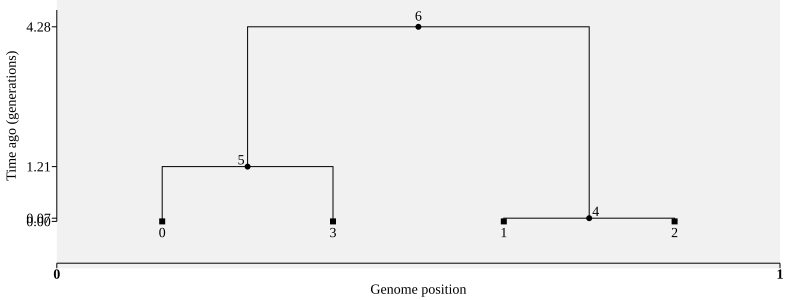

In [3]:
ts.draw_svg(
    size=(800, 300),
    y_axis=True,
    mutation_labels={m.id: m.derived_state for m in ts.mutations()},
)

In [ ]:
ts.draw_svg(
    size=(800, 300),
    y_axis=True,
    mutation_labels={m.id: m.derived_state for m in ts.mutations()},
)